In [97]:
import pandas as pd
import xarray as xr
import numpy as np
import netCDF4
# import nc_time_axis
import matplotlib.pyplot as plt
import glob
import cmocean
import xskillscore as xs
import datetime
# from sklearn.metrics import mean_squared_error

import h5py
from scipy.io import loadmat
from scipy import signal
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec

from mpl_toolkits.basemap import Basemap

In [2]:
## Working directory
wrk_dir = '~/work/OBS/dashcams_data/plotting_for_draft_supplementary/'

# load bathymetry data

In [3]:
ds_topo_etopo1 = xr.open_dataset('/home/server/pi/homes/liux8/work/general_data/topography/etopo1.nc',mode='r')
# bathy = bathy.rename({'lon': 'longitude', 'lat': 'latitude'})

/home/server/pi/homes/liux8/.conda/envs/dev_scipy/lib/python3.11/site-packages/xarray/coding/times.py:210: CFWarning: this date/calendar/year zero convention is not supported by CF
  cftime.num2date(num_dates, units, calendar, only_use_cftime_datetimes=True)
/home/server/pi/homes/liux8/.conda/envs/dev_scipy/lib/python3.11/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/server/pi/homes/liux8/.conda/envs/dev_scipy/lib/python3.11/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  array = array.get_duck_array()


# load satellte data

In [4]:
# load satellite data (2007-2021)

for iy in range(2020,2025):
    print(iy)
    with h5py.File(f'/home/server/pi/homes/liux8/work/OBS/xliu_obs_process/model_satellite/sst_data/sst_{iy}_MUR.mat', 'r') as file:
        def print_attrs(name, obj):
            print(name)
            for key, val in obj.attrs.items():
                print(f"    {key}: {val}")
        
        sst0 = file['sst'][:]
        if iy < 2023:
            sst0=sst0-273.15
        
        # sst_mean = np.nanmean(np.nanmean(sst,axis=1),axis=1)
        if iy==2020:
            sst = sst0
        else:
            sst = np.concatenate((sst,sst0),axis=0)
            
            # sst_mean0 = np.concatenate((sst_mean0,sst_mean),axis=0)
            
        file.visititems(print_attrs)


2020
ilon1
    MATLAB_class: b'double'
jlat1
    MATLAB_class: b'double'
sst
    MATLAB_class: b'double'
2021


ilon1
    MATLAB_class: b'double'
jlat1
    MATLAB_class: b'double'
sst
    MATLAB_class: b'double'
2022
ilon1
    MATLAB_class: b'double'
jlat1
    MATLAB_class: b'double'
sst
    MATLAB_class: b'double'
2023
ilon1
    MATLAB_class: b'double'
jlat1
    MATLAB_class: b'double'
sst
    MATLAB_class: b'double'
2024
ilon1
    MATLAB_class: b'double'
jlat1
    MATLAB_class: b'double'
sst
    MATLAB_class: b'double'


In [5]:
lon0 = loadmat('/home/server/pi/homes/liux8/work/OBS/xliu_obs_process/sst_lonlat_MUR.mat')['lon']
lat0 = loadmat('/home/server/pi/homes/liux8/work/OBS/xliu_obs_process/sst_lonlat_MUR.mat')['lat']

ilon = loadmat('/home/server/pi/homes/liux8/work/OBS/xliu_obs_process/sst_ilon_ilat_MUR.mat')['ilon1']
jlat = loadmat('/home/server/pi/homes/liux8/work/OBS/xliu_obs_process/sst_ilon_ilat_MUR.mat')['jlat1']

lon_mur = lon0[ilon[0,0].astype(int)-1:ilon[-1,0].astype(int)]
lat_mur = lat0[jlat[0,0].astype(int)-1:jlat[-1,0].astype(int)]

In [6]:
tdim = sst.shape[0]
print(tdim)
da_mur = xr.DataArray(sst, coords={'time': np.arange(0,tdim*86400,86400)+50*365*86400+12*86400,'lon': lon_mur[:,0] ,'lat': lat_mur[:,0]},
                  dims=['time','lat','lon'])

# da2_mur = da_mur.interp(lon=datasets_era[0].lonc,lat=datasets_era[0].latc,method='linear')

ds_mur = xr.Dataset({'sst': da_mur})
ds_mur['time'] = pd.to_datetime(ds_mur['time'].values,unit='s')
# ds_dust['time'] = pd.to_datetime(ds_dust['time'].values,unit='s')

1735


# load dust concentration

In [7]:
## load 2021-2024 dust data
for iy in range(2020,2025):
    if iy<=2020:
        file0 = f'/home/server/pi/homes/liux8/work/OBS/xliu_obs_process/dust_mat_files/dust_{iy}_MERRA2_hourly.mat'
    else:
        file0 = f'/home/server/pi/homes/liux8/work/OBS/xliu_obs_process/dust_mat_files/dust_{iy}_MERRA2_hourly_v2.mat'
    with h5py.File(file0, 'r') as file:
        def print_attrs(name, obj):
            print(iy)
            print(name)
            for key, val in obj.attrs.items():
                print(f"    {key}: {val}")

        file.visititems(print_attrs)

        # reading the dataset
        if iy==2020:
            dust2021 = file['dust_cum'][:]
            latdus = file['latdus'][:]
            londus = file['londus'][:]
        else:
            dust2021 = np.concatenate((dust2021,file['dust_cum'][:]),axis=0)
            
tdim = dust2021.shape[0]
            

da_dust = xr.DataArray(dust2021, coords={'lon': londus[0,:], 'lat': latdus[0,:], 'time': np.arange(0,tdim*3600,3600)+50*365*86400+12*86400},
                  dims=['time', 'lat', 'lon'])

ds_dust = xr.Dataset({'dust_dens': da_dust})

# ds_dust['time'] = pd.to_datetime(ds_dust['time'].values,unit='s')+pd.DateOffset(years=50)
ds_dust['time'] = pd.to_datetime(ds_dust['time'].values,unit='s')

# ds_dust_daily = ds_dust.groupby("time.dayofyear").mean(dim="time")

2020
dust_cum
    MATLAB_class: b'double'
2020
latdus
    MATLAB_class: b'double'
2020
londus
    MATLAB_class: b'double'
2021
dust_cum
    MATLAB_class: b'double'
2021
latdus
    MATLAB_class: b'double'
2021
londus
    MATLAB_class: b'double'
2022
dust_cum
    MATLAB_class: b'double'
2022
latdus
    MATLAB_class: b'double'
2022
londus
    MATLAB_class: b'double'
2023
dust_cum
    MATLAB_class: b'double'
2023
latdus
    MATLAB_class: b'double'
2023
londus
    MATLAB_class: b'double'
2024
dust_cum
    MATLAB_class: b'double'
2024
latdus
    MATLAB_class: b'double'
2024
londus
    MATLAB_class: b'double'


In [8]:
ds_dust

<xarray.Dataset>
Dimensions:    (lon: 17, lat: 19, time: 37248)
Coordinates:
  * lon        (lon) float64 47.5 48.12 48.75 49.38 ... 55.62 56.25 56.88 57.5
  * lat        (lat) float64 23.0 23.5 24.0 24.5 25.0 ... 30.5 31.0 31.5 32.0
  * time       (time) datetime64[ns] 2020-01-01 ... 2024-03-31T23:00:00
Data variables:
    dust_dens  (time, lat, lon) float64 0.0001576 0.0001736 ... 4.752e-05

# load raw data

## can use NC file below directly

### UAEBUS20

#### Option 1: read from CSV

In [6]:
ID_deploy = 'UAEBUSO20'

file1=wrk_dir+f'PG_dive_raw_v1_longrec_keepGPS_{ID_deploy}.csv'; ptime=165
# file1='surf_processed/Jul_Sep_2021.csv'; ptime=220
# file1='surf_processed/Oct_Dec_2021.csv'

# yr=file1[-21:-17]
# yr=file1[-13:-9]
df = pd.read_csv(file1,parse_dates=True,index_col='UTC_datetime')

/tmp/ipykernel_1455619/3571139322.py:9: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file1,parse_dates=True,index_col='UTC_datetime')


In [8]:
df['t'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['milliseconds'], unit='ms')

In [9]:
df['date2'] = df['t']
df = df.set_index('t')
df

,device_id,UTC_date,UTC_time,datatype,satcount,Latitude,Longitude,int_temperature_C,UTC_timestamp,milliseconds,depth_m,ext_temperature_C,date,date2
t,,,,,,,,,,,,,,
2020-11-02 20:11:05.000,203018,2020-11-02,20:11:05,GPS,6.0,44.5583,-123.2715,16.0,2020-11-02 20:11:05.000,0.0,NaN,NaN,2020-11-02 20:11:05,2020-11-02 20:11:05.000
2020-11-02 22:14:06.000,203018,2020-11-02,22:14:06,GPS,0.0,0.0000,0.0000,26.0,2020-11-02 22:14:06.000,0.0,NaN,NaN,2020-11-02 22:14:06,2020-11-02 22:14:06.000
2020-11-02 22:19:19.100,203018,2020-11-02,22:19:19,SEND_ALL2_10Hz_START,NaN,NaN,NaN,NaN,2020-11-02 22:19:19.2020-11-02 22:19:19.100,100.0,0.58,14.671875,2020-11-02 22:19:19,2020-11-02 22:19:19.100
2020-11-02 22:19:19.200,203018,2020-11-02,22:19:19,SEND_ALL2_10Hz,NaN,NaN,NaN,NaN,2020-11-02 22:19:19.2020-11-02 22:19:19.200,200.0,0.64,14.429688,2020-11-02 22:19:19,2020-11-02 22:19:19.200
2020-11-02 22:19:19.300,203018,2020-11-02,22:19:19,SEND_ALL2_10Hz,NaN,NaN,NaN,NaN,2020-11-02 22:19:19.2020-11-02 22:19:19.300,300.0,0.69,14.250000,2020-11-02 22:19:19,2020-11-02 22:19:19.300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-08-13 22:22:22.000,201411,2021-08-13,22:22:22,GPSS,0.0,0.0000,0.0000,43.0,2021-08-13 22:22:22.000,0.0,NaN,NaN,2021-08-13 22:22:22,2021-08-13 22:22:22.000
2021-08-14 01:22:22.000,201411,2021-08-14,01:22:22,GPSS,0.0,0.0000,0.0000,43.0,2021-08-14 01:22:22.000,0.0,NaN,NaN,2021-08-14 01:22:22,2021-08-14 01:22:22.000
2021-08-14 04:22:22.000,201411,2021-08-14,04:22:22,GPSS,0.0,0.0000,0.0000,43.0,2021-08-14 04:22:22.000,0.0,NaN,NaN,2021-08-14 04:22:22,2021-08-14 04:22:22.000


In [11]:
# df1 = df.loc[df['device_id']==203013]

# x = xr.DataArray(df.Longitude_1, dims="t")
# y = xr.DataArray(df.Latitude_1, dims="t")
time = xr.DataArray(df.date2, dims="t")
did = xr.DataArray(df.device_id, dims="t")
# accx = xr.DataArray(df.acc_x,dims='t')
# accy = xr.DataArray(df.acc_y,dims='t')
# accz = xr.DataArray(df.acc_z,dims='t')
lon = xr.DataArray(df.Longitude,dims='t')
lat = xr.DataArray(df.Latitude,dims='t')
datatype = xr.DataArray(df.datatype,dims='t')
depth = xr.DataArray(df.depth_m,dims='t')
temp = xr.DataArray(df.ext_temperature_C, dims="t")
temp_int = xr.DataArray(df.int_temperature_C, dims="t")
# conduc = xr.DataArray(df['conductivity_mS/cm'], dims="t")

ds_obs = xr.Dataset({
    # 'x': x,
    # 'y': y,
    'time': time,
    'id': did,
    # 'accx': accx,
    # 'accy': accy,
    # 'accz': accz,
    'lon': lon,
    'lat': lat,
    'datatype': datatype,
    'depth': depth,
    'temp': temp,
    'temp_int': temp_int,
    # 'cond': conduc
})

In [ ]:
ds_obs.to_netcdf('PG_acc_raw_v1_keep_gps_UAEBUSO20.nc')

#### Option 2: read from NC file

In [9]:
ds_obs1 = xr.open_dataset('PG_acc_raw_v1_keep_gps_UAEBUSO20.nc')

### BAHHASO 21-23

#### Option 1: read from CSV file

In [41]:
ID_deploy = 'BAHHASO'

file1=wrk_dir+f'PG_dive_raw_v1_longrec_keepGPS_{ID_deploy}.csv'; ptime=165

df = pd.read_csv(file1,parse_dates=True,index_col='UTC_datetime')
df['t'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['milliseconds'], unit='ms')
df['date2'] = df['t']
df = df.set_index('t')

time = xr.DataArray(df.date2, dims="t")
did = xr.DataArray(df.device_id, dims="t")
# accx = xr.DataArray(df.acc_x,dims='t')
# accy = xr.DataArray(df.acc_y,dims='t')
# accz = xr.DataArray(df.acc_z,dims='t')
lon = xr.DataArray(df.Longitude,dims='t')
lat = xr.DataArray(df.Latitude,dims='t')
datatype = xr.DataArray(df.datatype,dims='t')
depth = xr.DataArray(df.depth_m,dims='t')
temp = xr.DataArray(df.ext_temperature_C, dims="t")
temp_int = xr.DataArray(df.int_temperature_C, dims="t")
# conduc = xr.DataArray(df['conductivity_mS/cm'], dims="t")

ds_obs2 = xr.Dataset({
    # 'x': x,
    # 'y': y,
    'time': time,
    'id': did,
    # 'accx': accx,
    # 'accy': accy,
    # 'accz': accz,
    'lon': lon,
    'lat': lat,
    'datatype': datatype,
    'depth': depth,
    'temp': temp,
    'temp_int': temp_int,
    # 'cond': conduc
})

/tmp/ipykernel_1466952/88605698.py:5: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file1,parse_dates=True,index_col='UTC_datetime')


In [44]:
ds_obs2.to_netcdf('PG_acc_raw_v1_keep_gps_BAHHASO.nc',mode='w')

#### read from netcdf

In [10]:
ds_obs2 = xr.open_dataset('PG_acc_raw_v1_keep_gps_BAHHASO.nc')

### SAUJUS

#### Option 1: read from CSV file

In [11]:
ID_deploy = 'SAUJUSO23'

file1=wrk_dir+f'PG_dive_raw_v1_longrec_keepGPS_{ID_deploy}.csv'; ptime=165

df = pd.read_csv(file1,parse_dates=True,index_col='UTC_datetime')
df['t'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['milliseconds'], unit='ms')
df['date2'] = df['t']
df = df.set_index('t')

time = xr.DataArray(df.date2, dims="t")
did = xr.DataArray(df.device_id, dims="t")
# accx = xr.DataArray(df.acc_x,dims='t')
# accy = xr.DataArray(df.acc_y,dims='t')
# accz = xr.DataArray(df.acc_z,dims='t')
lon = xr.DataArray(df.Longitude,dims='t')
lat = xr.DataArray(df.Latitude,dims='t')
datatype = xr.DataArray(df.datatype,dims='t')
depth = xr.DataArray(df.depth_m,dims='t')
temp = xr.DataArray(df.ext_temperature_C, dims="t")
temp_int = xr.DataArray(df.int_temperature_C, dims="t")
# conduc = xr.DataArray(df['conductivity_mS/cm'], dims="t")

ds_obs3 = xr.Dataset({
    # 'x': x,
    # 'y': y,
    'time': time,
    'id': did,
    # 'accx': accx,
    # 'accy': accy,
    # 'accz': accz,
    'lon': lon,
    'lat': lat,
    'datatype': datatype,
    'depth': depth,
    'temp': temp,
    'temp_int': temp_int,
    # 'cond': conduc
})

/tmp/ipykernel_1466952/1817136335.py:5: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file1,parse_dates=True,index_col='UTC_datetime')


In [15]:
ds_obs3.to_netcdf('PG_acc_raw_v1_keep_gps_SAUJUSO23.nc')

#### option 2: read from netcdf

In [11]:
ds_obs3 = xr.open_dataset('PG_acc_raw_v1_keep_gps_SAUJUSO23.nc')

### UAESISO20

#### Option 1: read from CSV file

In [7]:
ID_deploy = 'UAESISO20'

file1=wrk_dir+f'PG_dive_raw_v1_longrec_keepGPS_{ID_deploy}.csv'; ptime=165

df = pd.read_csv(file1,parse_dates=True,index_col='UTC_datetime')
df['t'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['milliseconds'], unit='ms')
df['date2'] = df['t']
df = df.set_index('t')

time = xr.DataArray(df.date2, dims="t")
did = xr.DataArray(df.device_id, dims="t")
# accx = xr.DataArray(df.acc_x,dims='t')
# accy = xr.DataArray(df.acc_y,dims='t')
# accz = xr.DataArray(df.acc_z,dims='t')
lon = xr.DataArray(df.Longitude,dims='t')
lat = xr.DataArray(df.Latitude,dims='t')
datatype = xr.DataArray(df.datatype,dims='t')
depth = xr.DataArray(df.depth_m,dims='t')
temp = xr.DataArray(df.ext_temperature_C, dims="t")
temp_int = xr.DataArray(df.int_temperature_C, dims="t")
# conduc = xr.DataArray(df['conductivity_mS/cm'], dims="t")

ds_obs4 = xr.Dataset({
    # 'x': x,
    # 'y': y,
    'time': time,
    'id': did,
    # 'accx': accx,
    # 'accy': accy,
    # 'accz': accz,
    'lon': lon,
    'lat': lat,
    'datatype': datatype,
    'depth': depth,
    'temp': temp,
    'temp_int': temp_int,
    # 'cond': conduc
})

In [8]:
ds_obs4.to_netcdf('PG_acc_raw_v1_keep_gps_UAESISO20.nc')

#### Option 2: read from netcdf

In [12]:
ds_obs4 = xr.open_dataset('PG_acc_raw_v1_keep_gps_UAESISO20.nc')

# load NC files

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


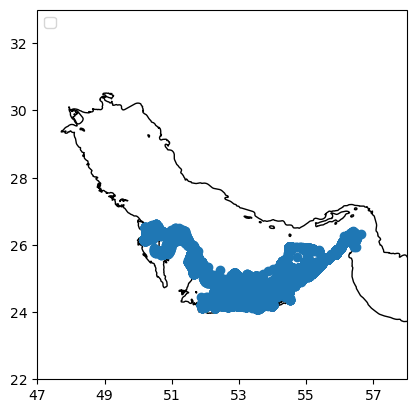

In [13]:
### OLD version
ax = plt.axes(projection=ccrs.PlateCarree())
plt.plot(ds_obs1.lon,ds_obs1.lat,'o')

ax.coastlines()
ax.set_xlim(47,58)
ax.set_ylim(22,33)
ax.set_xticks(np.arange(47,58,2), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(22,33,2), crs=ccrs.PlateCarree())
ax.legend(loc = "upper left")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


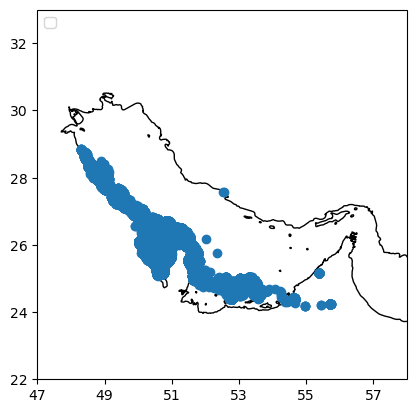

In [14]:
### OLD version
ax = plt.axes(projection=ccrs.PlateCarree())
plt.plot(ds_obs2.lon,ds_obs2.lat,'o')

ax.coastlines()
ax.set_xlim(47,58)
ax.set_ylim(22,33)
ax.set_xticks(np.arange(47,58,2), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(22,33,2), crs=ccrs.PlateCarree())
ax.legend(loc = "upper left")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


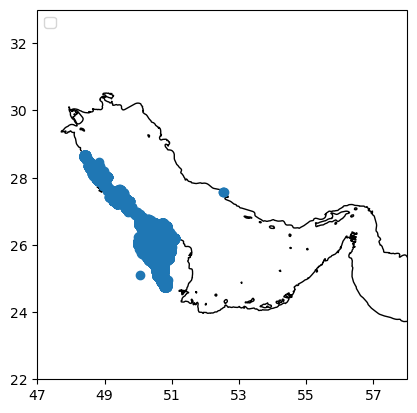

In [12]:
### OLD version
ax = plt.axes(projection=ccrs.PlateCarree())
plt.plot(ds_obs3.lon,ds_obs3.lat,'o')

ax.coastlines()
ax.set_xlim(47,58)
ax.set_ylim(22,33)
ax.set_xticks(np.arange(47,58,2), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(22,33,2), crs=ccrs.PlateCarree())
ax.legend(loc = "upper left")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


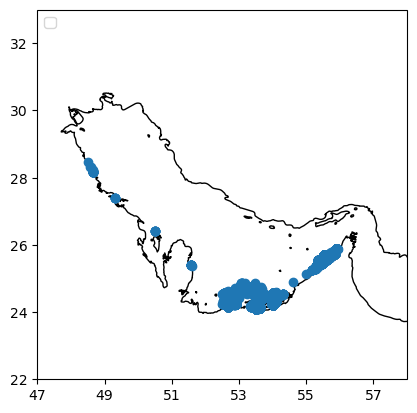

In [13]:
### OLD version
ax = plt.axes(projection=ccrs.PlateCarree())
plt.plot(ds_obs4.lon,ds_obs4.lat,'o')

ax.coastlines()
ax.set_xlim(47,58)
ax.set_ylim(22,33)
ax.set_xticks(np.arange(47,58,2), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(22,33,2), crs=ccrs.PlateCarree())
ax.legend(loc = "upper left")

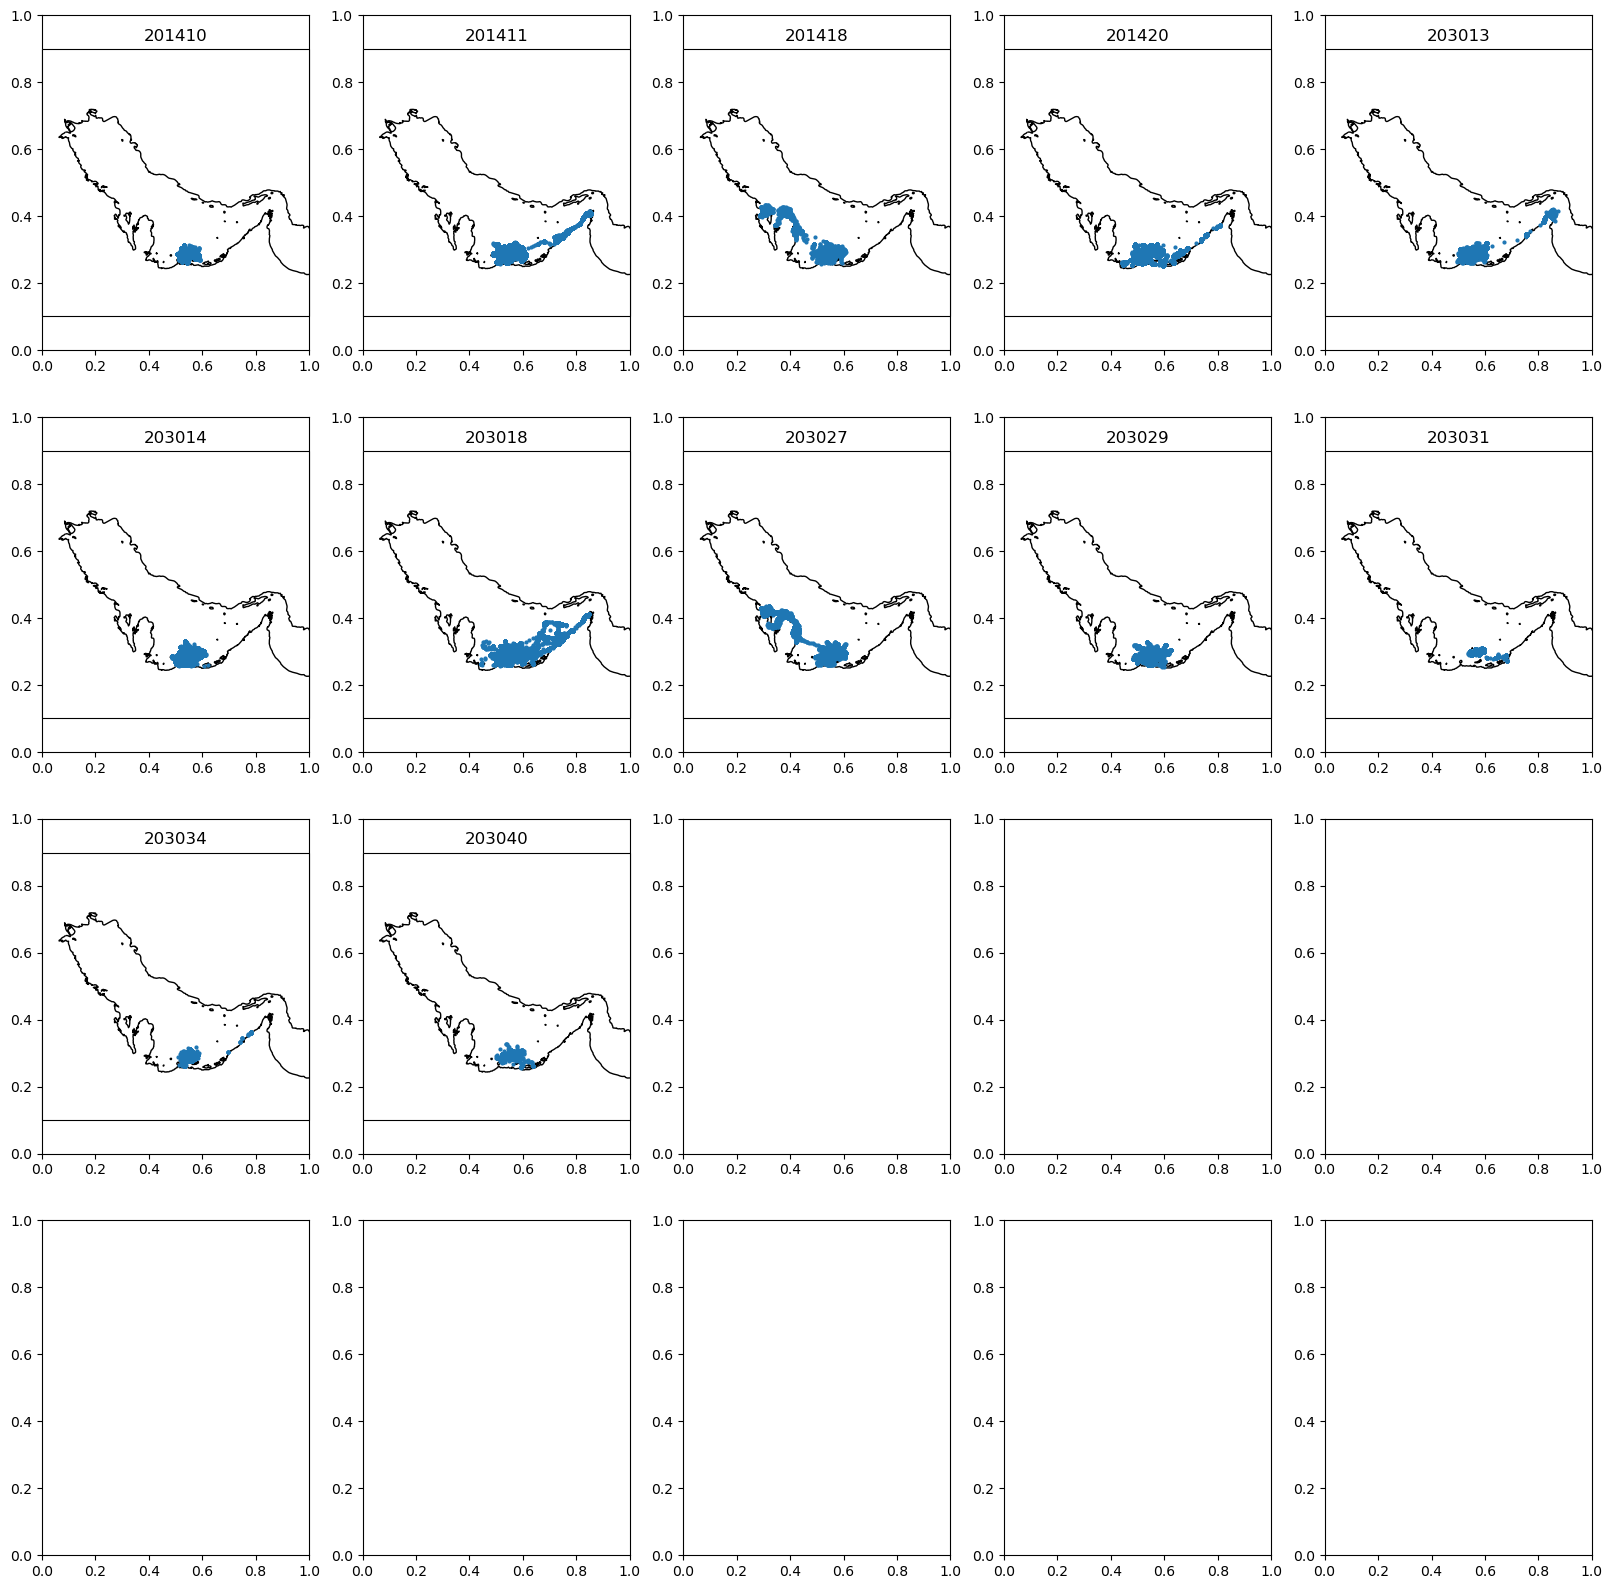

In [ ]:
fig,axs = plt.subplots(4,5,figsize=(20,20))
iplt = 0
for i in np.unique(ds_obs.id):
    ax = plt.subplot(4, 5, iplt + 1, projection=ccrs.PlateCarree())
    # ax = plt.axes(projection=ccrs.PlateCarree())
    plt.plot(ds_obs.lon.where(ds_obs.id==i),ds_obs.lat,'o',markersize=2)
    # plt.plot([x_geobox[0],x_geobox[0],x_geobox[1],x_geobox[1],x_geobox[0]],[y_geobox[1],y_geobox[0],y_geobox[0],y_geobox[1],y_geobox[1]])

    ax.coastlines()
    ax.set_xlim(47,58)
    ax.set_ylim(22,33)
    ax.set_title(i)
    iplt += 1
    # ax.set_xlim(x_geobox[0]-0.1,x_geobox[1]+0.1)
    # ax.set_ylim(y_geobox[0]-0.1,y_geobox[1]+0.1)

In [15]:
print( 'tags in UAEBUSO20:' , np.unique(ds_obs1.id),len(np.unique(ds_obs1.id)))
print( 'tags in UAEBUSO20:' , np.unique(ds_obs1.datatype)

print( 'tags in BAHHASO:' , np.unique(ds_obs2.id),len(np.unique(ds_obs2.id)))
print( 'tags in BAHHASO:' , np.unique(ds_obs2.datatype)

print( 'tags in UAEJUSO23:' , np.unique(ds_obs3.id),len(np.unique(ds_obs3.id)))
print( 'tags in UAEJUSO23:' , np.unique(ds_obs3.datatype)

print( 'tags in UAESISO20:' , np.unique(ds_obs4.id),len(np.unique(ds_obs4.id)))
print( 'tags in UAESISO20:' , np.unique(ds_obs4.datatype)

tags in UAEBUSO20: [201410 201411 201418 201420 203013 203014 203018 203027 203029 203031
 203034 203040] 12
tags in UAEBUSO20: ['GPS' 'GPSD' 'GPSF' 'GPSS' 'NOTE_DIVING' 'SEND_ALL2_10Hz'
 'SEND_ALL2_10Hz_END' 'SEND_ALL2_10Hz_START' 'SEND_ALL2_10Hz_START_END'
 'SEND_ALL2_1Hz' 'SEND_ALL2_1Hz_END' 'SEND_ALL2_1Hz_START'
 'SEND_ALL2_1Hz_START_END' 'SEN_ACC_5Hz_START_ENDINT' 'SEN_ALL_1Hz'
 'SEN_ALL_1Hz_END' 'SEN_ALL_1Hz_START'] 17
tags in BAHHASO: [215435 215437 215438 215439 215440 215441 215442 215443 215445 215446
 215447 215448 215450 215451 215452 215453 215454 215455 215457 215458
 215459 215460 225687 225688 237244 237245 237246 237247 237248 237249
 237250 237251 237252 237253 237254 237255 237256 237257 237258 237259
 237260 237261 237262 237263] 44
tags in BAHHASO: ['GPS' 'GPSD' 'GPSF' 'GPSS' 'NOTE_DIVING' 'SEND_ALL2_1Hz'
 'SEND_ALL2_1Hz_END' 'SEND_ALL2_1Hz_START' 'SEND_ALL2_1Hz_START_END'
 'SEND_ALL2_5Hz' 'SEND_ALL2_5Hz_END' 'SEND_ALL2_5Hz_START'
 'SEND_ALL2_5Hz_START_END' 'SEND_A

201410
<xarray.DataArray 'time' (t: 293315)>
array(['2020-07-02T01:07:14.000000000', '2020-07-02T01:07:15.000000000',
       '2020-07-02T01:07:49.151000000', ...,
       '2021-07-13T07:39:39.719000000', '2021-07-13T07:59:39.763000000',
       '2021-07-13T08:19:39.793000000'], dtype='datetime64[ns]')
Coordinates:
  * t        (t) datetime64[ns] 2020-07-02T01:07:14 ... 2021-07-13T08:19:39.7...
201411
<xarray.DataArray 'time' (t: 593889)>
array(['2020-07-02T00:33:35.000000000', '2020-07-02T00:33:36.000000000',
       '2020-07-02T00:34:11.427000000', ...,
       '2021-08-14T04:22:22.000000000', '2021-08-14T04:51:17.000000000',
       '2021-08-14T19:26:56.000000000'], dtype='datetime64[ns]')
Coordinates:
  * t        (t) datetime64[ns] 2020-07-02T00:33:35 ... 2021-08-14T19:26:56
201418
<xarray.DataArray 'time' (t: 179776)>
array(['2020-07-02T01:03:44.000000000', '2020-07-02T01:03:45.000000000',
       '2020-07-02T01:03:46.000000000', ...,
       '2023-03-09T04:16:05.000000000', '2023-03-11T

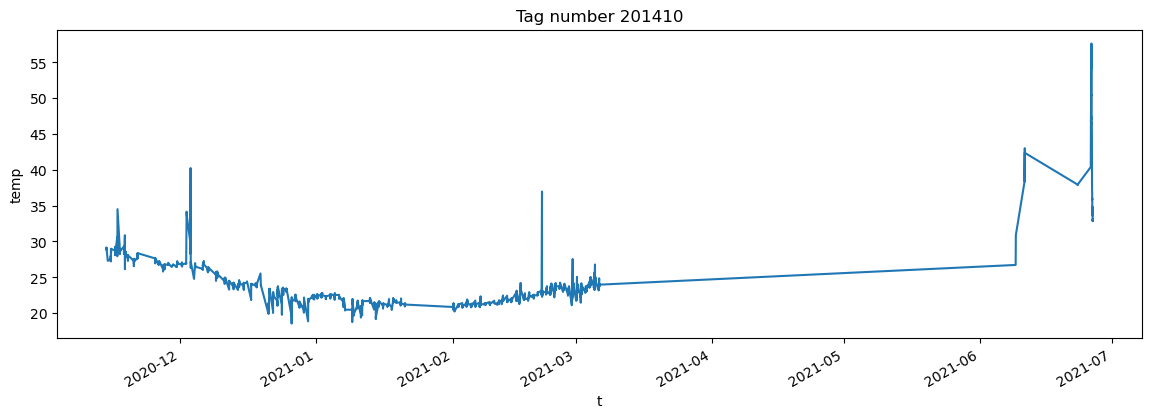

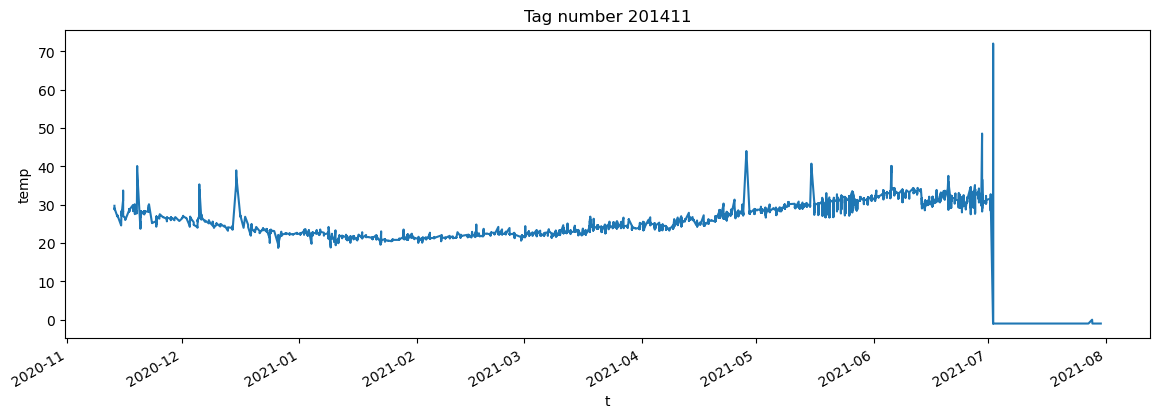

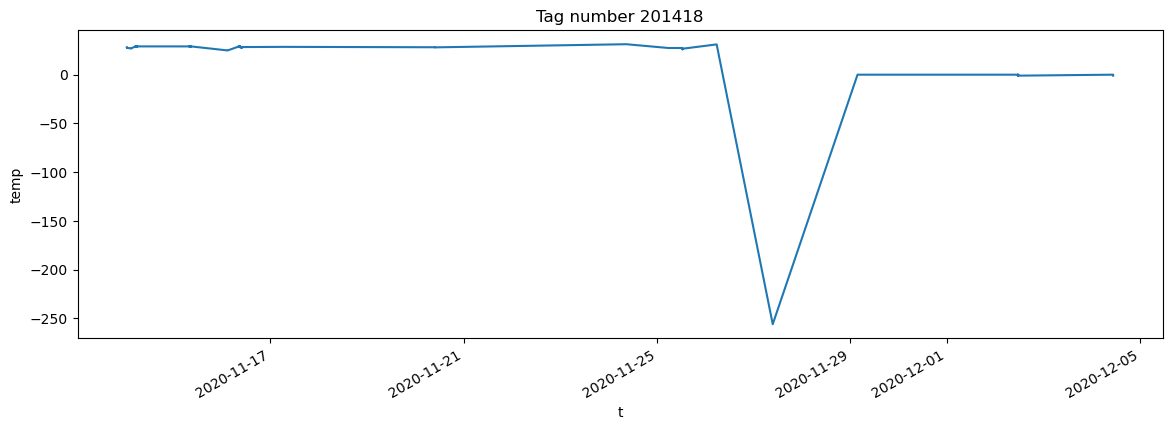

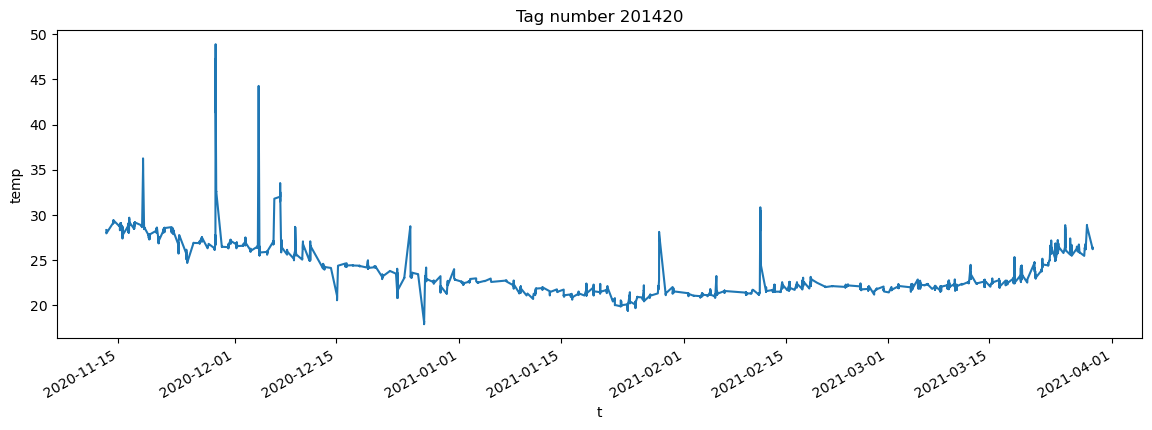

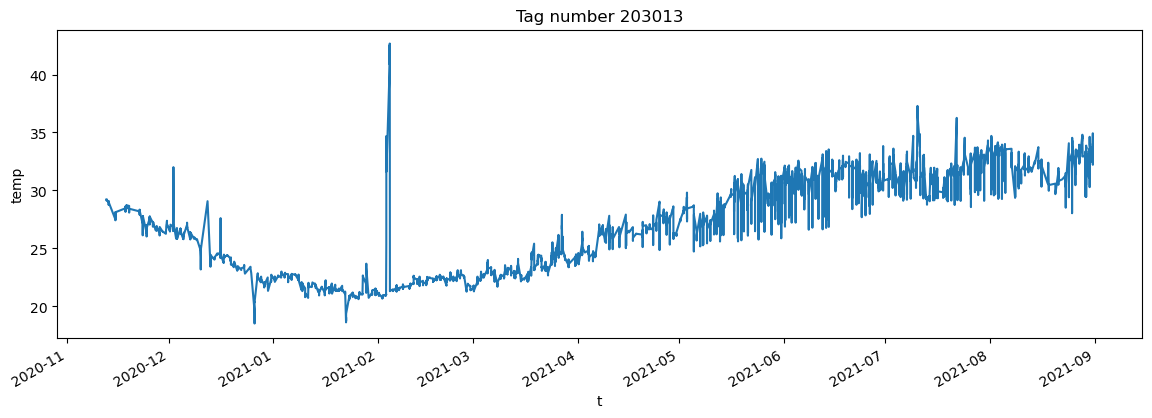

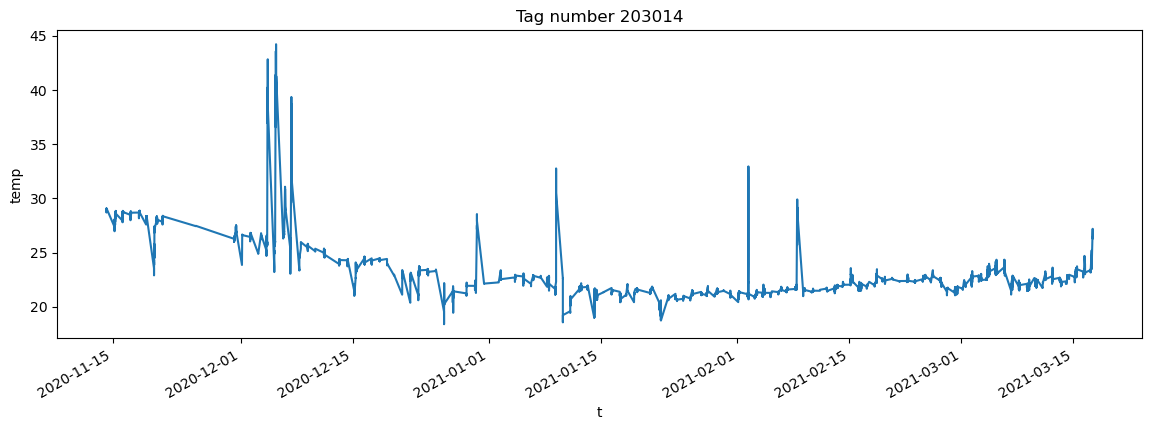

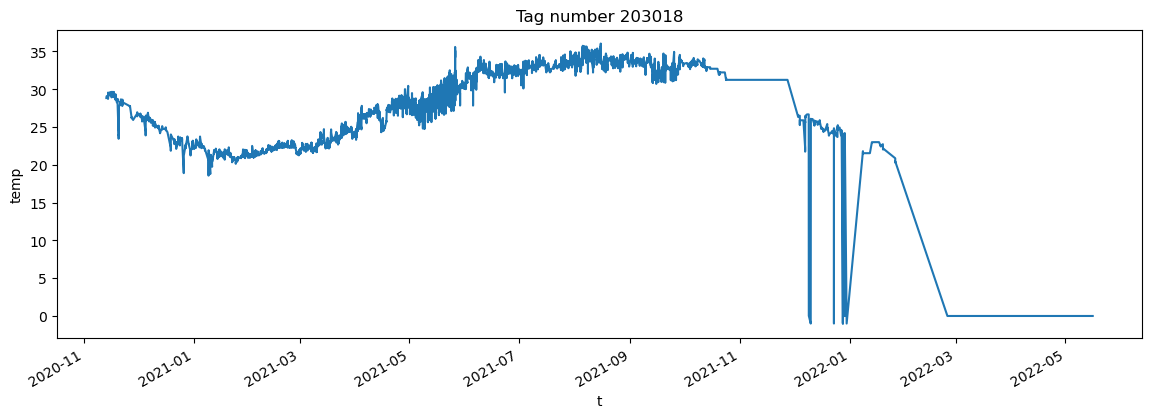

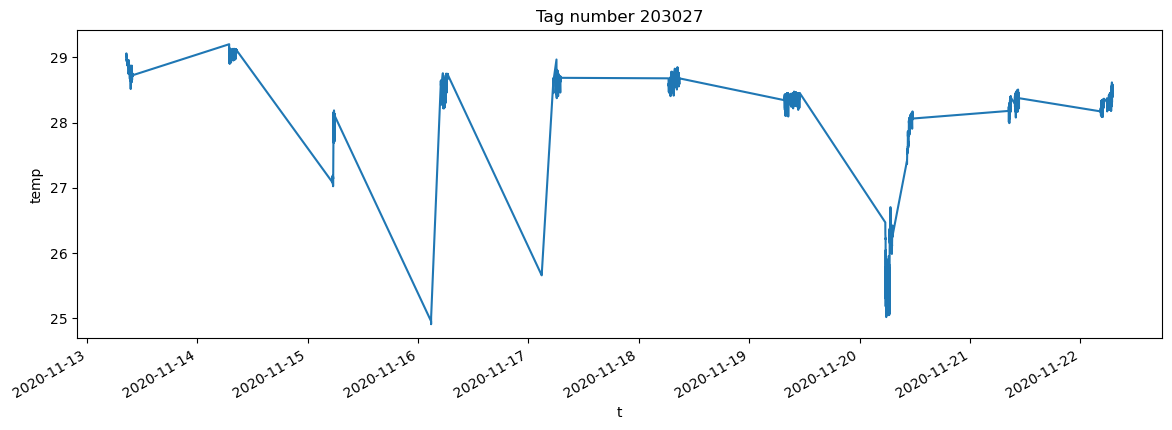

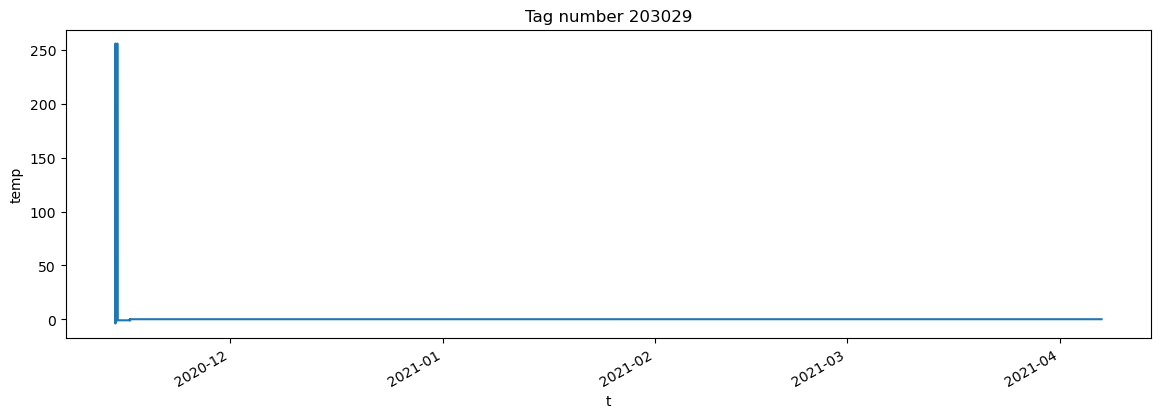

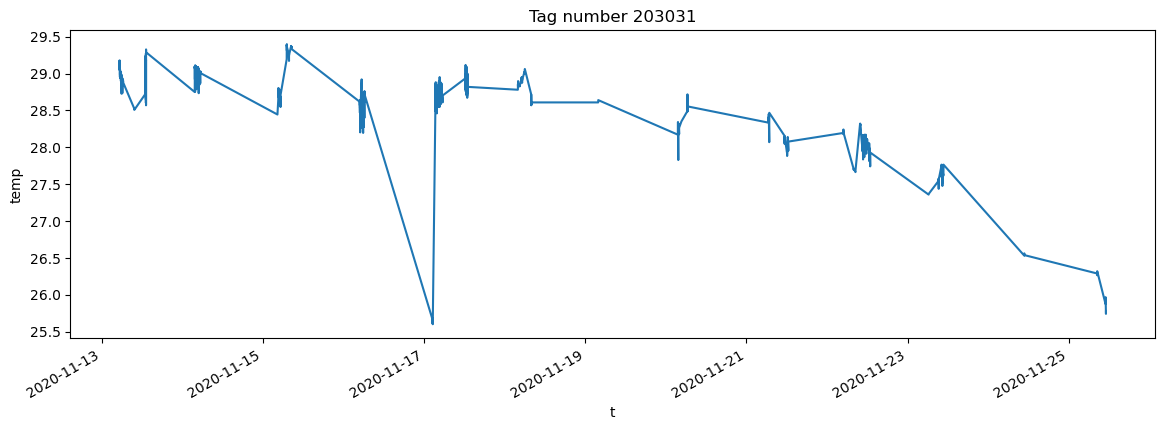

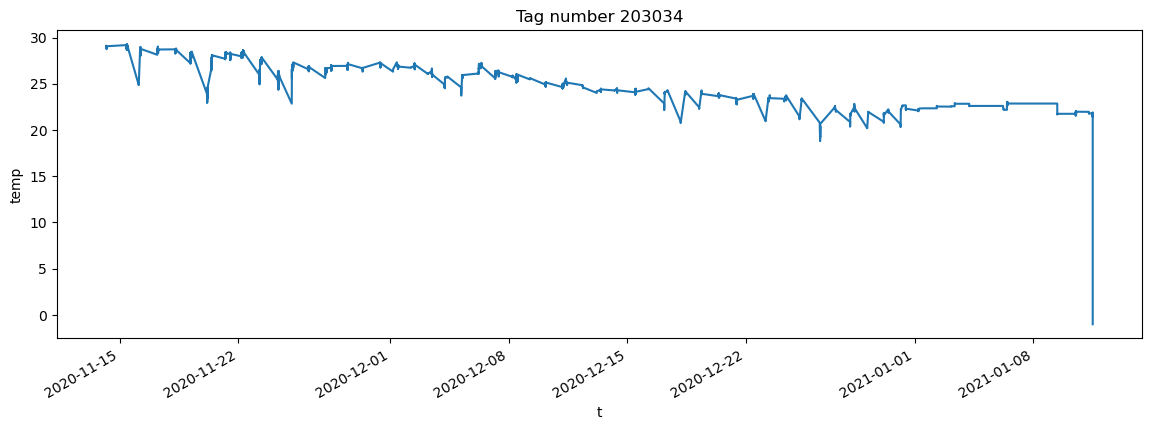

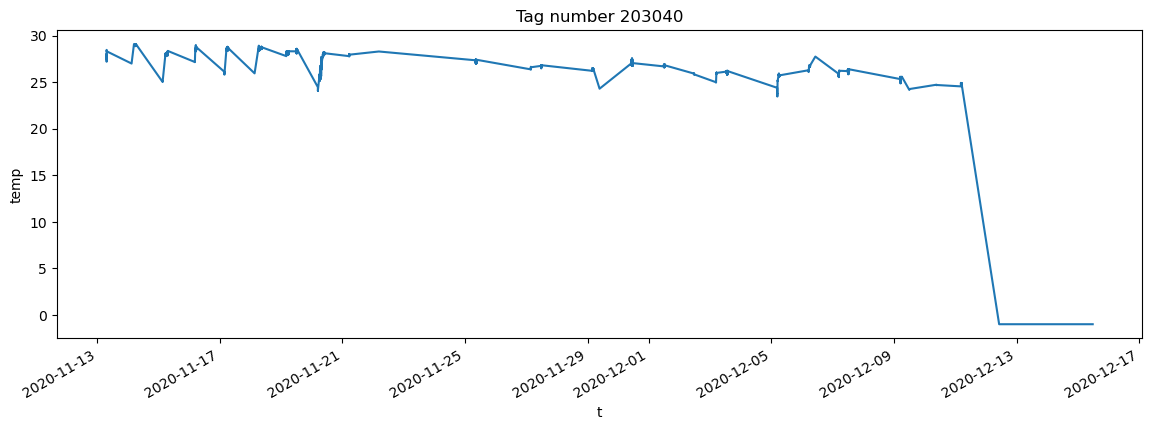

In [17]:
for i in np.unique(ds_obs.id):
    print(i)
    ds_obs_1 = ds_obs.where((ds_obs.id == i),drop=True)
    print(ds_obs_1.time)
    plt.figure(figsize=(14,4))
    ds_obs_1.where(ds_obs_1.datatype=='SEND_ALL2_1Hz',drop=True).temp.plot()
    plt.title(f'Tag number {i}')

    # break

# calculate the total number of SEND_ALL2_1HZ, data for all tags

## UAEBUSO20

201410
201411
201418
201420
203013
203014
203018
203027
203029
203031
203034
203040


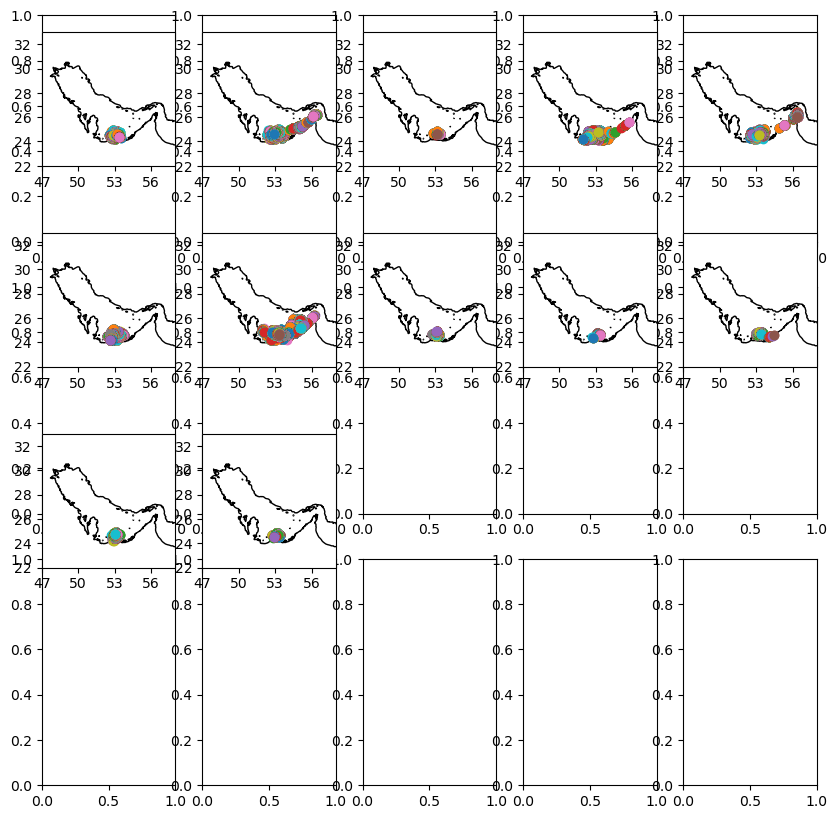

In [45]:
ds_dive_1 = xr.Dataset(
    {
        'tag_id': ('dive_index', np.array([])),
        'temp1': ('dive_index', np.array([])),
        'temp0': ('dive_index', np.array([])),
        'temp_int1': ('dive_index', np.array([])),
        'temp_int0': ('dive_index', np.array([])),
        'rec_len': ('dive_index', np.array([])),
        'first_record': ('dive_index', np.array([])),
        'last_record': ('dive_index', np.array([])),
        'depth_max': ('dive_index', np.array([])),
    },
    coords={'dive_index': np.array([])}
)

fig,axs = plt.subplots(3,5,figsize=(10,10))
iplt = 0
for idn in np.unique(ds_obs1.id):
    print(idn)
    # create ds_obs_1 for one tag
    ds_obs_1 = ds_obs1.where((ds_obs1.id == idn),drop=True)
    # Create a new integer coordinate
    new_t = np.arange(len(ds_obs_1['t']))

    # Optionally, store the original time as a data variable for reference
    ds_obs_1 = ds_obs_1.assign(original_time=('time_index', ds_obs_1['t'].values))

    # Assign the new integer coordinate while keeping the original as a variable
    ds_obs_1 = ds_obs_1.assign_coords(t=new_t).rename({'t': 'time_index'})

    # assign a new variable 'mask' (with NaNs)
    ds_obs_1 = ds_obs_1.assign(mask=(('time_index',), np.full(ds_obs_1.dims['time_index'], np.nan)))

    # Find the indices where 'datatype' is 'GPS'
    # list the "indices" where the difference between two consecutive indices is greater than 10
    # assign a new mask for each of these indices

    gps_indices = ds_obs_1.time_index.where((ds_obs_1.datatype == 'GPS')|(ds_obs_1.datatype == 'GPSS')|(ds_obs_1.datatype == 'GPSD'), drop=True).values.astype(int)

    indices = [(i, j, j-i) for i, j in zip(gps_indices[:-1], gps_indices[1:]) if j - i > 10]
    imask = 0
    for idx in indices:
        # print(idx)
        ds_obs_1['mask'].loc[dict(time_index=slice(idx[0], idx[1]))] = imask
        imask = imask+1
    
    # for each chunk between two GPS records, find the indices where the datatype is 'SEND_ALL2_1Hz'
    imask = 0


    # Define indices_inbox list
    ds_obs_1['mask2'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')
    ds_obs_1['lon_bef'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')
    ds_obs_1['lat_bef'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')
    ds_obs_1['lon_end'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')
    ds_obs_1['lat_end'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')
    ds_obs_1['temp_int_bef'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')
    ds_obs_1['temp_int_end'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')

    ax = plt.subplot(4, 5, iplt + 1, projection=ccrs.PlateCarree())
    # first find the indices whose GPS location is in the box
    for idx in indices:
        p1 = ds_obs_1.isel(time_index=idx[0])
        p2 = ds_obs_1.isel(time_index=idx[1])

        if 'SEND_ALL2_1Hz' in ds_obs_1.datatype.isel(time_index=slice(idx[0], idx[1])).values:
            # Find pairs of 'SEND_ALL2_1Hz_START' and 'SEND_ALL2_1Hz_END' in ds_obs_1.datatype.isel(time_index=slice(idx[0], idx[1]))
            start_indices = ds_obs_1.time_index.where(ds_obs_1.datatype.isel(time_index=slice(idx[0], idx[1])) == 'SEND_ALL2_1Hz_START', drop=True).values.astype(int)
            end_indices = ds_obs_1.time_index.where(ds_obs_1.datatype.isel(time_index=slice(idx[0], idx[1])) == 'SEND_ALL2_1Hz_END', drop=True).values.astype(int)
            
            # Ensure that each start has a corresponding end
            for start, end in zip(start_indices, end_indices):
                if start < end:
                    ds_obs_1['mask2'].loc[dict(time_index=slice(start, end))] = imask
                    ds_obs_1['lon_bef'].loc[dict(time_index=slice(start, end))] = p1.lon.values
                    ds_obs_1['lat_bef'].loc[dict(time_index=slice(start, end))] = p1.lat.values
                    ds_obs_1['lon_end'].loc[dict(time_index=slice(start, end))] = p2.lon.values
                    ds_obs_1['lat_end'].loc[dict(time_index=slice(start, end))] = p2.lat.values
                    ds_obs_1['temp_int_bef'].loc[dict(time_index=slice(start, end))] = p1.temp_int.values
                    ds_obs_1['temp_int_end'].loc[dict(time_index=slice(start, end))] = p2.temp_int.values
                    dnmax = np.max(ds_obs_1['depth'].loc[dict(time_index=slice(start, end))].values)
                    new_data = xr.Dataset(
                        {
                            'temp1': ('dive_index', [ds_obs_1.temp.isel(time_index=end).values]),
                            'temp0': ('dive_index', [ds_obs_1.temp.isel(time_index=start).values]),
                            'temp_int1': ('dive_index', [ds_obs_1.temp_int_end.isel(time_index=end).values]),
                            'temp_int0': ('dive_index', [ds_obs_1.temp_int_bef.isel(time_index=start).values]),
                            'rec_len': ('dive_index', [(end-start).astype(float)]),
                            'first_record': ('dive_index', [start]),
                            'lon': ('dive_index', [ds_obs_1.lon_end.isel(time_index=end).values]),
                            'lat': ('dive_index', [ds_obs_1.lat_end.isel(time_index=end).values]),
                            'time': ('dive_index', [ds_obs_1.original_time.isel(time_index=end).values]),
                            'last_record': ('dive_index', [end]),
                            'tag_id': ('dive_index', [idn]),
                            'depth_max': ('dive_index', [dnmax]),
                        },
                        coords={'dive_index': [imask]}
                    )
            
                    # Concatenate with existing dataset
                    ds_dive_1 = xr.concat([ds_dive_1, new_data], dim='dive_index')   
                    imask += 1

                    plt.plot([p1.lon.values,p2.lon.values], [p1.lat.values,p2.lat.values],'o')
    ax.coastlines()
    ax.set_xlim(47,58)
    ax.set_ylim(22,33)
    ax.set_xticks(np.arange(47,58,3), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(22,33,2), crs=ccrs.PlateCarree())
    # ax.legend(loc = "upper left")
    iplt += 1


In [50]:
ds_dive_1.to_netcdf('PG_dive_info_v1_UAEBUSO20.nc',mode='w')

## BAHHAO20-23

215435
215437
215438
215439
215440
215441
215442
215443
215445
215446
215447
215448
215450
215451
215452
215453
215454
215455
215457
215458
215459
215460
225687
225688
237244
237245
237246
237247
237248
237249
237250
237251
237252
237253
237254
237255
237256
237257
237258
237259
237260
237261
237262
237263


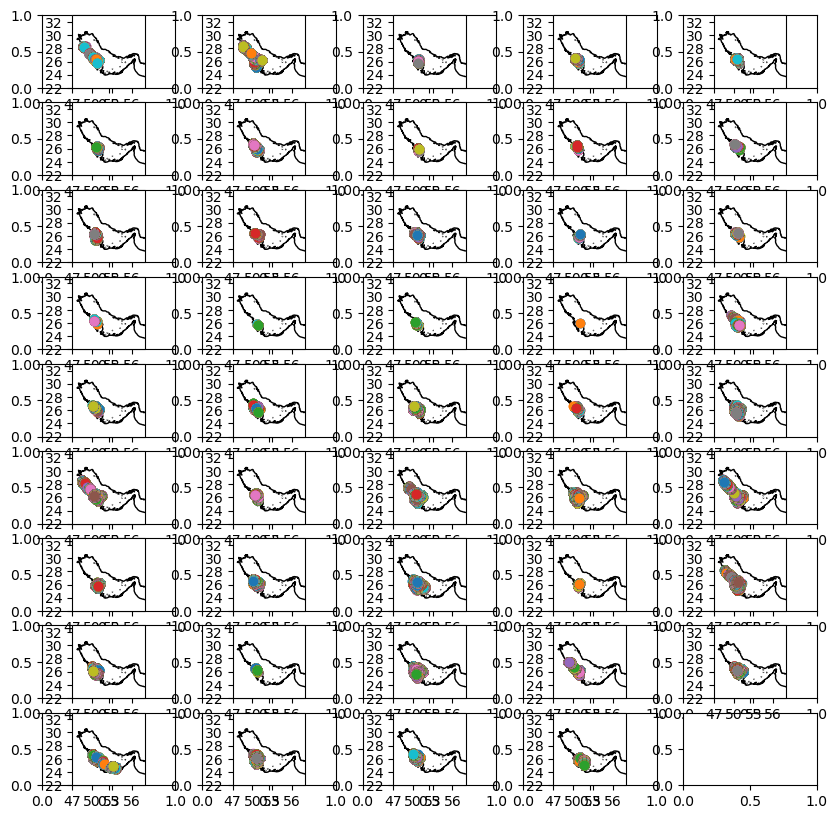

In [47]:
ds_dive_2 = xr.Dataset(
    {
        'tag_id': ('dive_index', np.array([])),
        'temp1': ('dive_index', np.array([])),
        'temp0': ('dive_index', np.array([])),
        'temp_int1': ('dive_index', np.array([])),
        'temp_int0': ('dive_index', np.array([])),
        'rec_len': ('dive_index', np.array([])),
        'first_record': ('dive_index', np.array([])),
        'last_record': ('dive_index', np.array([])),
        'depth_max': ('dive_index', np.array([])),
    },
    coords={'dive_index': np.array([])}
)

fig,axs = plt.subplots(9,5,figsize=(10,10))
iplt = 0
for idn in np.unique(ds_obs2.id):
    print(idn)
    # create ds_obs_1 for one tag
    ds_obs_1 = ds_obs2.where((ds_obs2.id == idn),drop=True)
    # Create a new integer coordinate
    new_t = np.arange(len(ds_obs_1['t']))

    # Optionally, store the original time as a data variable for reference
    ds_obs_1 = ds_obs_1.assign(original_time=('time_index', ds_obs_1['t'].values))

    # Assign the new integer coordinate while keeping the original as a variable
    ds_obs_1 = ds_obs_1.assign_coords(t=new_t).rename({'t': 'time_index'})

    # assign a new variable 'mask' (with NaNs)
    ds_obs_1 = ds_obs_1.assign(mask=(('time_index',), np.full(ds_obs_1.dims['time_index'], np.nan)))

    # Find the indices where 'datatype' is 'GPS'
    # list the "indices" where the difference between two consecutive indices is greater than 10
    # assign a new mask for each of these indices

    gps_indices = ds_obs_1.time_index.where((ds_obs_1.datatype == 'GPS')|(ds_obs_1.datatype == 'GPSS')|(ds_obs_1.datatype == 'GPSD'), drop=True).values.astype(int)

    indices = [(i, j, j-i) for i, j in zip(gps_indices[:-1], gps_indices[1:]) if j - i > 10]
    imask = 0
    for idx in indices:
        # print(idx)
        ds_obs_1['mask'].loc[dict(time_index=slice(idx[0], idx[1]))] = imask
        imask = imask+1
    
    # for each chunk between two GPS records, find the indices where the datatype is 'SEND_ALL2_1Hz'
    imask = 0


    # Define indices_inbox list
    ds_obs_1['mask2'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')
    ds_obs_1['lon_bef'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')
    ds_obs_1['lat_bef'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')
    ds_obs_1['lon_end'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')
    ds_obs_1['lat_end'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')
    ds_obs_1['temp_int_bef'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')
    ds_obs_1['temp_int_end'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')

    ax = plt.subplot(9, 5, iplt + 1, projection=ccrs.PlateCarree())
    # first find the indices whose GPS location is in the box
    for idx in indices:
        p1 = ds_obs_1.isel(time_index=idx[0])
        p2 = ds_obs_1.isel(time_index=idx[1])

        if 'SEND_ALL2_1Hz' in ds_obs_1.datatype.isel(time_index=slice(idx[0], idx[1])).values:
            # Find pairs of 'SEND_ALL2_1Hz_START' and 'SEND_ALL2_1Hz_END' in ds_obs_1.datatype.isel(time_index=slice(idx[0], idx[1]))
            start_indices = ds_obs_1.time_index.where(ds_obs_1.datatype.isel(time_index=slice(idx[0], idx[1])) == 'SEND_ALL2_1Hz_START', drop=True).values.astype(int)
            end_indices = ds_obs_1.time_index.where(ds_obs_1.datatype.isel(time_index=slice(idx[0], idx[1])) == 'SEND_ALL2_1Hz_END', drop=True).values.astype(int)
            
            # Ensure that each start has a corresponding end
            for start, end in zip(start_indices, end_indices):
                if start < end:
                    ds_obs_1['mask2'].loc[dict(time_index=slice(start, end))] = imask
                    ds_obs_1['lon_bef'].loc[dict(time_index=slice(start, end))] = p1.lon.values
                    ds_obs_1['lat_bef'].loc[dict(time_index=slice(start, end))] = p1.lat.values
                    ds_obs_1['lon_end'].loc[dict(time_index=slice(start, end))] = p2.lon.values
                    ds_obs_1['lat_end'].loc[dict(time_index=slice(start, end))] = p2.lat.values
                    ds_obs_1['temp_int_bef'].loc[dict(time_index=slice(start, end))] = p1.temp_int.values
                    ds_obs_1['temp_int_end'].loc[dict(time_index=slice(start, end))] = p2.temp_int.values
                    dnmax = np.max(ds_obs_1['depth'].loc[dict(time_index=slice(start, end))].values)
                    new_data = xr.Dataset(
                        {
                            'temp1': ('dive_index', [ds_obs_1.temp.isel(time_index=end).values]),
                            'temp0': ('dive_index', [ds_obs_1.temp.isel(time_index=start).values]),
                            'temp_int1': ('dive_index', [ds_obs_1.temp_int_end.isel(time_index=end).values]),
                            'temp_int0': ('dive_index', [ds_obs_1.temp_int_bef.isel(time_index=start).values]),
                            'rec_len': ('dive_index', [(end-start).astype(float)]),
                            'first_record': ('dive_index', [start]),
                            'lon': ('dive_index', [ds_obs_1.lon_end.isel(time_index=end).values]),
                            'lat': ('dive_index', [ds_obs_1.lat_end.isel(time_index=end).values]),
                            'time': ('dive_index', [ds_obs_1.original_time.isel(time_index=end).values]),
                            'last_record': ('dive_index', [end]),
                            'tag_id': ('dive_index', [idn]),
                            'depth_max': ('dive_index', [dnmax]),
                        },
                        coords={'dive_index': [imask]}
                    )
            
                    # Concatenate with existing dataset
                    ds_dive_2 = xr.concat([ds_dive_2, new_data], dim='dive_index')   
                    imask += 1

                    plt.plot([p1.lon.values,p2.lon.values], [p1.lat.values,p2.lat.values],'o')
    ax.coastlines()
    ax.set_xlim(47,58)
    ax.set_ylim(22,33)
    ax.set_xticks(np.arange(47,58,3), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(22,33,2), crs=ccrs.PlateCarree())
    # ax.legend(loc = "upper left")
    iplt += 1


In [49]:
ds_dive_2.to_netcdf('PG_dive_info_v1_BAHHASO.nc',mode='w')

## SAUJUSO23

225646
225647
225649
225650
225651
225653
225655
225656


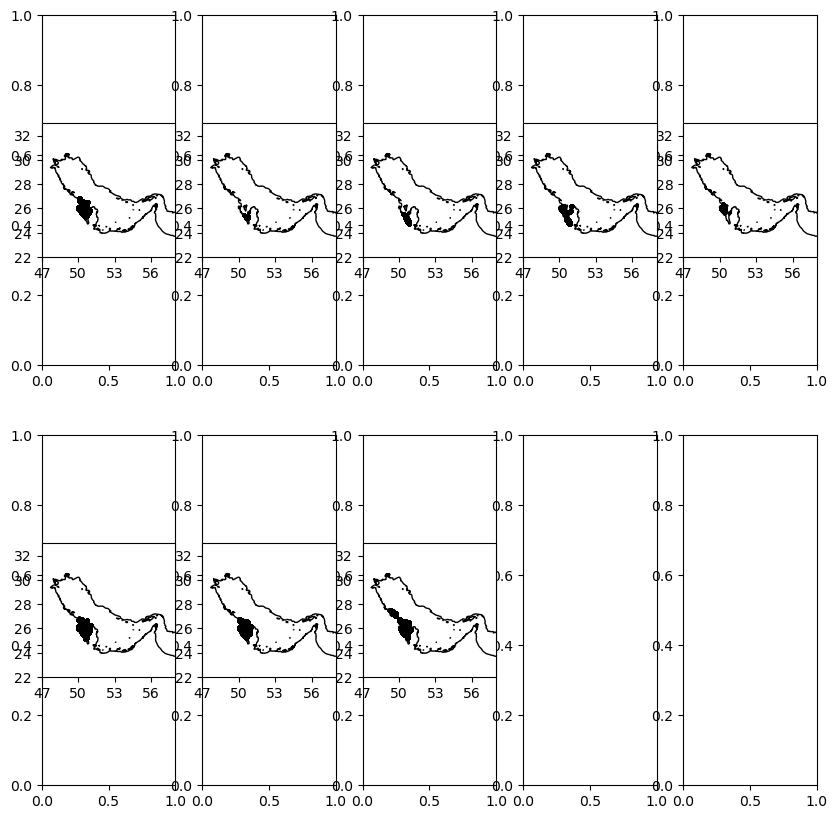

In [51]:
ds_dive_3 = xr.Dataset(
    {
        'tag_id': ('dive_index', np.array([])),
        'temp1': ('dive_index', np.array([])),
        'temp0': ('dive_index', np.array([])),
        'temp_int1': ('dive_index', np.array([])),
        'temp_int0': ('dive_index', np.array([])),
        'rec_len': ('dive_index', np.array([])),
        'first_record': ('dive_index', np.array([])),
        'last_record': ('dive_index', np.array([])),
        'depth_max': ('dive_index', np.array([])),
    },
    coords={'dive_index': np.array([])}
)

fig,axs = plt.subplots(2,5,figsize=(10,10))
iplt = 0
for idn in np.unique(ds_obs3.id):
    print(idn)
    # create ds_obs_1 for one tag
    ds_obs_1 = ds_obs3.where((ds_obs3.id == idn),drop=True)
    # Create a new integer coordinate
    new_t = np.arange(len(ds_obs_1['t']))

    # Optionally, store the original time as a data variable for reference
    ds_obs_1 = ds_obs_1.assign(original_time=('time_index', ds_obs_1['t'].values))

    # Assign the new integer coordinate while keeping the original as a variable
    ds_obs_1 = ds_obs_1.assign_coords(t=new_t).rename({'t': 'time_index'})

    # assign a new variable 'mask' (with NaNs)
    ds_obs_1 = ds_obs_1.assign(mask=(('time_index',), np.full(ds_obs_1.dims['time_index'], np.nan)))

    # Find the indices where 'datatype' is 'GPS'
    # list the "indices" where the difference between two consecutive indices is greater than 10
    # assign a new mask for each of these indices

    gps_indices = ds_obs_1.time_index.where((ds_obs_1.datatype == 'GPS')|(ds_obs_1.datatype == 'GPSS')|(ds_obs_1.datatype == 'GPSD'), drop=True).values.astype(int)

    indices = [(i, j, j-i) for i, j in zip(gps_indices[:-1], gps_indices[1:]) if j - i > 10]
    imask = 0
    for idx in indices:
        # print(idx)
        ds_obs_1['mask'].loc[dict(time_index=slice(idx[0], idx[1]))] = imask
        imask = imask+1
    
    # for each chunk between two GPS records, find the indices where the datatype is 'SEND_ALL2_1Hz'
    imask = 0


    # Define indices_inbox list
    ds_obs_1['mask2'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')
    ds_obs_1['lon_bef'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')
    ds_obs_1['lat_bef'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')
    ds_obs_1['lon_end'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')
    ds_obs_1['lat_end'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')
    ds_obs_1['temp_int_bef'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')
    ds_obs_1['temp_int_end'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')

    ax = plt.subplot(2, 5, iplt + 1, projection=ccrs.PlateCarree())
    # first find the indices whose GPS location is in the box
    for idx in indices:
        p1 = ds_obs_1.isel(time_index=idx[0])
        p2 = ds_obs_1.isel(time_index=idx[1])

        if 'SEND_ALL2_1Hz' in ds_obs_1.datatype.isel(time_index=slice(idx[0], idx[1])).values:
            # Find pairs of 'SEND_ALL2_1Hz_START' and 'SEND_ALL2_1Hz_END' in ds_obs_1.datatype.isel(time_index=slice(idx[0], idx[1]))
            start_indices = ds_obs_1.time_index.where(ds_obs_1.datatype.isel(time_index=slice(idx[0], idx[1])) == 'SEND_ALL2_1Hz_START', drop=True).values.astype(int)
            end_indices = ds_obs_1.time_index.where(ds_obs_1.datatype.isel(time_index=slice(idx[0], idx[1])) == 'SEND_ALL2_1Hz_END', drop=True).values.astype(int)
            
            # Ensure that each start has a corresponding end
            for start, end in zip(start_indices, end_indices):
                if start < end:
                    ds_obs_1['mask2'].loc[dict(time_index=slice(start, end))] = imask
                    ds_obs_1['lon_bef'].loc[dict(time_index=slice(start, end))] = p1.lon.values
                    ds_obs_1['lat_bef'].loc[dict(time_index=slice(start, end))] = p1.lat.values
                    ds_obs_1['lon_end'].loc[dict(time_index=slice(start, end))] = p2.lon.values
                    ds_obs_1['lat_end'].loc[dict(time_index=slice(start, end))] = p2.lat.values
                    ds_obs_1['temp_int_bef'].loc[dict(time_index=slice(start, end))] = p1.temp_int.values
                    ds_obs_1['temp_int_end'].loc[dict(time_index=slice(start, end))] = p2.temp_int.values
                    dnmax = np.max(ds_obs_1['depth'].loc[dict(time_index=slice(start, end))].values)
                    new_data = xr.Dataset(
                        {
                            'temp1': ('dive_index', [ds_obs_1.temp.isel(time_index=end).values]),
                            'temp0': ('dive_index', [ds_obs_1.temp.isel(time_index=start).values]),
                            'temp_int1': ('dive_index', [ds_obs_1.temp_int_end.isel(time_index=end).values]),
                            'temp_int0': ('dive_index', [ds_obs_1.temp_int_bef.isel(time_index=start).values]),
                            'rec_len': ('dive_index', [(end-start).astype(float)]),
                            'first_record': ('dive_index', [start]),
                            'lon': ('dive_index', [ds_obs_1.lon_end.isel(time_index=end).values]),
                            'lat': ('dive_index', [ds_obs_1.lat_end.isel(time_index=end).values]),
                            'time': ('dive_index', [ds_obs_1.original_time.isel(time_index=end).values]),
                            'last_record': ('dive_index', [end]),
                            'tag_id': ('dive_index', [idn]),
                            'depth_max': ('dive_index', [dnmax]),
                        },
                        coords={'dive_index': [imask]}
                    )
            
                    # Concatenate with existing dataset
                    ds_dive_3 = xr.concat([ds_dive_3, new_data], dim='dive_index')   
                    imask += 1

                    plt.plot([p1.lon.values,p2.lon.values], [p1.lat.values,p2.lat.values],'ok',markersize=2)
    ax.coastlines()
    ax.set_xlim(47,58)
    ax.set_ylim(22,33)
    ax.set_xticks(np.arange(47,58,3), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(22,33,2), crs=ccrs.PlateCarree())
    # ax.legend(loc = "upper left")
    iplt += 1


In [52]:
ds_dive_3.to_netcdf('PG_dive_info_v1_UAEJUSO23.nc',mode='w')

## UAESISO20

203023


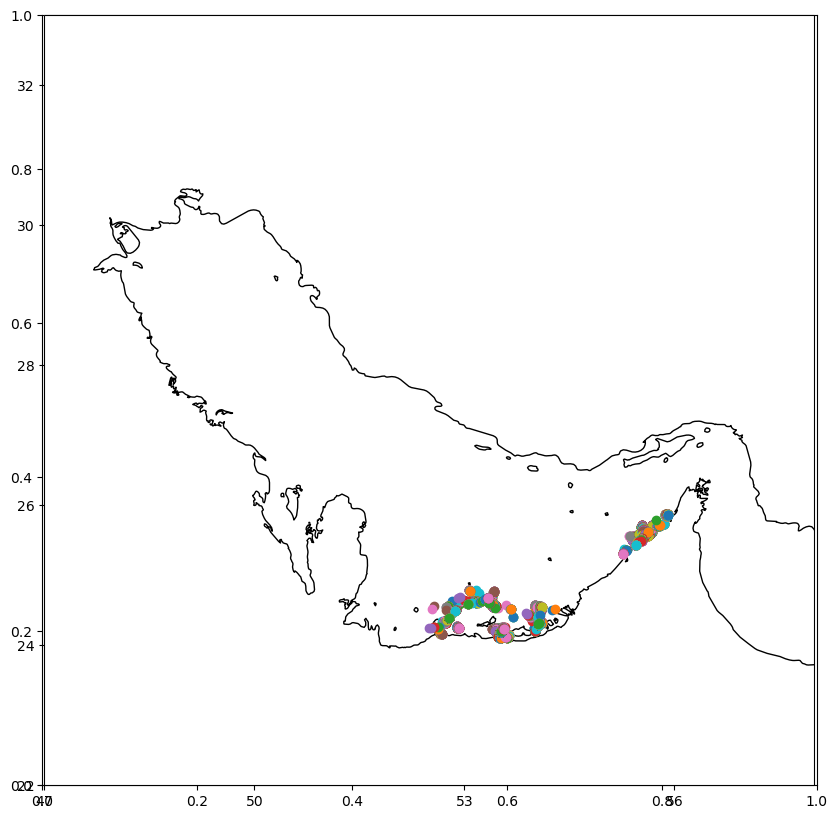

In [53]:
ds_dive_4 = xr.Dataset(
    {
        'tag_id': ('dive_index', np.array([])),
        'temp1': ('dive_index', np.array([])),
        'temp0': ('dive_index', np.array([])),
        'temp_int1': ('dive_index', np.array([])),
        'temp_int0': ('dive_index', np.array([])),
        'rec_len': ('dive_index', np.array([])),
        'first_record': ('dive_index', np.array([])),
        'last_record': ('dive_index', np.array([])),
        'depth_max': ('dive_index', np.array([])),
    },
    coords={'dive_index': np.array([])}
)

fig,axs = plt.subplots(1,1,figsize=(10,10))
iplt = 0
for idn in np.unique(ds_obs4.id):
    print(idn)
    # create ds_obs_1 for one tag
    ds_obs_1 = ds_obs4.where((ds_obs4.id == idn),drop=True)
    # Create a new integer coordinate
    new_t = np.arange(len(ds_obs_1['t']))

    # Optionally, store the original time as a data variable for reference
    ds_obs_1 = ds_obs_1.assign(original_time=('time_index', ds_obs_1['t'].values))

    # Assign the new integer coordinate while keeping the original as a variable
    ds_obs_1 = ds_obs_1.assign_coords(t=new_t).rename({'t': 'time_index'})

    # assign a new variable 'mask' (with NaNs)
    ds_obs_1 = ds_obs_1.assign(mask=(('time_index',), np.full(ds_obs_1.dims['time_index'], np.nan)))

    # Find the indices where 'datatype' is 'GPS'
    # list the "indices" where the difference between two consecutive indices is greater than 10
    # assign a new mask for each of these indices

    gps_indices = ds_obs_1.time_index.where((ds_obs_1.datatype == 'GPS')|(ds_obs_1.datatype == 'GPSS')|(ds_obs_1.datatype == 'GPSD'), drop=True).values.astype(int)

    indices = [(i, j, j-i) for i, j in zip(gps_indices[:-1], gps_indices[1:]) if j - i > 10]
    imask = 0
    for idx in indices:
        # print(idx)
        ds_obs_1['mask'].loc[dict(time_index=slice(idx[0], idx[1]))] = imask
        imask = imask+1
    
    # for each chunk between two GPS records, find the indices where the datatype is 'SEND_ALL2_1Hz'
    imask = 0


    # Define indices_inbox list
    ds_obs_1['mask2'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')
    ds_obs_1['lon_bef'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')
    ds_obs_1['lat_bef'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')
    ds_obs_1['lon_end'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')
    ds_obs_1['lat_end'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')
    ds_obs_1['temp_int_bef'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')
    ds_obs_1['temp_int_end'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')

    ax = plt.subplot(1, 1, iplt + 1, projection=ccrs.PlateCarree())
    # first find the indices whose GPS location is in the box
    for idx in indices:
        p1 = ds_obs_1.isel(time_index=idx[0])
        p2 = ds_obs_1.isel(time_index=idx[1])

        if 'SEND_ALL2_1Hz' in ds_obs_1.datatype.isel(time_index=slice(idx[0], idx[1])).values:
            # Find pairs of 'SEND_ALL2_1Hz_START' and 'SEND_ALL2_1Hz_END' in ds_obs_1.datatype.isel(time_index=slice(idx[0], idx[1]))
            start_indices = ds_obs_1.time_index.where(ds_obs_1.datatype.isel(time_index=slice(idx[0], idx[1])) == 'SEND_ALL2_1Hz_START', drop=True).values.astype(int)
            end_indices = ds_obs_1.time_index.where(ds_obs_1.datatype.isel(time_index=slice(idx[0], idx[1])) == 'SEND_ALL2_1Hz_END', drop=True).values.astype(int)
            
            # Ensure that each start has a corresponding end
            for start, end in zip(start_indices, end_indices):
                if start < end:
                    ds_obs_1['mask2'].loc[dict(time_index=slice(start, end))] = imask
                    ds_obs_1['lon_bef'].loc[dict(time_index=slice(start, end))] = p1.lon.values
                    ds_obs_1['lat_bef'].loc[dict(time_index=slice(start, end))] = p1.lat.values
                    ds_obs_1['lon_end'].loc[dict(time_index=slice(start, end))] = p2.lon.values
                    ds_obs_1['lat_end'].loc[dict(time_index=slice(start, end))] = p2.lat.values
                    ds_obs_1['temp_int_bef'].loc[dict(time_index=slice(start, end))] = p1.temp_int.values
                    ds_obs_1['temp_int_end'].loc[dict(time_index=slice(start, end))] = p2.temp_int.values
                    dnmax = np.max(ds_obs_1['depth'].loc[dict(time_index=slice(start, end))].values)
                    new_data = xr.Dataset(
                        {
                            'temp1': ('dive_index', [ds_obs_1.temp.isel(time_index=end).values]),
                            'temp0': ('dive_index', [ds_obs_1.temp.isel(time_index=start).values]),
                            'temp_int1': ('dive_index', [ds_obs_1.temp_int_end.isel(time_index=end).values]),
                            'temp_int0': ('dive_index', [ds_obs_1.temp_int_bef.isel(time_index=start).values]),
                            'rec_len': ('dive_index', [(end-start).astype(float)]),
                            'first_record': ('dive_index', [start]),
                            'lon': ('dive_index', [ds_obs_1.lon_end.isel(time_index=end).values]),
                            'lat': ('dive_index', [ds_obs_1.lat_end.isel(time_index=end).values]),
                            'time': ('dive_index', [ds_obs_1.original_time.isel(time_index=end).values]),
                            'last_record': ('dive_index', [end]),
                            'tag_id': ('dive_index', [idn]),
                            'depth_max': ('dive_index', [dnmax]),
                        },
                        coords={'dive_index': [imask]}
                    )
            
                    # Concatenate with existing dataset
                    ds_dive_4 = xr.concat([ds_dive_4, new_data], dim='dive_index')   
                    imask += 1

                    plt.plot([p1.lon.values,p2.lon.values], [p1.lat.values,p2.lat.values],'o')
    ax.coastlines()
    ax.set_xlim(47,58)
    ax.set_ylim(22,33)
    ax.set_xticks(np.arange(47,58,3), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(22,33,2), crs=ccrs.PlateCarree())
    # ax.legend(loc = "upper left")
    iplt += 1


In [54]:
ds_dive_4.to_netcdf('PG_dive_info_v1_UAESISO20.nc',mode='w')

## load dive info from netcdf

In [16]:
ds_dive_1 = xr.open_dataset('PG_dive_info_v1_UAEBUSO20.nc')
ds_dive_2 = xr.open_dataset('PG_dive_info_v1_BAHHASO.nc')
ds_dive_3 = xr.open_dataset('PG_dive_info_v1_UAEJUSO23.nc')
ds_dive_4 = xr.open_dataset('PG_dive_info_v1_UAESISO20.nc')

In [490]:
ds_dive_2.where(ds_dive_2.time<pd.Timestamp('2024-1-1'),drop=True)

<xarray.Dataset>
Dimensions:       (dive_index: 222055)
Coordinates:
  * dive_index    (dive_index) float64 0.0 1.0 2.0 ... 7.926e+03 7.927e+03
Data variables:
    tag_id        (dive_index) float64 2.154e+05 2.154e+05 ... 2.373e+05
    temp1         (dive_index) float64 27.39 27.42 27.43 ... 22.92 22.93 22.93
    temp0         (dive_index) float64 27.34 27.39 27.41 ... 22.95 22.94 22.94
    temp_int1     (dive_index) float64 28.0 28.0 28.0 28.0 ... 23.0 23.0 23.0
    temp_int0     (dive_index) float64 29.0 29.0 29.0 29.0 ... 23.0 23.0 23.0
    rec_len       (dive_index) float64 13.0 12.0 12.0 13.0 ... 20.0 26.0 22.0
    first_record  (dive_index) float64 7.261e+03 7.275e+03 ... 2.228e+05
    last_record   (dive_index) float64 7.274e+03 7.287e+03 ... 2.228e+05
    depth_max     (dive_index) float64 1.83 1.65 1.68 1.53 ... 4.59 4.62 4.62
    lon           (dive_index) float64 50.79 50.79 50.79 ... 51.62 51.62 51.62
    lat           (dive_index) float64 25.74 25.74 25.74 ... 25.55 25.55 25.55
    time          (dive_index) datetime64[ns] 2022-11-14T05:40:33 ... 2023-12...

# 1. Find the bottom dives / max depth / duration of dives

In [ ]:
# Initialize the new variables in ds_obs_1
# ds_obs_1['first_record'] = xr.DataArray(np.full(ds_obs_1.dims['time_index'], np.nan), dims='time_index')
# ds_obs_1['last_record'] = xr.DataArray(np.full(ds_obs_1.dims['time_index'], np.nan), dims='time_index')
# ds_obs_1['dtb'] = xr.DataArray(np.full(ds_obs_1.dims['time_index'], np.nan), dims='time_index')

# Create an empty pandas DataFrame to store the results
# pd_dive = pd.DataFrame(columns=['ik', 'first_record', 'last_record', 'dtb', 'dmax','T_surf','T_bot'])
ds_dive = xr.Dataset(
    {
        'tag_id': ('dive_index', np.array([])),
        'temp1': ('dive_index', np.array([])),
        'temp0': ('dive_index', np.array([])),
        # 'temp_int1': ('dive_index', np.array([])),
        # 'temp_int0': ('dive_index', np.array([])),
        'rec_len_bot': ('dive_index', np.array([])),
        'depth_max': ('dive_index', np.array([])),
        'first_record': ('dive_index', np.array([])),
        'last_record': ('dive_index', np.array([]))
    },
    coords={'dive_index': np.array([])}
)

for ik in np.unique(ds_obs_1.mask2)[1:]:  ### omit 0_start from 1 ___
# for ik in range(30):
    if ik % 100 == 0:
        print(f'Processing mask2 value: {ik}')
    # plt.figure(figsize=(14,4))
    # plt.plot(ds_obs_1.where(ds_obs_1.mask2==ik+1,drop=True).original_time,ds_obs_1.where(ds_obs_1.mask2==ik+1,drop=True).temp)
    profile0 = ds_obs_1.where(ds_obs_1.mask2==ik,drop=True)
    dd = profile0.depth
    dnmax = np.max(dd).values
    # print(dd.values,dnmax.values)
    nn = len(dd[dd - dnmax <= 0.5])
    first_record = dd[abs(dd - dnmax)<=0.5].time_index.values[0]
    last_record = dd[abs(dd - dnmax) <= 0.5].time_index.values[-1]
    # dtb = (profile0.original_time.sel(time_index=last_record) - profile0.original_time.sel(time_index=first_record)).values/np.timedelta64(1, 's')
    temp_surf = profile0.temp.isel(time_index=-1).values
    temp_surf0 = profile0.temp.isel(time_index=0).values
    # temp_bot = profile0.temp.sel(time_index=last_record).values
    # print(dtb_seconds)
    # print(nn)
    # plt.plot(ds_obs_1.where(ds_obs_1.mask2==ik+1,drop=True).original_time,ds_obs_1.where(ds_obs_1.mask2==ik+1,drop=True).depth)
    # plt.title(f'Tag number {idn} - {ik+1} - {dtb_seconds:.2f} seconds - {nn} records')
    # ds_obs_1['first_record'] = xr.where(ds_obs_1.mask2 == ik+1, first_record, ds_obs_1.first_record)
    # ds_obs_1['last_record'] = xr.where(ds_obs_1.mask2 == ik+1, last_record, ds_obs_1.last_record)
    # ds_obs_1['dtb'] = xr.where(ds_obs_1.mask2 == ik+1, dtb, ds_obs_1.dtb)

    # Store ik, first_record, last_record, dtb to a pandas DataFrame
    # if 'pd_dive' not in globals():
    #     pd_dive = pd.DataFrame(columns=['ik', 'first_record', 'last_record', 'dtb'])

    # pd_dive = pd.concat([pd_dive, pd.DataFrame({'ik': [ik], 'first_record': [first_record], 'last_record': [last_record], 'dtb': [dtb], 'dmax': [dnmax],'T_surf':[temp_surf],'T_bot':[temp_bot]})], ignore_index=True)
    # pd_dive = pd.concat([pd_dive, pd.DataFrame({'ik': [ik], 'first_record': [first_record], 'last_record': [last_record], 'dmax': [dnmax],'T_surf':[temp_surf],'T_surf0':[temp_surf0]})], ignore_index=True)

    new_data = xr.Dataset(
        {
            'temp1': ('dive_index', [temp_surf]),
            'temp0': ('dive_index', [temp_surf0]),
            # 'temp_int1': ('dive_index', [ds_obs_1.temp_int_end.isel(time_index=end).values]),
            # 'temp_int0': ('dive_index', [ds_obs_1.temp_int_bef.isel(time_index=start).values]),
            'rec_len_bot': ('dive_index', [(last_record-first_record).astype(float)]),
            'first_record': ('dive_index', [first_record]),
            # 'lon': ('dive_index', [ds_obs_1.lon_end.isel(time_index=end).values]),
            # 'lat': ('dive_index', [ds_obs_1.lat_end.isel(time_index=end).values]),
            # 'time': ('dive_index', [ds_obs_1.original_time.isel(time_index=end).values]),
            'last_record': ('dive_index', [last_record]),
            'depth_max': ('dive_index', [dnmax])
        },
        coords={'dive_index': [ik]}
    )

    # Concatenate with existing dataset
    ds_dive = xr.concat([ds_dive, new_data], dim='dive_index')   

Processing mask2 value: 100.0
Processing mask2 value: 200.0
Processing mask2 value: 300.0
Processing mask2 value: 400.0
Processing mask2 value: 500.0
Processing mask2 value: 600.0
Processing mask2 value: 700.0
Processing mask2 value: 800.0
Processing mask2 value: 900.0


(22.0, 30.0)

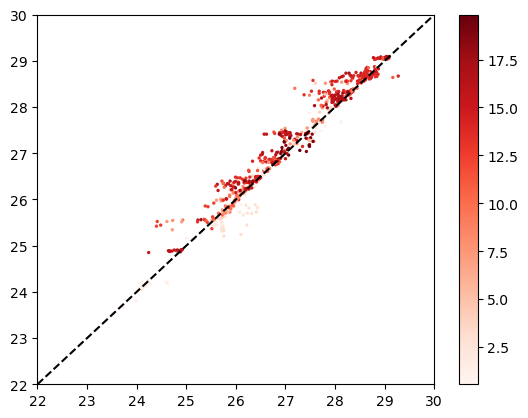

In [123]:
plt.scatter(ds_dive.temp0,ds_dive.temp1,c=ds_dive.depth_max,cmap='Reds',s=2)
# ds_dive.temp0.plot()
plt.colorbar()
# ds_dive.depth_max.plot()
plt.plot([22,30],[22,30],'k--')
plt.xlim(22,30)
plt.ylim(22,30)

In [78]:
pd_dive['lon'] = ds_obs_1.lon_end.isel(time_index=pd_dive['last_record'].values.astype(int)).values
pd_dive['lat'] = ds_obs_1.lat_end.isel(time_index=pd_dive['last_record'].values.astype(int)).values
pd_dive['time'] = ds_obs_1.original_time.isel(time_index=pd_dive['last_record'].values.astype(int)).values
pd_dive['T_bot'] = ds_obs_1.temp.isel(time_index=pd_dive['last_record'].values.astype(int)).values

pd_dive['rec_len'] = pd_dive['last_record']-pd_dive['first_record']
pd_dive

,ik,first_record,last_record,dtb,dmax,T_surf,T_bot,T_surf0,lon,lat,time,rec_len
0,1.0,64,68,NaN,2.91,28.2109375,28.101562,28.2578125,50.780949,25.729845,2023-11-04 06:51:35,4
1,2.0,74,93,NaN,3.04,28.0390625,28.039062,28.140625,50.780949,25.729845,2023-11-04 06:52:05,19
2,3.0,99,128,NaN,2.98,28.0390625,28.015625,28.0390625,50.780411,25.730028,2023-11-04 06:52:49,29
3,4.0,134,149,NaN,1.46,28.3828125,28.406250,28.359375,50.781914,25.724712,2023-11-04 06:54:27,15
4,5.0,153,181,NaN,1.32,28.3671875,28.367188,28.34375,50.781803,25.724785,2023-11-04 06:55:54,28
...,...,...,...,...,...,...,...,...,...,...,...,...
19602,19603.0,609245,609485,NaN,132.56,30.5546875,30.554688,30.28125,50.417881,25.488762,2024-04-26 14:32:49,240
19603,19604.0,609486,609726,NaN,132.56,30.546875,30.546875,30.59375,50.417881,25.488762,2024-04-26 14:40:51,240
19604,19605.0,609727,609967,NaN,132.56,30.359375,30.359375,30.46875,50.417881,25.488762,2024-04-26 14:48:55,240
19605,19606.0,609968,610208,NaN,132.56,30.03125,30.031250,30.21875,50.417881,25.488762,2024-04-26 14:56:59,240


,ik,first_record,last_record,dtb,dmax,T_surf,T_bot,lon,lat,time
0,1.0,64,68,NaN,2.91,28.2109375,28.101562,50.780949,25.729845,2023-11-04 06:51:35
1,2.0,74,93,NaN,3.04,28.0390625,28.039062,50.780949,25.729845,2023-11-04 06:52:05
2,3.0,99,128,NaN,2.98,28.0390625,28.015625,50.780411,25.730028,2023-11-04 06:52:49
3,4.0,134,149,NaN,1.46,28.3828125,28.406250,50.781914,25.724712,2023-11-04 06:54:27
4,5.0,153,181,NaN,1.32,28.3671875,28.367188,50.781803,25.724785,2023-11-04 06:55:54
...,...,...,...,...,...,...,...,...,...,...
19602,19603.0,609245,609485,NaN,132.56,30.5546875,30.554688,50.417881,25.488762,2024-04-26 14:32:49
19603,19604.0,609486,609726,NaN,132.56,30.546875,30.546875,50.417881,25.488762,2024-04-26 14:40:51
19604,19605.0,609727,609967,NaN,132.56,30.359375,30.359375,50.417881,25.488762,2024-04-26 14:48:55
19605,19606.0,609968,610208,NaN,132.56,30.03125,30.031250,50.417881,25.488762,2024-04-26 14:56:59


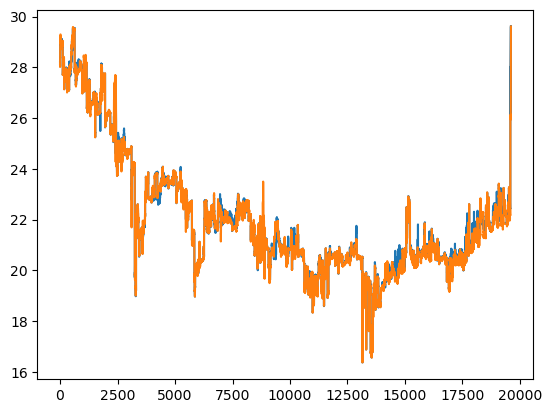

In [55]:
pd_dive[pd_dive['T_surf']<30].T_surf.astype(float).plot()
pd_dive[pd_dive['T_surf']<30].T_bot.astype(float).plot()
pd_dive

<Axes: >

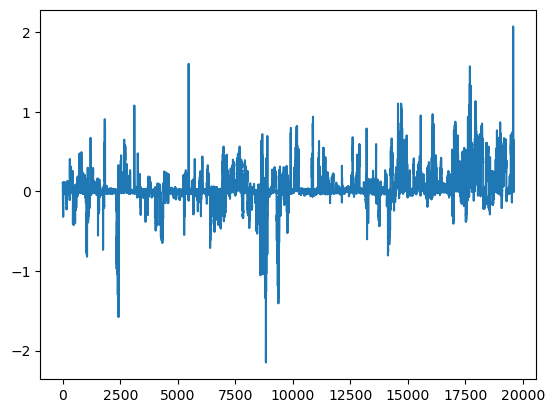

In [104]:
# pd_dive[pd_dive['T_surf']<50].T_surf.astype(float).plot()
(pd_dive[pd_dive['T_surf']<50].T_surf-pd_dive[pd_dive['T_surf']<50].T_bot).astype(float).plot()

In [105]:
pd_dive.to_csv(wrk_dir+'dive_profile_PG_acc_raw_v1_keep_gps_BAHHASO23.csv')

In [106]:
pd_dive = pd.read_csv('dive_profile_PG_acc_raw_v1_keep_gps_BAHHASO23.csv',parse_dates=True,index_col='time')
pd_dive

,Unnamed: 0,ik,first_record,last_record,dtb,dmax,T_surf,T_bot,T_surf0,lon,lat,rec_len
time,,,,,,,,,,,,
2023-11-04 06:51:35,0,1.0,64,68,NaN,2.91,28.210938,28.101562,28.257812,50.780949,25.729845,4
2023-11-04 06:52:05,1,2.0,74,93,NaN,3.04,28.039062,28.039062,28.140625,50.780949,25.729845,19
2023-11-04 06:52:49,2,3.0,99,128,NaN,2.98,28.039062,28.015625,28.039062,50.780411,25.730028,29
2023-11-04 06:54:27,3,4.0,134,149,NaN,1.46,28.382812,28.406250,28.359375,50.781914,25.724712,15
2023-11-04 06:55:54,4,5.0,153,181,NaN,1.32,28.367188,28.367188,28.343750,50.781803,25.724785,28
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-04-26 14:32:49,19602,19603.0,609245,609485,NaN,132.56,30.554688,30.554688,30.281250,50.417881,25.488762,240
2024-04-26 14:40:51,19603,19604.0,609486,609726,NaN,132.56,30.546875,30.546875,30.593750,50.417881,25.488762,240
2024-04-26 14:48:55,19604,19605.0,609727,609967,NaN,132.56,30.359375,30.359375,30.468750,50.417881,25.488762,240


In [107]:
ds_dive = xr.Dataset.from_dataframe(pd_dive)
ds_dive

<xarray.Dataset>
Dimensions:       (time: 19607)
Coordinates:
  * time          (time) datetime64[ns] 2023-11-04T06:51:35 ... 2024-04-26T15...
Data variables:
    Unnamed: 0    (time) int64 0 1 2 3 4 5 ... 19602 19603 19604 19605 19606
    ik            (time) float64 1.0 2.0 3.0 ... 1.96e+04 1.961e+04 1.961e+04
    first_record  (time) int64 64 74 99 134 153 ... 609486 609727 609968 610209
    last_record   (time) int64 68 93 128 149 181 ... 609726 609967 610208 610449
    dtb           (time) float64 nan nan nan nan nan nan ... nan nan nan nan nan
    dmax          (time) float64 2.91 3.04 2.98 1.46 ... 132.6 132.6 132.6 132.6
    T_surf        (time) float64 28.21 28.04 28.04 28.38 ... 30.36 30.03 29.61
    T_bot         (time) float64 28.1 28.04 28.02 28.41 ... 30.36 30.03 29.61
    T_surf0       (time) float64 28.26 28.14 28.04 28.36 ... 30.47 30.22 29.76
    lon           (time) float64 50.78 50.78 50.78 50.78 ... 50.42 50.42 50.42
    lat           (time) float64 25.73 25.73 25.73 25.72 ... 25.49 25.49 25.49
    rec_len       (time) int64 4 19 29 15 28 22 14 ... 240 240 240 240 240 240

In [35]:
ds_mur_sec1=ds_mur.sst.sel(time=slice(ds_dive_2.time.min(),ds_dive_2.time.max()),lon=slice(47,58),lat=slice(22,33))


In [265]:
# UAE 2020
# ds_obs1_rnan = ds_obs1.where((ds_obs1.x>10)&(ds_obs1.y>10)&(ds_obs1.temp<40)&(ds_obs1.temp>10)&(ds_obs1.temp!=31.2421875),drop=True)

# ds_mur_sec1=ds_mur.sst.sel(time=slice(pd_dive.time.min(),pd_dive.time.max()))

fmm1=ds_mur_sec1.interp(lon=ds_dive.lon,lat=ds_dive.lat,time=ds_dive.time) #original

NameError: name 'ds_dive' is not defined

In [261]:
# plot ALL THE DATA (((BEFORE interpolation)))
# ds_obs1_rnan.temp.plot()
# (fmm-273.15).plot()
plt.scatter(fmm1, ds_dive.T_surf, c=ds_dive.T_surf - ds_dive.T_bot, cmap='RdYlBu', s=0.5,vmax=1,vmin=-1)
# plt.scatter(fmm1, ds_dive.T_surf, c=ds_dive.last_record - ds_dive.first_record, cmap='RdBu', s=1)

plt.colorbar(label='T_surf - T_bot')
# plt.colorbar(label='record length (seconds)')



plt.xlim([18, 30]),plt.ylim([18, 30])
plt.plot([18,37],[18,37])

# print(np.sqrt(np.mean(fmm-ds_obs_rnan1.temp)**2).values)
# print(np.sqrt(np.mean(fmm-ds_obs_rnan2.temp)**2).values)
# print(np.sqrt(np.mean(fmm-ds_obs_rnan3.temp)**2).values)
# print(np.sqrt(np.mean(fmm-ds_obs_rnan4.temp)**2).values)

NameError: name 'fmm1' is not defined

In [104]:
# plot ALL THE DATA (((BEFORE interpolation)))
# ds_obs1_rnan.temp.plot()
# (fmm-273.15).plot()
# plt.scatter(fmm1, ds_dive.T_surf, c=ds_dive.T_surf - ds_dive.T_bot, cmap='RdBu', s=0.5,vmax=1,vmin=-1)
plt.figure(figsize=(8,6))
plt.scatter(fmm1, ds_dive.T_surf, c=ds_dive.last_record - ds_dive.first_record, cmap='Reds', s=2,vmax=50)
# plt.scatter(fmm1, ds_dive.where(ds_dive.rec_len<30).T_surf, cmap='RdBu', s=2,vmax=50)
# plt.scatter(fmm1, ds_dive.where(ds_dive.rec_len>30).T_surf, cmap='RdBu', s=2,vmax=50)

# plt.colorbar(label='T_surf - T_bot')
plt.colorbar(label='record length (seconds)')

plt.xlim([18, 30]),plt.ylim([18, 30])
plt.plot([18,37],[18,37])

# print(np.sqrt(np.mean(fmm-ds_obs_rnan1.temp)**2).values)
# print(np.sqrt(np.mean(fmm-ds_obs_rnan2.temp)**2).values)
# print(np.sqrt(np.mean(fmm-ds_obs_rnan3.temp)**2).values)
# print(np.sqrt(np.mean(fmm-ds_obs_rnan4.temp)**2).values)

NameError: name 'fmm1' is not defined

<Figure size 800x600 with 0 Axes>

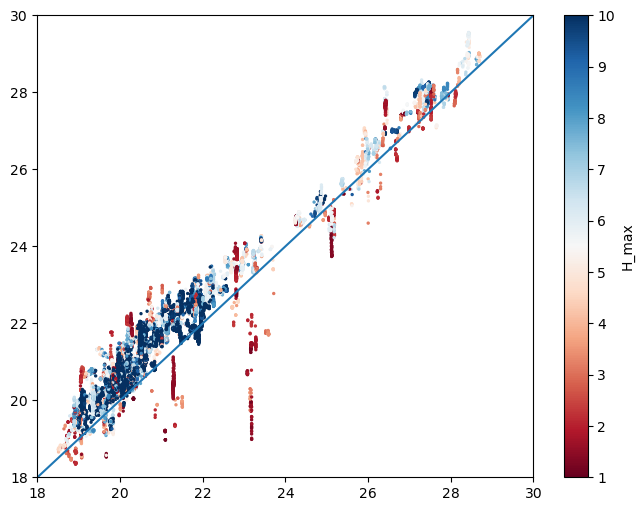

In [74]:
plt.figure(figsize=(8,6))
# plt.scatter(fmm1, ds_dive.T_surf, c=ds_dive.last_record - ds_dive.first_record, cmap='RdBu', s=2,vmax=50)
plt.scatter(fmm1, ds_dive.T_surf, c=ds_dive.dmax, cmap='RdBu', s=2,vmax=10)
# plt.scatter(fmm1, ds_dive.where(ds_dive.rec_len>30).T_surf, cmap='RdBu', s=2,vmax=50)

plt.colorbar(label='H_max (m)')
# plt.colorbar(label='record length (seconds)')

plt.xlim([18, 30]),plt.ylim([18, 30])
plt.plot([18,37],[18,37])

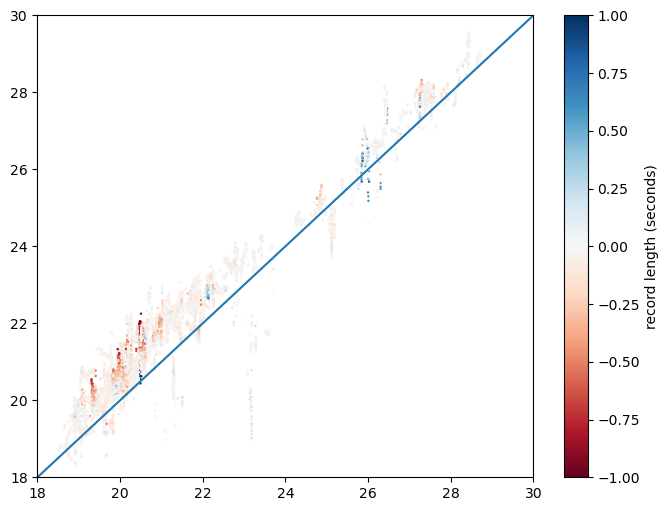

In [ ]:
# plot ALL THE DATA (((BEFORE interpolation)))
# ds_obs1_rnan.temp.plot()
# (fmm-273.15).plot()
plt.figure(figsize=(8,6))
plt.scatter(fmm1, ds_dive.T_surf, c=ds_dive.T_surf0 - ds_dive.T_surf, cmap='RdBu', s=0.5,vmax=1,vmin=-1)
# plt.scatter(fmm1, ds_dive.T_surf, c=(ds_dive.T_surf0 - ds_dive.T_surf)/np.exp(ds_dive.rec_len.astype(float)), cmap='RdBu',vmax=0.001,vmin=-0.001,s=1)
# plt.scatter(fmm1, ds_dive.where(ds_dive.rec_len<30).T_surf, cmap='RdBu', s=2,vmax=50)
# plt.scatter(fmm1, ds_dive.where(ds_dive.rec_len>30).T_surf, cmap='RdBu', s=2,vmax=50)

# plt.colorbar(label='T_surf - T_bot')
plt.colorbar(label='record length (seconds)')

plt.xlim([18, 30]),plt.ylim([18, 30])
plt.plot([18,37],[18,37])

# print(np.sqrt(np.mean(fmm-ds_obs_rnan1.temp)**2).values)
# print(np.sqrt(np.mean(fmm-ds_obs_rnan2.temp)**2).values)
# print(np.sqrt(np.mean(fmm-ds_obs_rnan3.temp)**2).values)
# print(np.sqrt(np.mean(fmm-ds_obs_rnan4.temp)**2).values)

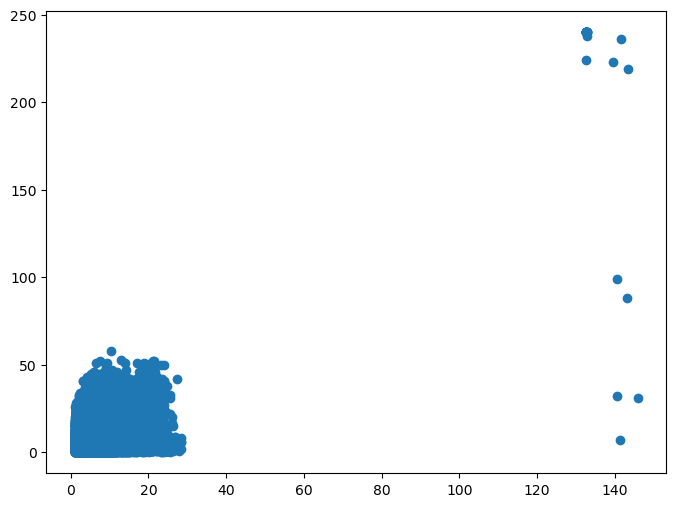

In [96]:

plt.figure(figsize=(8,6))
plt.scatter( ds_dive.dmax,ds_dive.rec_len)

# 2. Find first record and last record for each dive / duration of dives

## do filter / Quality control

### for the UAE 2020

In [17]:
ds_dive_1_filtered = ds_dive_1.where(~((ds_dive_1.tag_id == 203018) & (ds_dive_1.time > pd.Timestamp(2021, 10, 25))), drop=True)
# ds_dive_1.where(ds_dive_1.tag_id == 203018).temp1.plot()
# ds_dive_1_filtered.where(ds_dive_1_filtered.tag_id == 203018).temp1.plot()
ds_dive_1_filtered = ds_dive_1_filtered.where(~((ds_dive_1_filtered.tag_id == 201410) & (ds_dive_1_filtered.time > pd.Timestamp(2021, 3, 25))), drop=True)

ds_dive_1_filtered = ds_dive_1_filtered.where(~((ds_dive_1_filtered.tag_id == 203029) ), drop=True)
ds_dive_1_filtered = ds_dive_1_filtered.where(~((ds_dive_1_filtered.tag_id == 201418) ), drop=True)
ds_dive_1_filtered = ds_dive_1_filtered.where(~((ds_dive_1_filtered.tag_id == 201411)&(ds_dive_1_filtered.temp1 <= 0) ), drop=True)
ds_dive_1_filtered = ds_dive_1_filtered.where(~((ds_dive_1_filtered.tag_id == 203040)&(ds_dive_1_filtered.temp1 < 0) ), drop=True)
ds_dive_1_filtered = ds_dive_1_filtered.where(~((ds_dive_1_filtered.tag_id == 201411)&(ds_dive_1_filtered.temp0 < 0) ), drop=True)

# ds_dive_1.where(ds_dive_1.tag_id == 201411).temp0.plot()
# ds_dive_1_filtered.where(ds_dive_1_filtered.tag_id == 201411).temp0.plot()
# ds_dive_1_filtered.where(ds_dive_1_filtered.tag_id == 201411).temp1.plot()

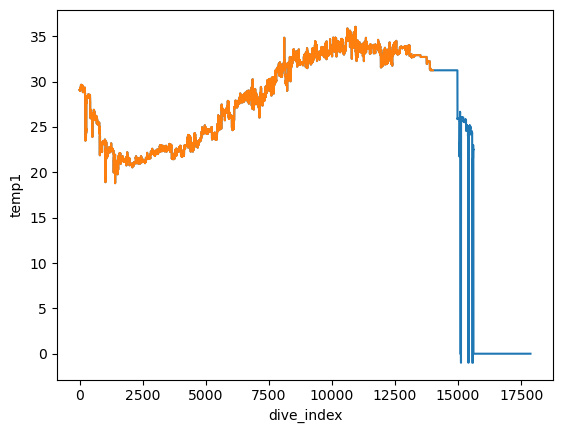

In [18]:
ds_dive_1.where(ds_dive_1.tag_id == 203018).temp1.plot()
ds_dive_1_filtered.where(ds_dive_1_filtered.tag_id == 203018).temp1.plot()


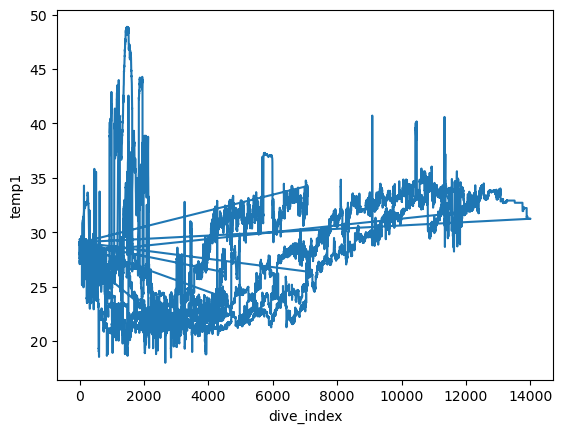

In [19]:
ds_dive_1_filtered.temp1.plot()

### for the BAHHASO21-23

In [20]:
ds_dive_2_filtered = ds_dive_2.where(~((ds_dive_2.tag_id == 215437) & (ds_dive_2.time > pd.Timestamp(2023, 5, 22))), drop=True)
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 215435) & (ds_dive_2_filtered.time > pd.Timestamp(2022, 12, 16))), drop=True)
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 215437) & (ds_dive_2_filtered.time >= pd.Timestamp(2023, 5, 27))), drop=True)
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 215438) & (ds_dive_2_filtered.time > pd.Timestamp(2022, 11, 21))), drop=True)
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 215439) & (ds_dive_2_filtered.time > pd.Timestamp(2022, 11, 25))), drop=True)
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 215440) & (ds_dive_2_filtered.time > pd.Timestamp(2022, 12, 21))), drop=True)
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 215441) & (ds_dive_2_filtered.time > pd.Timestamp(2022, 12, 6))), drop=True)
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 215442) & (ds_dive_2_filtered.time > pd.Timestamp(2021, 12, 13))), drop=True)
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 215443) & (ds_dive_2_filtered.time > pd.Timestamp(2022, 11, 20))), drop=True)
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 215445) & (ds_dive_2_filtered.time > pd.Timestamp(2022, 11, 18))), drop=True)
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 215446) & ((ds_dive_2_filtered.temp1 <= 0)|(ds_dive_2_filtered.temp1 >=55) | (ds_dive_2_filtered.time>pd.Timestamp(2021,12,23)))), drop=True)
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 215447) & (ds_dive_2_filtered.time > pd.Timestamp(2021, 12, 17))), drop=True)
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 215448) & ((ds_dive_2_filtered.temp1 < 0)|(ds_dive_2_filtered.temp1 >100))), drop=True)
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 215450) & (ds_dive_2_filtered.time > pd.Timestamp(2022, 12, 9))), drop=True)
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 215451) & (ds_dive_2_filtered.time >= pd.Timestamp(2022, 11, 14))), drop=True)
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 215452) & (ds_dive_2_filtered.time >= pd.Timestamp(2022, 12, 2))), drop=True)
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 215452) & ((ds_dive_2_filtered.temp0 <= 0)|(ds_dive_2_filtered.temp0 >=55))), drop=True)
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 215453) & (ds_dive_2_filtered.time >= pd.Timestamp(2022, 11, 13))), drop=True)
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 215455) ), drop=True)
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 215458) & ((ds_dive_2_filtered.temp1 <= 0)|(ds_dive_2_filtered.temp1 >=55))), drop=True)
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 215458) & ((ds_dive_2_filtered.temp0 <= 0)|(ds_dive_2_filtered.temp0 >=55))), drop=True)
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 215459) & ((ds_dive_2_filtered.temp1 <= 0)|(ds_dive_2_filtered.temp1 >=55))), drop=True)
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 215459) & ((ds_dive_2_filtered.temp0 <= 0)|(ds_dive_2_filtered.temp0 >=55))), drop=True)
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 215460) & ((ds_dive_2_filtered.temp1 <= 0)|(ds_dive_2_filtered.temp1 >=55))), drop=True)
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 215460) & ((ds_dive_2_filtered.temp0 <= 0)|(ds_dive_2_filtered.temp0 >=55))), drop=True)
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 225688) & ((ds_dive_2_filtered.temp1 <= 0)|(ds_dive_2_filtered.temp1 >=100)| (ds_dive_2_filtered.time >= pd.Timestamp(2022, 12, 2)))), drop=True)
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 237244) & (ds_dive_2_filtered.time >= pd.Timestamp(2024, 4, 1))), drop=True)
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 237256) & (ds_dive_2_filtered.time >= pd.Timestamp(2024, 1, 21))), drop=True)

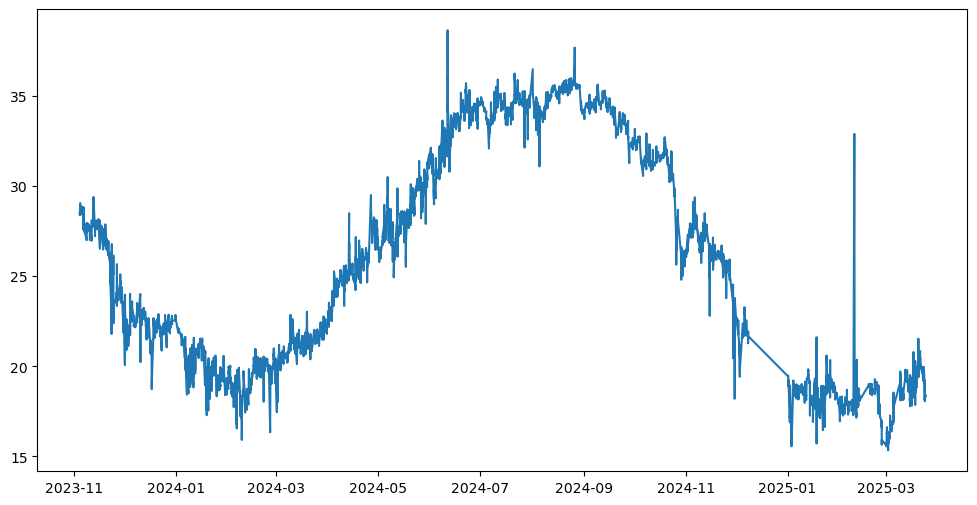

In [21]:
# [215435 215437 215438 215439 215440 215441 215442 215443 215445 215446
#  215447 215448 215450 215451 215452 215453 215454 215455 215457 215458
#  215459 215460 225687 225688 237244 237245 237246 237247 237248 237249
#  237250 237251 237252 237253 237254 237255 237256 237257 237258 237259
#  237260 237261 237262 237263]
# 
id00 = 237249
plt.figure(figsize=(12,6))
# plt.plot(ds_dive_2.time,ds_dive_2.where(ds_dive_2.tag_id == id00).temp0)
plt.plot(ds_dive_2_filtered.where(ds_dive_2_filtered.tag_id == id00).time,ds_dive_2_filtered.where(ds_dive_2_filtered.tag_id == id00).temp1)
# plt.plot(ds_dive_2_filtered.where(ds_dive_2_filtered.tag_id == id00).time,ds_dive_2_filtered.where(ds_dive_2_filtered.tag_id == id00).temp_int1)
# plt.plot(ds_dive_2_filtered.where(ds_dive_2_filtered.tag_id == id00).time,ds_dive_2_filtered.where(ds_dive_2_filtered.tag_id == id00).temp0)
# plt.plot(ds_dive_2.time,ds_dive_2.where((ds_dive_2.tag_id == id00)& (ds_dive_2.time < pd.Timestamp(2021, 12, 17))).temp1)
# plt.plot(ds_dive_2.time,ds_dive_2.where((ds_dive_2.tag_id == id00)& (ds_dive_2.time < pd.Timestamp(2021, 12, 17))).temp0)
# plt.plot(ds_dive_2.time,ds_dive_2.where((ds_dive_2.tag_id == id00)& (ds_dive_2.temp1 < 55)& (ds_dive_2.temp1 > 0)).temp1)
# ds_dive_2_filtered.where(ds_dive_2_filtered.tag_id == 215437).temp1.plot()
# plt.xlim(pd.Timestamp(2021, 12, 11),pd.Timestamp(2021, 12, 13))

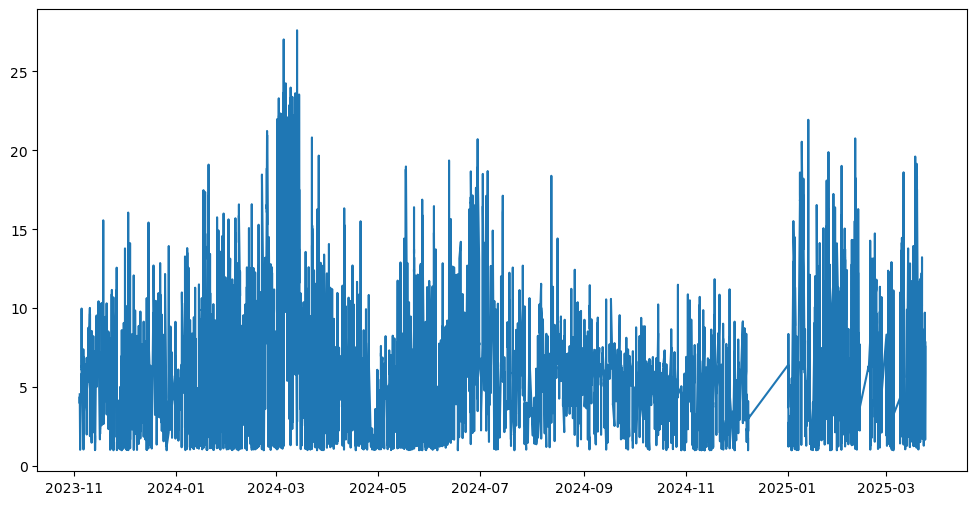

In [22]:

plt.figure(figsize=(12,6))
plt.plot(ds_dive_2_filtered.where(ds_dive_2_filtered.tag_id == id00).time,ds_dive_2_filtered.where(ds_dive_2_filtered.tag_id == id00).depth_max)

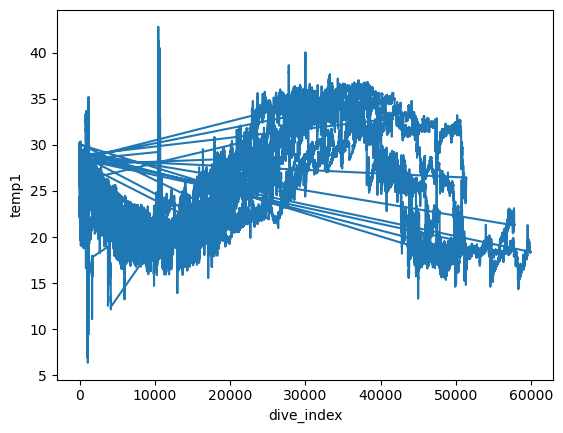

In [23]:
ds_dive_2_filtered.temp1.plot()

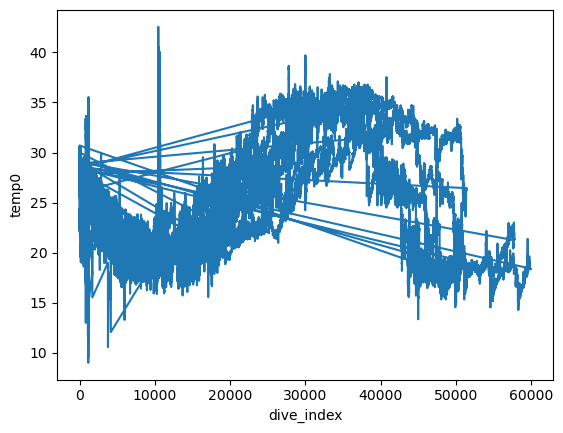

In [24]:
ds_dive_2_filtered.temp0.plot()

#### for SAUJUSO23

In [25]:
ds_dive_3_filtered = ds_dive_3.where(~((ds_dive_3.tag_id == 225656) & (ds_dive_3.time > pd.Timestamp(2024, 5, 22))), drop=True)
ds_dive_3_filtered = ds_dive_3_filtered.where(~((ds_dive_3_filtered.tag_id == 225655) & ((ds_dive_3_filtered.temp1 <= 0)|(ds_dive_3_filtered.temp1 >=55))), drop=True)
ds_dive_3_filtered = ds_dive_3_filtered.where(~((ds_dive_3_filtered.tag_id == 225651) & ((ds_dive_3_filtered.temp1 <= 0)|(ds_dive_3_filtered.temp1 >=55))), drop=True)
ds_dive_3_filtered = ds_dive_3_filtered.where(~((ds_dive_3_filtered.tag_id == 225649) & ((ds_dive_3_filtered.temp1 <= 0)|(ds_dive_3_filtered.temp1 >=55))), drop=True)


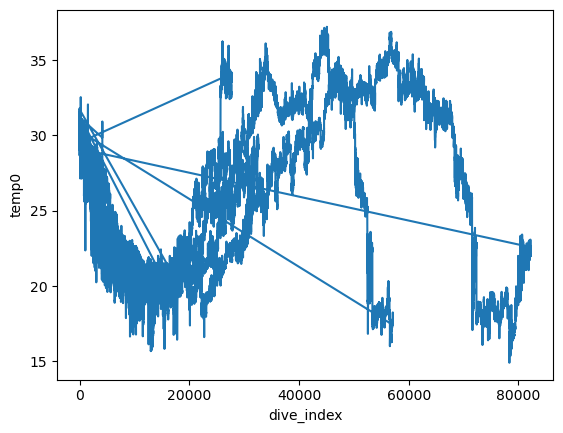

In [26]:
# ds_dive_3.temp1.plot()
ds_dive_3_filtered.temp0.plot()

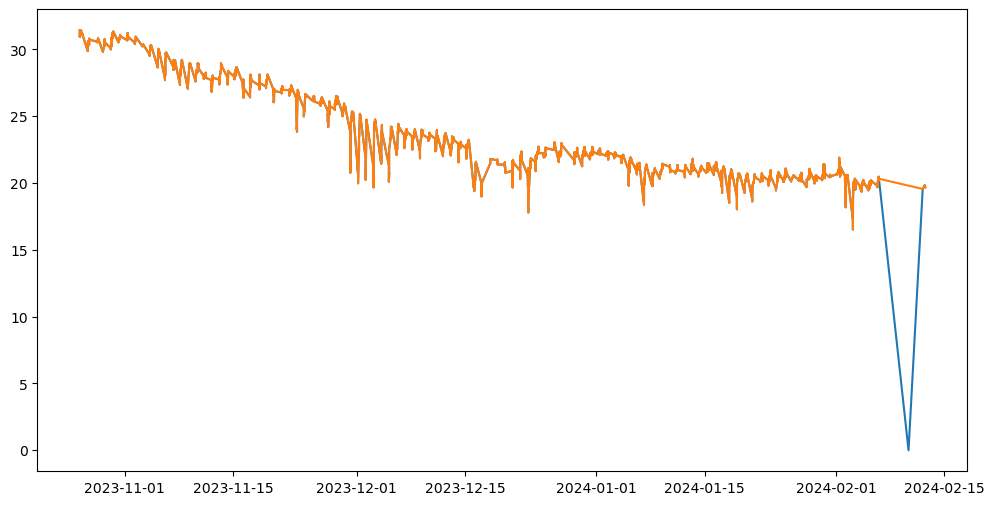

In [27]:
# 
id00 = 225649
plt.figure(figsize=(12,6))
plt.plot(ds_dive_3.time,ds_dive_3.where(ds_dive_3.tag_id == id00).temp1)
plt.plot(ds_dive_3_filtered.where(ds_dive_3_filtered.tag_id == id00).time,ds_dive_3_filtered.where(ds_dive_3_filtered.tag_id == id00).temp1)
# plt.plot(ds_dive_3_filtered.where(ds_dive_3_filtered.tag_id == id00).time,ds_dive_2_filtered.where(ds_dive_2_filtered.tag_id == id00).temp0)
# plt.plot(ds_dive_3.time,ds_dive_3.where((ds_dive_3.tag_id == id00)& (ds_dive_3.time < pd.Timestamp(2024, 5, 22))).temp1)
# plt.plot(ds_dive_2.time,ds_dive_2.where((ds_dive_2.tag_id == id00)& (ds_dive_2.time < pd.Timestamp(2021, 12, 17))).temp0)
# plt.plot(ds_dive_3.time,ds_dive_3.where((ds_dive_3.tag_id == id00)& (ds_dive_3.temp1 < 55)& (ds_dive_3.temp1 > 0)).temp1)
# ds_dive_2_filtered.where(ds_dive_2_filtered.tag_id == 215437).temp1.plot()

### UAESIS20

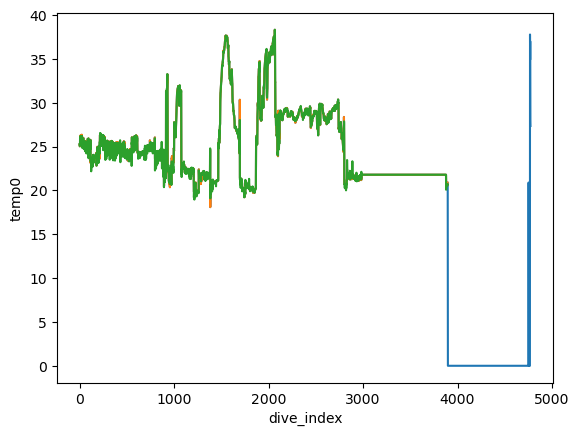

In [28]:
ds_dive_4_filtered = ds_dive_4.where(~((ds_dive_4.tag_id == 203023) & (ds_dive_4.time > pd.Timestamp(2021, 1, 24))), drop=True)

ds_dive_4.temp1.plot()
ds_dive_4_filtered.temp1.plot()
ds_dive_4_filtered.temp0.plot()


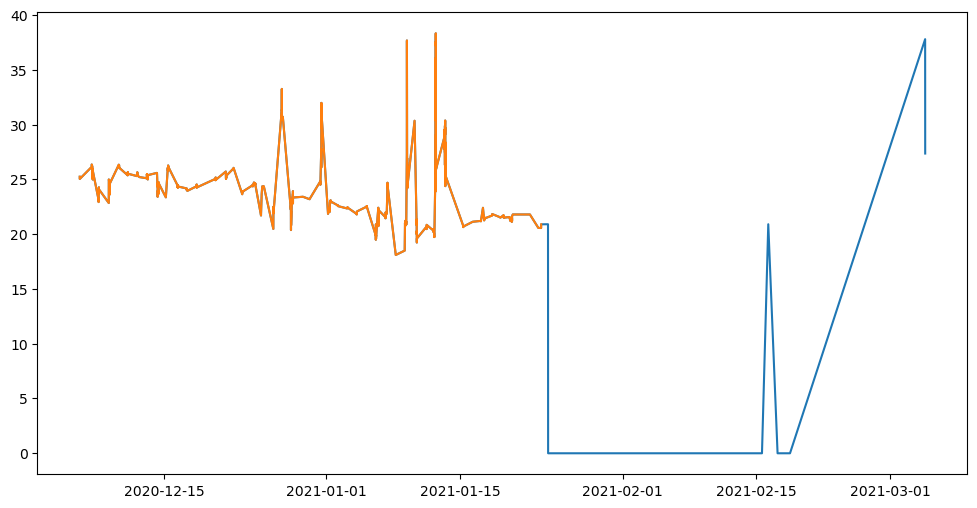

In [191]:
# 
id00 = 203023
plt.figure(figsize=(12,6))
plt.plot(ds_dive_4.time,ds_dive_4.where(ds_dive_4.tag_id == id00).temp1)
# plt.plot(ds_dive_4_filtered.where(ds_dive_2_filtered.tag_id == id00).time,ds_dive_2_filtered.where(ds_dive_2_filtered.tag_id == id00).temp1)
# plt.plot(ds_dive_2_filtered.where(ds_dive_2_filtered.tag_id == id00).time,ds_dive_2_filtered.where(ds_dive_2_filtered.tag_id == id00).temp0)
plt.plot(ds_dive_4.time,ds_dive_4.where((ds_dive_4.tag_id == id00)& (ds_dive_4.time < pd.Timestamp(2021, 1, 24))).temp1)
# plt.plot(ds_dive_2.time,ds_dive_2.where((ds_dive_2.tag_id == id00)& (ds_dive_2.time < pd.Timestamp(2021, 12, 17))).temp0)
# plt.plot(ds_dive_2.time,ds_dive_2.where((ds_dive_2.tag_id == id00)& (ds_dive_2.temp1 < 55)& (ds_dive_2.temp1 > 0)).temp1)
# ds_dive_2_filtered.where(ds_dive_2_filtered.tag_id == 215437).temp1.plot()

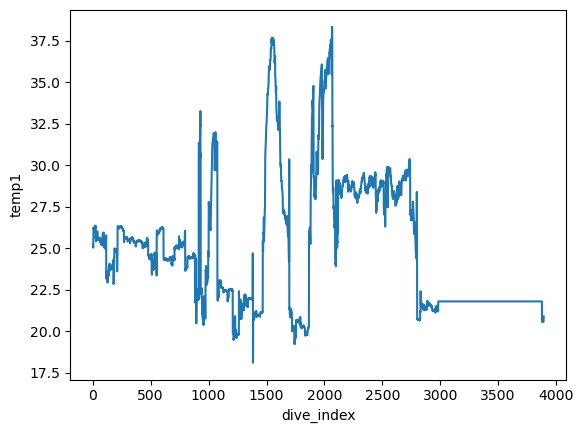

In [23]:
ds_dive_4_filtered.temp1.plot()

## Extremely high temperature case (203014)

(18600.0, 18605.0)

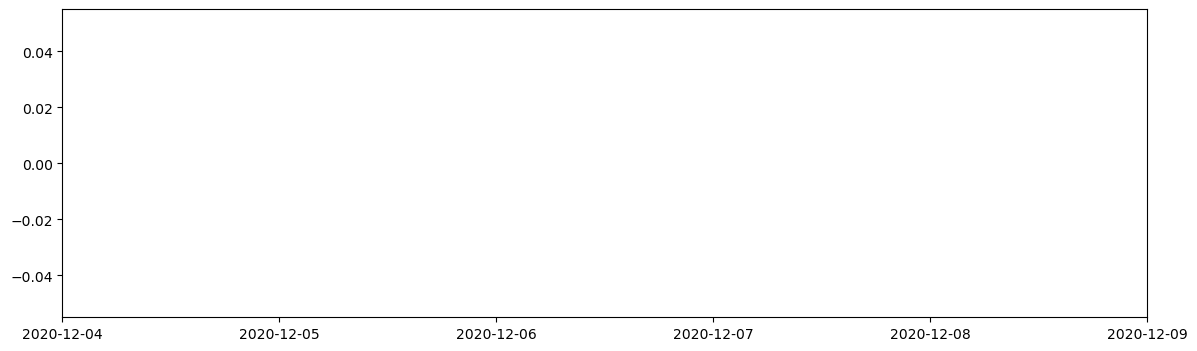

In [29]:
plt.figure(figsize=(14,4))
plt.plot(ds_dive_2_filtered.where(ds_dive_2_filtered.tag_id == 203014).time,ds_dive_2_filtered.where(ds_dive_2_filtered.tag_id == 203014).temp0)
plt.xlim([pd.Timestamp(2020, 12, 4), pd.Timestamp(2020, 12, 9)])

In [ ]:
plt.figure(figsize=(14,4))
plt.plot(ds_obs.where(ds_obs.id == 203014).t,ds_obs.where(ds_obs.id == 203014).temp,label='temp')

plt.plot(ds_obs.where(ds_obs.id == 203014).t,ds_obs.where(ds_obs.id == 203014).depth,label='depth')
plt.plot(ds_obs.where(ds_obs.id == 203014).t,ds_obs.where(ds_obs.id == 203014).temp_int,label='internal temp')
plt.legend()
plt.xlim([pd.Timestamp(2020, 12, 4), pd.Timestamp(2020, 12, 9)])

In [ ]:
plt.figure(figsize=(14,4))
plt.plot(ds_obs1.where(ds_obs.id == 203014).t,ds_obs1.where(ds_obs1.id == 203014).depth)
plt.xlim([pd.Timestamp(2020, 12, 4), pd.Timestamp(2020, 12, 9)])
plt.show()

(18600.0, 18602.0)

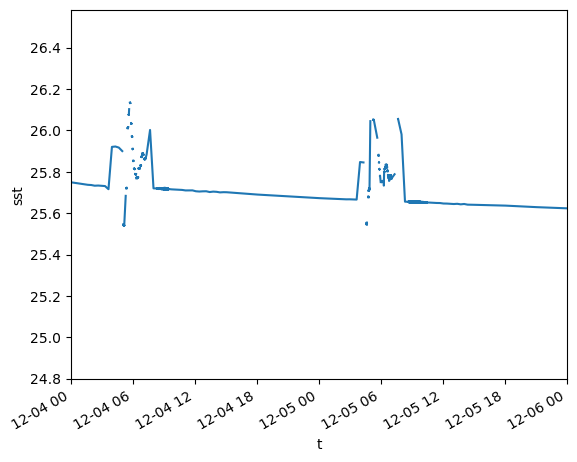

In [68]:
tag_203014_sec = ds_obs1.where((ds_obs1.id == 203014)&(ds_obs1.time>pd.Timestamp(2020, 12, 3))&(ds_obs1.time<pd.Timestamp(2020, 12, 9)),drop=True)

sst_203014_sec = ds_mur_sec1.interp(lon=tag_203014_sec.lon,lat=tag_203014_sec.lat,time=tag_203014_sec.time)

sst_203014_sec.plot()
plt.xlim([pd.Timestamp(2020, 12, 4), pd.Timestamp(2020, 12, 6)])


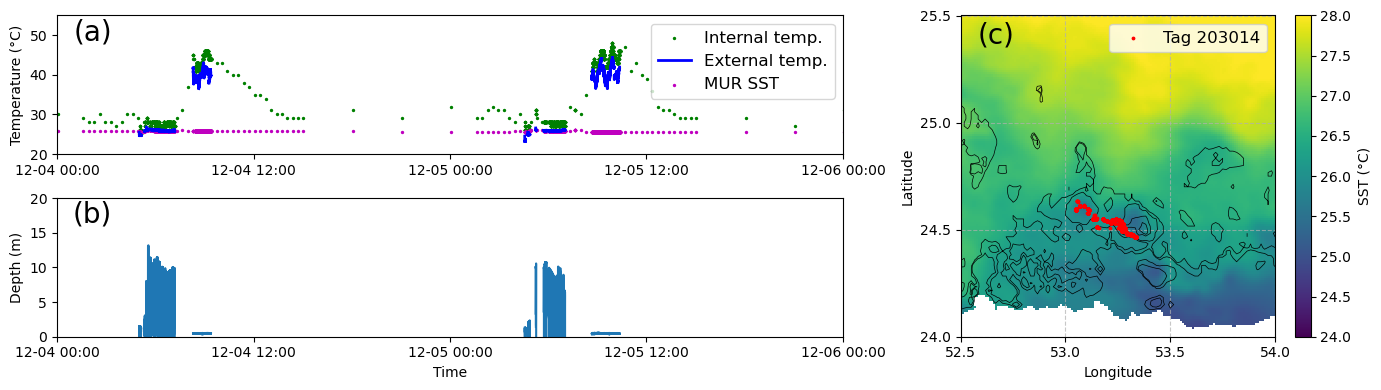

In [71]:
import matplotlib.dates as mdates

fig = plt.figure(figsize=(14,4))

gs = gridspec.GridSpec(2, 2, width_ratios=[2, 1])

# First subplot (upper half)
ax1 = fig.add_subplot(gs[0, 0])

# plt.plot(ds_obs1.where(ds_obs1.id == 203014).t,ds_obs1.where(ds_obs1.id == 203014).temp,c='b',label='temp')

# plt.plot(ds_obs1.where(ds_obs1.id == 203014).t,ds_obs1.where(ds_obs1.id == 203014).depth,label='depth')
ax1.scatter(ds_obs1.where(ds_obs1.id == 203014).t,ds_obs1.where(ds_obs1.id == 203014).temp_int,c='g',s=2,label='Internal temp.')
ax1.plot(ds_obs1.where(ds_obs1.id == 203014).t,ds_obs1.where(ds_obs1.id == 203014).temp,c='b',label='External temp.',linewidth=2)
ax1.scatter(sst_203014_sec.time,sst_203014_sec,c='m',s=2, label='MUR SST')
# plt.legend()
ax1.set_xlim([pd.Timestamp(2020, 12, 4), pd.Timestamp(2020, 12, 6)])
ax1.set_ylim([20,55])

ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(ds_obs1.where(ds_obs1.id == 203014).t,ds_obs1.where(ds_obs1.id == 203014).depth,label='depth')
ax2.set_xlim([pd.Timestamp(2020, 12, 4), pd.Timestamp(2020, 12, 6)])
ax2.set_ylim([0,20])

ax3 = fig.add_subplot(gs[:, 1])

# ax3.scatter(ds_obs1.where(ds_obs1.id == 203014).lon,ds_obs1.where(ds_obs1.id == 203014).lat,
#             c=ds_obs1.where(ds_obs1.id == 203014).temp, cmap='RdBu', s=2)
mc0 = ax3.pcolormesh(ds_mur_sec1.sel(time=pd.Timestamp(2020, 12, 4),method='nearest').lon,
             ds_mur_sec1.sel(time=pd.Timestamp(2020, 12, 4),method='nearest').lat,
             ds_mur_sec1.sel(time=pd.Timestamp(2020, 12, 4),method='nearest'),cmap='viridis',shading='auto',vmin=24,vmax=28)
            # Add coastlines and set features for map

# Add point for the location of tag id 203014
ax3.scatter(ds_obs1.where((ds_obs1.id == 203014)&(ds_obs1.time>pd.Timestamp(2020, 12, 4))&(ds_obs1.time<pd.Timestamp(2020, 12, 6))).lon, 
            ds_obs1.where((ds_obs1.id == 203014)&(ds_obs1.time>pd.Timestamp(2020, 12, 4))&(ds_obs1.time<pd.Timestamp(2020, 12, 6))).lat,
            c='r', s=3, zorder=5, label='Tag 203014')
# ax3.contour(ds_topo_etopo1.LON,ds_topo_etopo1.LAT,-ds_topo_etopo1.isel(TIME=0).B_BATHY,levels=[10, 5],colors='k',linewidths=0.5)
# Add contour labels for bathymetry
c = ax3.contour(ds_topo_etopo1.LON,ds_topo_etopo1.LAT,-ds_topo_etopo1.isel(TIME=0).B_BATHY,levels=[5,10],colors='k',linewidths=0.5)
ax3.clabel(c, inline=True, fontsize=8, fmt='%d m')

ax3.legend(loc='upper right', fontsize=12)
plt.colorbar(mappable=mc0, label='SST (°C)')
# ax3.set_xlim(47,58)
# ax3.set_ylim(22,33)
ax3.set_xlim(52.5,54)
ax3.set_ylim(24,25.5)
# Set more detailed gridlines for the map
ax3.set_xticks(np.arange(52.5, 54.1, 0.5))
ax3.set_yticks(np.arange(24, 25.6, 0.5))
ax3.grid(True, linestyle='--', alpha=0.7)

# Format x-axis to show dates in MM-DD HH:mm format
date_format = mdates.DateFormatter('%m-%d %H:%M')
ax1.xaxis.set_major_formatter(date_format)
ax2.xaxis.set_major_formatter(date_format)

# Set appropriate time intervals for x-axis
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=12))
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=12))

# Rotate x-axis labels for better readability
# plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')
# plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

# Add labels and titles
ax1.set_ylabel('Temperature (°C)')
ax2.set_ylabel('Depth (m)')
ax2.set_xlabel('Time')
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')

ax1.text(0.07, 0.98, '(a)', transform=ax1.transAxes, fontsize=20, va='top', ha='right')
ax2.text(0.07, 0.98, '(b)', transform=ax2.transAxes, fontsize=20, va='top', ha='right')
ax3.text(0.17, 0.98, '(c)', transform=ax3.transAxes, fontsize=20, va='top', ha='right')
# ax1.set_title('Temperature and Internal Temperature')
# ax2.set_title('Diving Depth')
# ax3.set_title('Location and SST')

ax1.legend(loc='upper right', fontsize=12)
plt.tight_layout()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


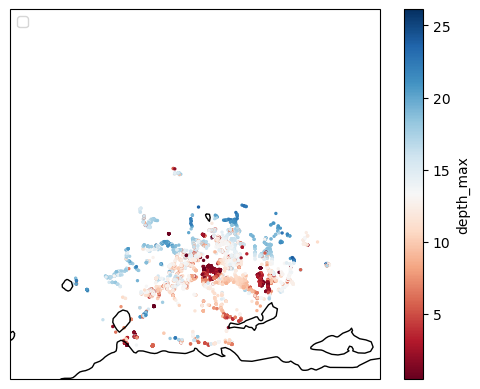

In [ ]:
### OLD version
ax = plt.axes(projection=ccrs.PlateCarree())
# plt.plot(ds_obs.lon,ds_obs.lat,'o')

plt.scatter(ds_dive_2_filtered.where(ds_dive_2_filtered.tag_id == 203014).lon,ds_dive_2_filtered.where(ds_dive_2_filtered.tag_id == 203014).lat,
            c=ds_dive_2_filtered.where(ds_dive_2_filtered.tag_id == 203014).depth_max, cmap='RdBu', s=2)
plt.colorbar(label='depth_max')
ax.coastlines()
ax.set_xlim(52,54)
ax.set_ylim(24,26)

# ax.set_xticks(np.arange(47,58,2), crs=ccrs.PlateCarree())
# ax.set_yticks(np.arange(22,33,2), crs=ccrs.PlateCarree())
ax.legend(loc = "upper left")
plt.show()

## interpolate the data

In [52]:
ds_mur_sec1=ds_mur.sst.sel(time=slice(ds_dive_1_filtered.time.min(),ds_dive_1_filtered.time.max()),lon=slice(47,58),lat=slice(22,33))
ds_mur_sec2=ds_mur.sst.sel(time=slice(ds_dive_2_filtered.time.min(),ds_dive_2_filtered.time.max()),lon=slice(47,58),lat=slice(22,33))
ds_mur_sec3=ds_mur.sst.sel(time=slice(ds_dive_3_filtered.time.min(),ds_dive_3_filtered.time.max()),lon=slice(47,58),lat=slice(22,33))
ds_mur_sec4=ds_mur.sst.sel(time=slice(ds_dive_4_filtered.time.min(),ds_dive_4_filtered.time.max()),lon=slice(47,58),lat=slice(22,33))

In [53]:
ds_dive_1_filtered

<xarray.Dataset>
Dimensions:       (dive_index: 53776)
Coordinates:
  * dive_index    (dive_index) float64 0.0 1.0 2.0 3.0 ... 960.0 961.0 962.0
Data variables:
    tag_id        (dive_index) float64 2.014e+05 2.014e+05 ... 2.03e+05 2.03e+05
    temp1         (dive_index) float64 29.1 29.07 29.08 ... 24.9 24.88 24.87
    temp0         (dive_index) float64 29.02 29.15 29.06 ... 24.89 24.66 24.88
    temp_int1     (dive_index) float64 31.0 31.0 31.0 31.0 ... 26.0 25.0 26.0
    temp_int0     (dive_index) float64 30.0 31.0 31.0 31.0 ... 26.0 26.0 25.0
    rec_len       (dive_index) float64 39.0 52.0 36.0 39.0 ... 35.0 61.0 36.0
    first_record  (dive_index) float64 5.509e+04 5.514e+04 ... 6.219e+04
    last_record   (dive_index) float64 5.513e+04 5.519e+04 ... 6.222e+04
    depth_max     (dive_index) float64 13.68 13.69 13.73 ... 16.72 16.01 16.04
    lon           (dive_index) float64 53.15 53.15 53.15 ... 53.26 53.27 53.27
    lat           (dive_index) float64 24.68 24.68 24.68 ... 24.7 24.69 24.69
    time          (dive_index) datetime64[ns] 2020-11-14T06:28:34 ... 2020-12...

In [54]:
# fmm2=ds_mur_sec1.interp(lon=ds_dive_2_filtered.lon,lat=ds_dive_2_filtered.lat,time=ds_dive_2_filtered.time) #original
fmm1=ds_mur_sec1.interp(lon=ds_dive_1_filtered.lon,lat=ds_dive_1_filtered.lat,time=ds_dive_1_filtered.time) #original
fmm2=ds_mur_sec2.interp(lon=ds_dive_2_filtered.lon,lat=ds_dive_2_filtered.lat,time=ds_dive_2_filtered.time) #original
fmm3=ds_mur_sec3.interp(lon=ds_dive_3_filtered.lon,lat=ds_dive_3_filtered.lat,time=ds_dive_3_filtered.time) #original
fmm4=ds_mur_sec4.interp(lon=ds_dive_4_filtered.lon,lat=ds_dive_4_filtered.lat,time=ds_dive_4_filtered.time) #original
# fmm2_0=ds_mur_sec1.interp(lon=ds_dive_2.lon,lat=ds_dive_2.lat,time=ds_dive_2.time) #original

# Combine fmm1, fmm2, fmm3, fmm4 into a single xarray
fmm_combined = xr.concat([fmm1, fmm2, fmm3, fmm4], dim='dive_index')

# Combine ds_mur_sec1, ds_mur_sec2, ds_mur_sec3, ds_mur_sec4 into a single xarray
ds_dive_filtered_combined = xr.concat([ds_dive_1_filtered, ds_dive_2_filtered, ds_dive_3_filtered, ds_dive_4_filtered], dim='dive_index')

## filter out the bad data / Initial tempeture

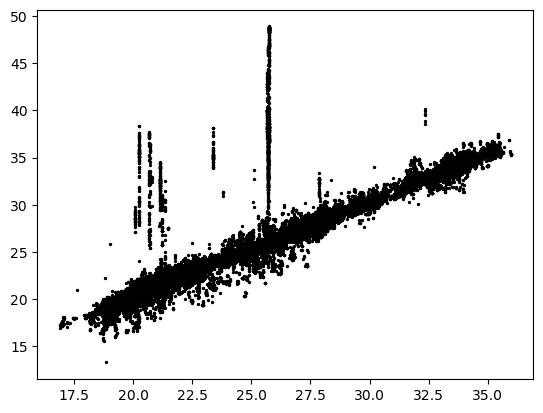

In [249]:
hcut = 0

fmm_combined_dn = fmm_combined.where((~np.isnan(ds_dive_filtered_combined.temp1))&(np.abs(ds_dive_filtered_combined.temp0-ds_dive_filtered_combined.temp1)<=hcut),drop=True).values
ds_dive_filtered_combined_dn = ds_dive_filtered_combined.where((~np.isnan(ds_dive_filtered_combined.temp1))&(np.abs(ds_dive_filtered_combined.temp0-ds_dive_filtered_combined.temp1)<=hcut),drop=True).temp1.values

fmm_combined_dn2 = fmm_combined_dn[~np.isnan(fmm_combined_dn)]
ds_dive_filtered_combined_dn2 = ds_dive_filtered_combined_dn[~np.isnan(fmm_combined_dn)]

plt.scatter(fmm_combined_dn2,ds_dive_filtered_combined_dn2,c='k',s=2)

10.0
0.9762547540909404
1.1617564748442735
9.5
0.9762547540909404
1.1617564748442735
9.0
0.9762547540909404
1.1617564748442735
8.5
0.9762549257610628
1.1617541665683826
8.0
0.9762549253068015
1.161755275843623
7.5
0.9762569977164375
1.1617087524428158
7.0
0.9762605248595209
1.1616313488652548
6.5
0.9762605248595209
1.1616313488652548
6.0
0.9762622106623533
1.161592927161007
5.5
0.9762625780141506
1.161586634855292
5.0
0.9762680343869315
1.161468665463497
4.5
0.9762746558975038
1.16132927340653
4.0
0.976279773083095
1.1612284971683986
3.5
0.9762864558099751
1.1610832573970271
3.0
0.9763022619555027
1.1607235520425507
2.5
0.9763420358236232
1.1598403662530428
2.0
0.9763866757708685
1.1588606839518865
1.5
0.9764647515781247
1.157148514584273
1.0
0.9765636588802081
1.155065037980607
0.5
0.9767140131629845
1.1516192847118492


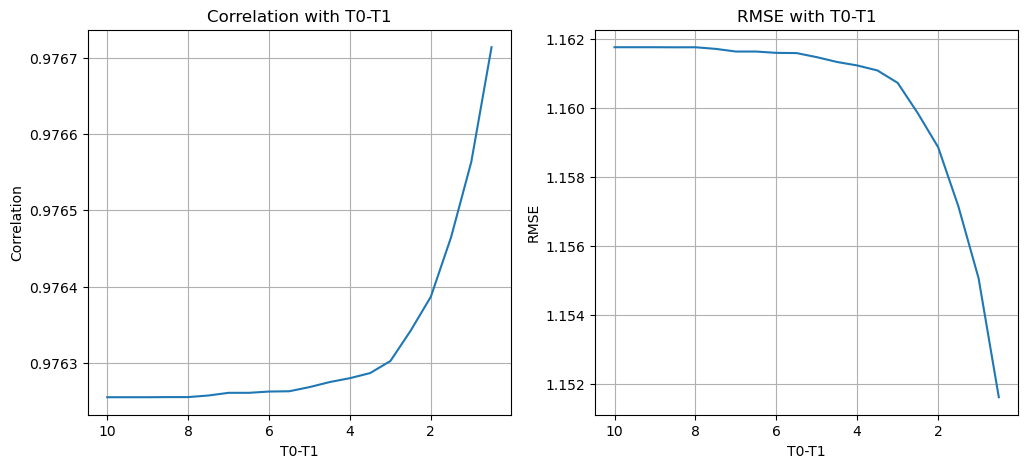

In [78]:
## calculate correlation
corr_with_t0=[]
rmse_with_t0=[]
# for hcut in np.arange(0,0.4,0.01):
for hcut in np.arange(10,0,-0.5):

    fmm_combined_dn = fmm_combined.where((~np.isnan(ds_dive_filtered_combined.temp1))&(np.abs(ds_dive_filtered_combined.temp0-ds_dive_filtered_combined.temp1)<=hcut),drop=True).values
    ds_dive_filtered_combined_dn = ds_dive_filtered_combined.where((~np.isnan(ds_dive_filtered_combined.temp1))&(np.abs(ds_dive_filtered_combined.temp0-ds_dive_filtered_combined.temp1)<=hcut),drop=True).temp1.values

    fmm_combined_dn2 = fmm_combined_dn[~np.isnan(fmm_combined_dn)]
    ds_dive_filtered_combined_dn2 = ds_dive_filtered_combined_dn[~np.isnan(fmm_combined_dn)]
    print(hcut)
    print(np.corrcoef(fmm_combined_dn2,ds_dive_filtered_combined_dn2)[1,0])
    print(np.sqrt(np.mean((fmm_combined_dn2-ds_dive_filtered_combined_dn2)**2)))
    corr_with_t0.append(np.corrcoef(fmm_combined_dn2,ds_dive_filtered_combined_dn2)[1,0])
    rmse_with_t0.append(np.sqrt(np.mean((fmm_combined_dn2-ds_dive_filtered_combined_dn2)**2)))
    # plt.figure(figsize=(6,5))
    # plt.scatter(fmm_combined,ds_dive_filtered_combined.temp1,c='k',s=2)
    # plt.scatter(fmm_combined_dn2,ds_dive_filtered_combined_dn2,c='r',s=2)
    # plt.plot([18,37],[18,37])
    # plt.title(f'T0-T1 = {hcut} Correlation: {np.corrcoef(fmm_combined_dn2,ds_dive_filtered_combined_dn2)[1,0]:.2f} - RMSE: {np.sqrt(np.mean((fmm_combined_dn2-ds_dive_filtered_combined_dn2)**2)):.2f}')

plt.subplots(1,2,figsize=(12,5))
plt.subplot(121)
plt.plot(np.arange(10,0,-0.5),corr_with_t0)
# plt.plot(corr_with_t0)
plt.title('Correlation with T0-T1')
plt.xlabel('T0-T1')
plt.gca().invert_xaxis()
plt.ylabel('Correlation')
plt.grid()
plt.subplot(122)
plt.plot(np.arange(10,0,-0.5),rmse_with_t0)
# plt.plot(rmse_with_t0)
plt.title('RMSE with T0-T1')
plt.xlabel('T0-T1')
plt.gca().invert_xaxis()
plt.ylabel('RMSE')
plt.grid()

## filter out the bad data / record length

/tmp/ipykernel_174340/1227260836.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  plt.scatter(fmm_combined,ds_dive_filtered_combined.where(ds_dive_filtered_combined.rec_len<10).temp1,c='r',cmap='RdBu_r',s=2,vmax=50,vmin=0)
/tmp/ipykernel_174340/1227260836.py:8: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  plt.scatter(fmm_combined,ds_dive_filtered_combined.where(ds_dive_filtered_combined.rec_len>20).temp1,c='k',cmap='RdBu_r',s=2,vmax=50,vmin=0)


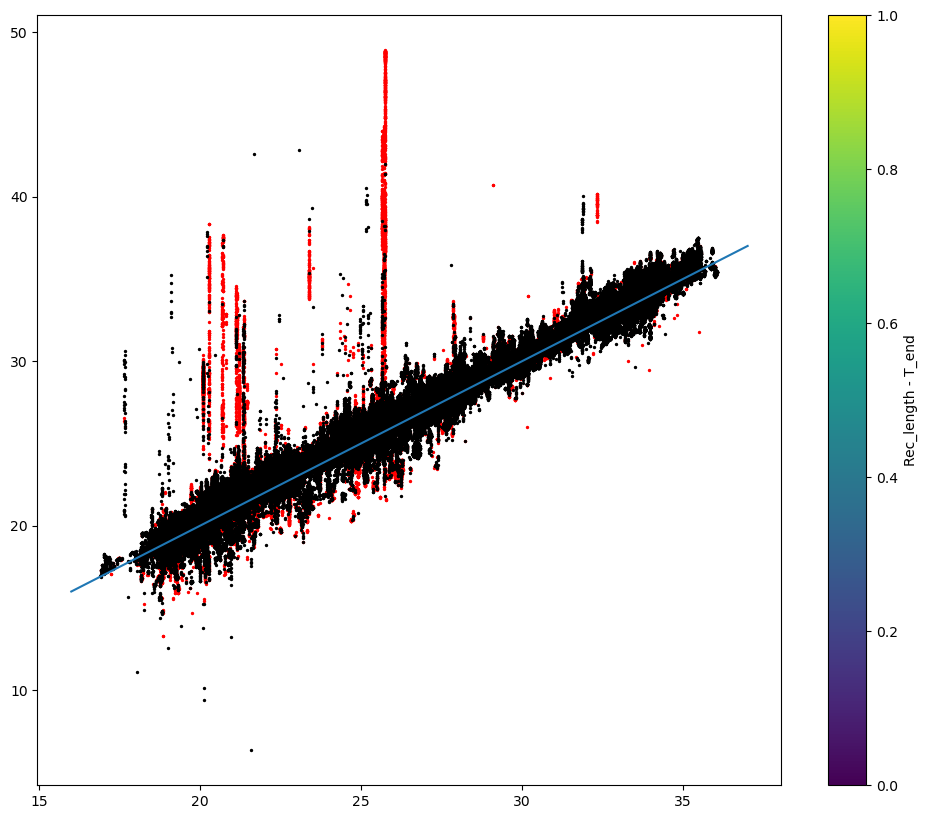

In [72]:
plt.figure(figsize=(12,10))

# plt.scatter(fmm2,ds_dive_2.where(ds_dive_2.dive_index>25000).temp1,c=ds_dive_2.temp0-ds_dive_2.temp1,cmap='RdBu',s=2,vmax=1,vmin=-1)
# plt.scatter(fmm2,ds_dive_2.where(ds_dive_2.dive_index<5000).temp1,c=ds_dive_2.temp0-ds_dive_2.temp1,cmap='RdBu',s=2,vmax=1,vmin=-1)
# plt.scatter(fmm2_0,ds_dive_2.where(ds_dive_2.temp1<50).temp1,c='k',cmap='RdBu',s=2,vmax=1,vmin=-1)
# plt.scatter(fmm_combined,ds_dive_filtered_combined.temp1,c=ds_dive_filtered_combined.rec_len,cmap='RdBu_r',s=2,vmax=50,vmin=0)
plt.scatter(fmm_combined,ds_dive_filtered_combined.where(ds_dive_filtered_combined.rec_len<10).temp1,c='r',cmap='RdBu_r',s=2,vmax=50,vmin=0)
plt.scatter(fmm_combined,ds_dive_filtered_combined.where(ds_dive_filtered_combined.rec_len>20).temp1,c='k',cmap='RdBu_r',s=2,vmax=50,vmin=0)
# plt.scatter(fmm2,ds_dive_2.temp0,c='r',cmap='RdBu',s=2,vmax=1,vmin=-1)

# plt.xlim([18, 37]),plt.ylim([18, 37])
plt.plot([16,37],[16,37])
plt.colorbar(label='Rec_length - T_end')

0.0
0.9762484696115249
1.1618849717506579
2.5
0.9846624457750779
0.9557065716714027
5.0
0.9872905019399068
0.8830359789108129
7.5
0.9880600398214281
0.861099160813839
10.0
0.9889363469083489
0.8367178532276484
12.5
0.9894586460270165
0.8236492333477023
15.0
0.9902489484313133
0.8054437858892627
17.5
0.9907957575195332
0.7934115949555615
20.0
0.9914902780811059
0.7784486891544914
22.5
0.9918461439943962
0.7707255460674444
25.0
0.99224058155429
0.7623759658968545
27.5
0.9924273020857118
0.759430465483129
30.0
0.992530273348824
0.7591201696085145
32.5
0.9925335691455208
0.760433982147906
35.0
0.9923711198740438
0.7671182637001163
37.5
0.9922452713948932
0.7738111629269011
40.0
0.9916738407839035
0.7996454547784848
42.5
0.991204720645162
0.8217962036507398
45.0
0.9899172617959794
0.877246426285675
47.5
0.9888354921751801
0.9234239448866117


/tmp/ipykernel_174340/491653028.py:22: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.subplots(1,2,figsize=(12,5))


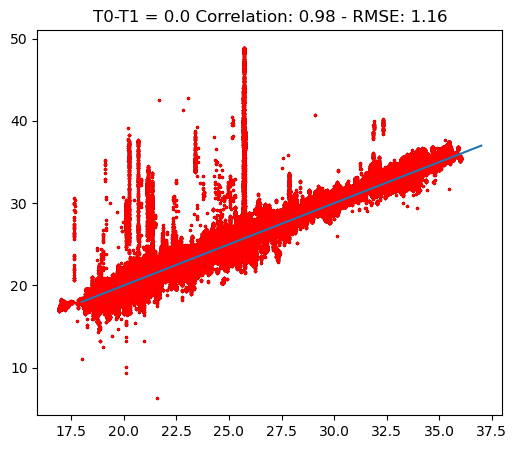

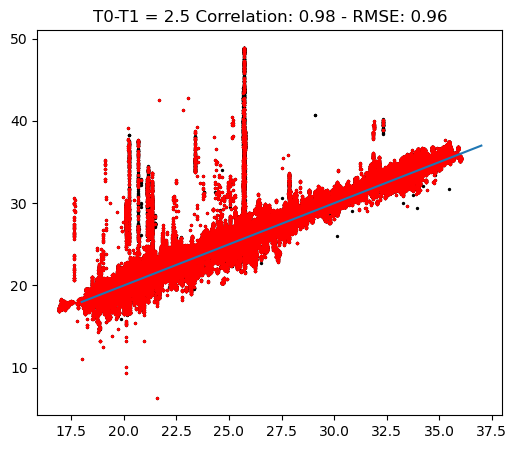

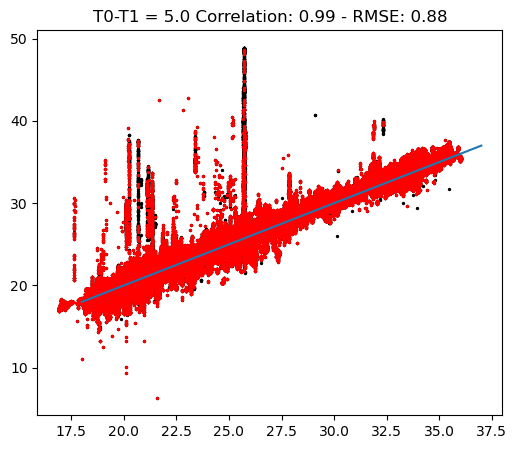

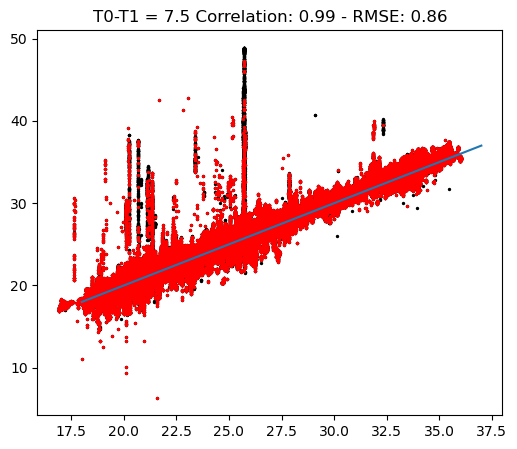

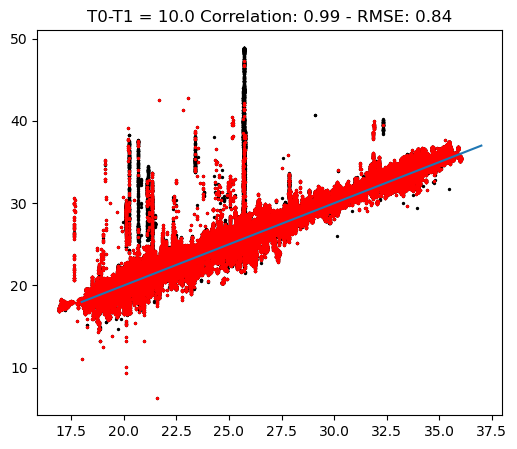

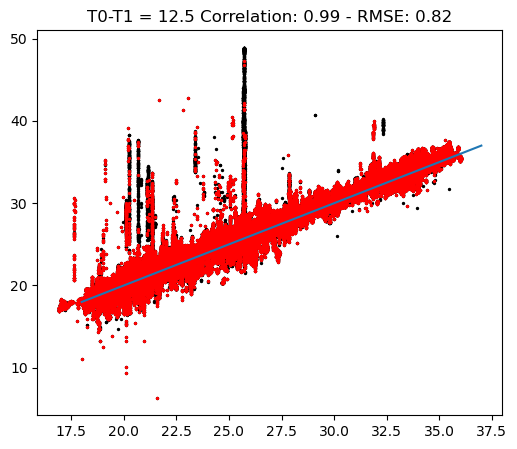

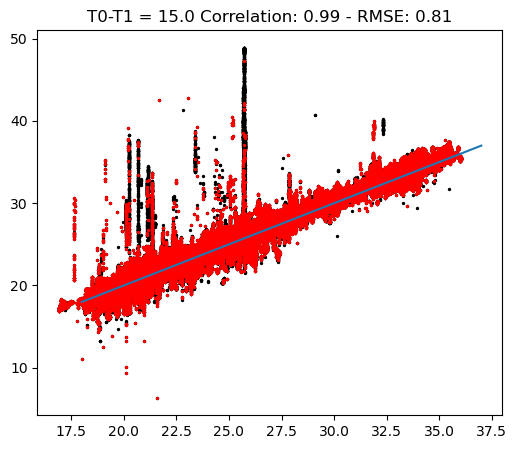

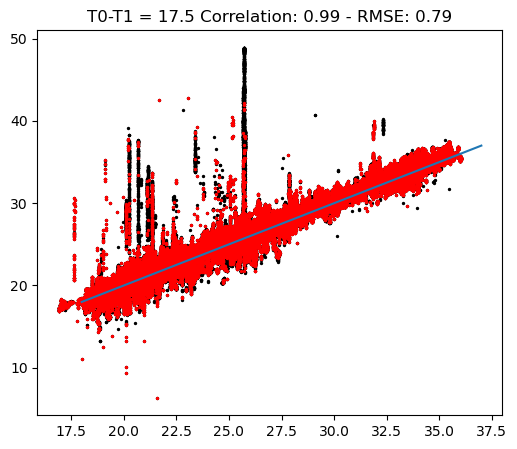

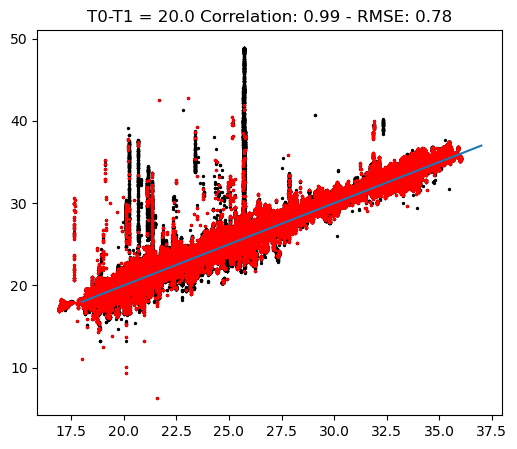

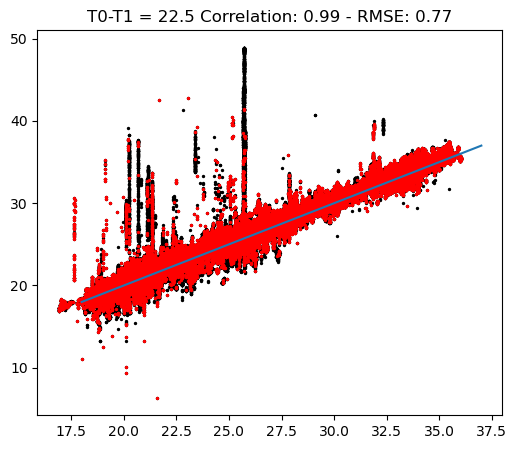

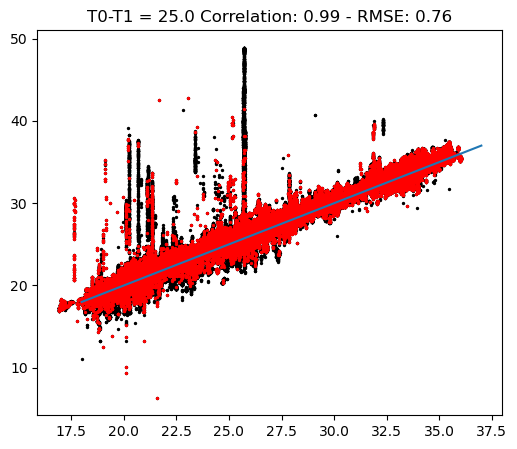

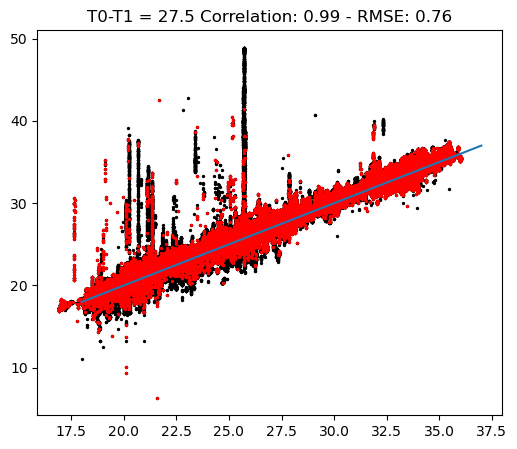

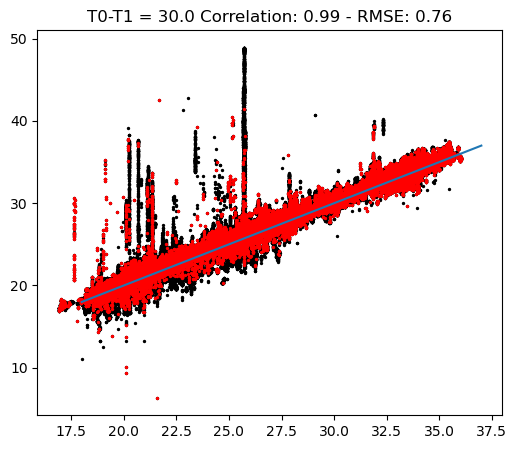

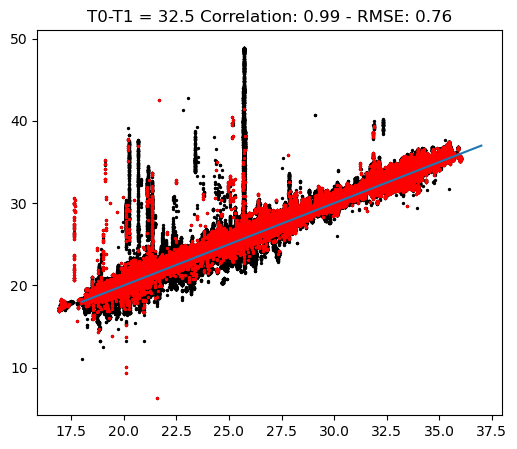

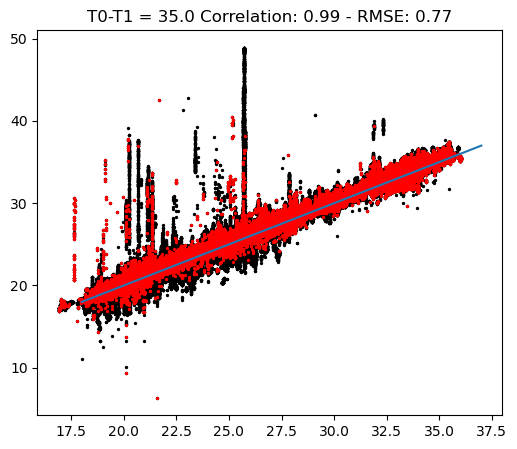

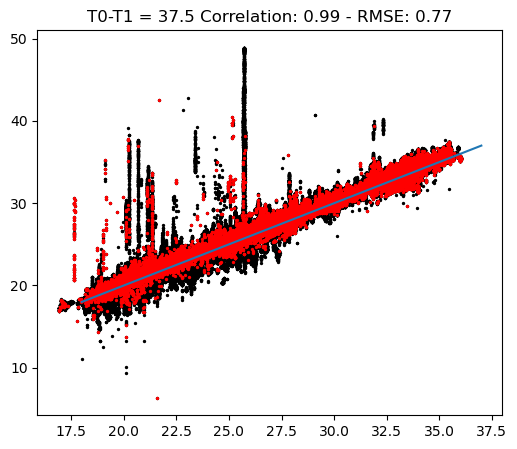

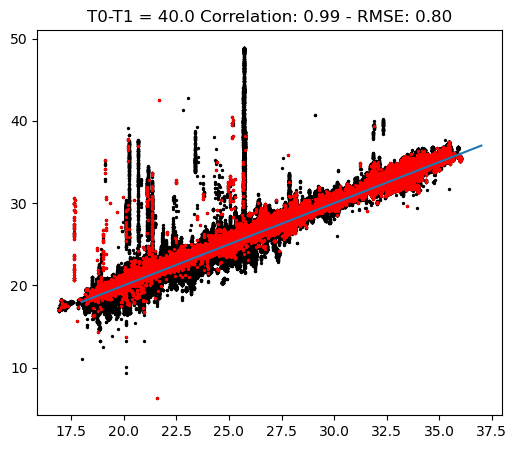

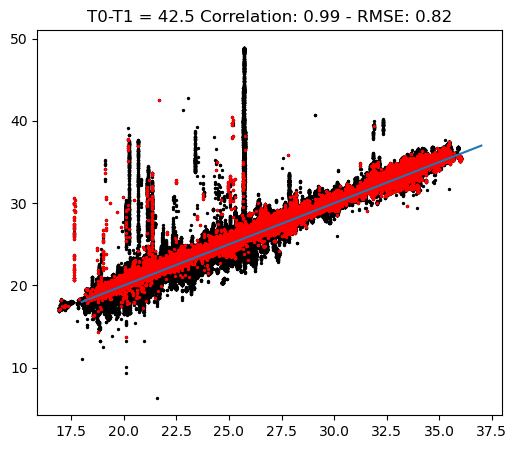

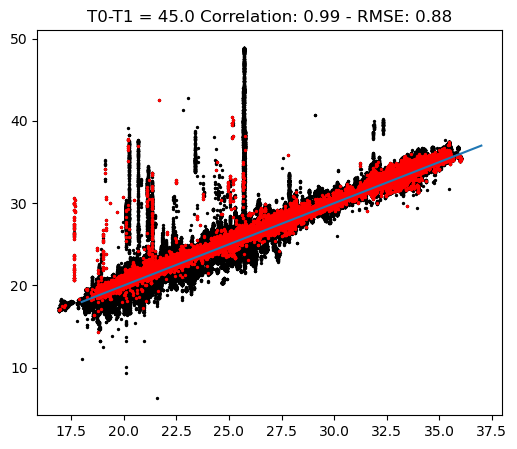

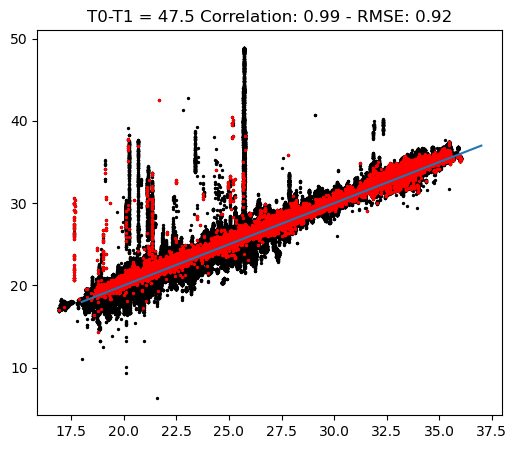

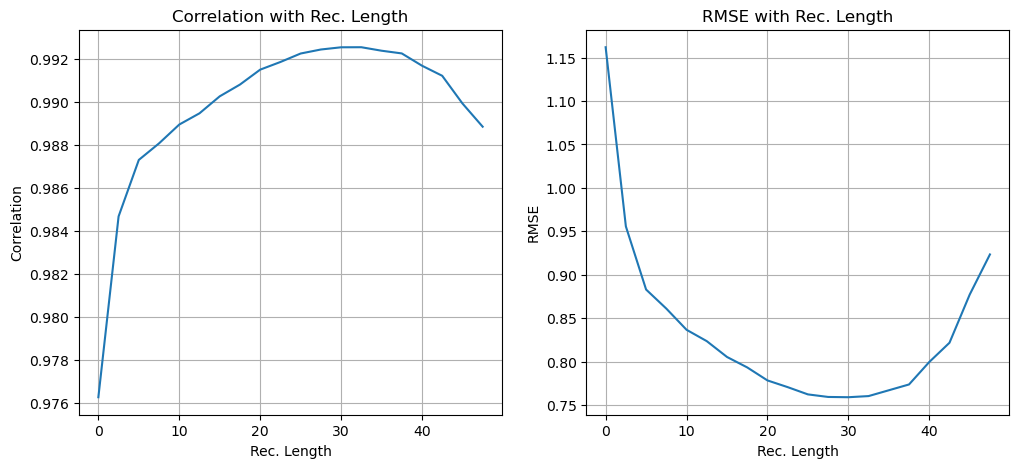

In [73]:
## calculate correlation
corr_with_reclen=[]
rmse_with_reclen=[]
for hcut in np.arange(0,50,2.5):

    fmm_combined_dn = fmm_combined.where((~np.isnan(ds_dive_filtered_combined.temp1))&(ds_dive_filtered_combined.rec_len>hcut),drop=True).values
    ds_dive_filtered_combined_dn = ds_dive_filtered_combined.where((~np.isnan(ds_dive_filtered_combined.temp1))&(ds_dive_filtered_combined.rec_len>hcut),drop=True).temp1.values

    fmm_combined_dn2 = fmm_combined_dn[~np.isnan(fmm_combined_dn)]
    ds_dive_filtered_combined_dn2 = ds_dive_filtered_combined_dn[~np.isnan(fmm_combined_dn)]
    print(hcut)
    print(np.corrcoef(fmm_combined_dn2,ds_dive_filtered_combined_dn2)[1,0])
    print(np.sqrt(np.mean((fmm_combined_dn2-ds_dive_filtered_combined_dn2)**2)))
    corr_with_reclen.append(np.corrcoef(fmm_combined_dn2,ds_dive_filtered_combined_dn2)[1,0])
    rmse_with_reclen.append(np.sqrt(np.mean((fmm_combined_dn2-ds_dive_filtered_combined_dn2)**2)))
    plt.figure(figsize=(6,5))
    plt.scatter(fmm_combined,ds_dive_filtered_combined.temp1,c='k',s=2)
    plt.scatter(fmm_combined_dn2,ds_dive_filtered_combined_dn2,c='r',s=2)
    plt.plot([18,37],[18,37])
    plt.title(f'T0-T1 = {hcut} Correlation: {np.corrcoef(fmm_combined_dn2,ds_dive_filtered_combined_dn2)[1,0]:.2f} - RMSE: {np.sqrt(np.mean((fmm_combined_dn2-ds_dive_filtered_combined_dn2)**2)):.2f}')

plt.subplots(1,2,figsize=(12,5))
plt.subplot(121)
plt.plot(np.arange(0,50,2.5),corr_with_reclen)
plt.title('Correlation with Rec. Length')
plt.xlabel('Rec. Length')
plt.ylabel('Correlation')
plt.grid()
plt.subplot(122)
plt.plot(np.arange(0,50,2.5),rmse_with_reclen)
plt.title('RMSE with Rec. Length')
plt.xlabel('Rec. Length')
plt.ylabel('RMSE')
plt.grid()

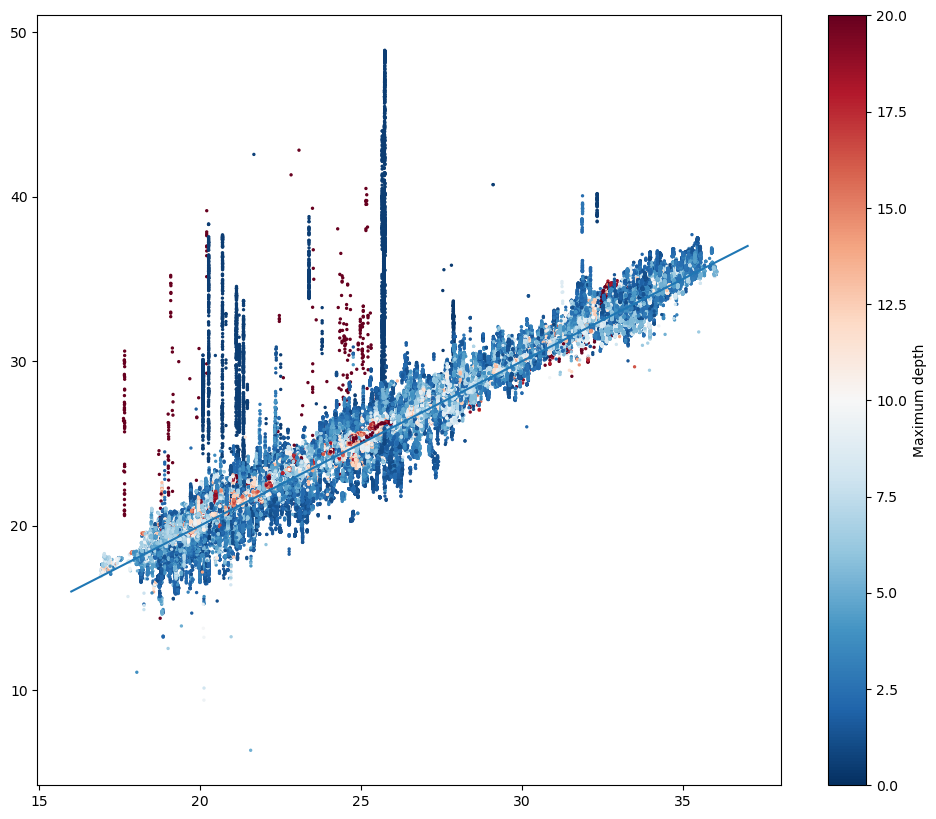

In [74]:
plt.figure(figsize=(12,10))

# plt.scatter(fmm2,ds_dive_2.where(ds_dive_2.dive_index>25000).temp1,c=ds_dive_2.temp0-ds_dive_2.temp1,cmap='RdBu',s=2,vmax=1,vmin=-1)
# plt.scatter(fmm2,ds_dive_2.where(ds_dive_2.dive_index<5000).temp1,c=ds_dive_2.temp0-ds_dive_2.temp1,cmap='RdBu',s=2,vmax=1,vmin=-1)
# plt.scatter(fmm2_0,ds_dive_2.where(ds_dive_2.temp1<50).temp1,c='k',cmap='RdBu',s=2,vmax=1,vmin=-1)
plt.scatter(fmm_combined,ds_dive_filtered_combined.temp1,c=ds_dive_filtered_combined.depth_max,cmap='RdBu_r',s=2,vmax=20,vmin=0)
# plt.scatter(fmm2,ds_dive_2_filtered.temp1,c=ds_dive_2_filtered.depth_max,cmap='RdBu_r',s=2,vmax=20,vmin=0)
# plt.scatter(fmm3,ds_dive_3_filtered.temp1,c=ds_dive_3_filtered.depth_max,cmap='RdBu_r',s=2,vmax=20,vmin=0)
# plt.scatter(fmm4,ds_dive_4_filtered.temp1,c=ds_dive_4_filtered.depth_max,cmap='RdBu_r',s=2,vmax=20,vmin=0)
# plt.scatter(fmm2,ds_dive_2.temp0,c='r',cmap='RdBu',s=2,vmax=1,vmin=-1)

# plt.xlim([18, 37]),plt.ylim([18, 37])
plt.plot([16,37],[16,37])
plt.colorbar(label='Maximum depth')

0.0
0.9762484696115249
1.1618849717506579
0.5
0.9808250112689915
1.053108974200857
1.0
0.9894290366200976
0.8130069863065507
1.5
0.9905697232828456
0.7874090830861257
2.0
0.991655586964405
0.7608040761920785
2.5
0.9923604150636018
0.7396311210585557
3.0
0.9925496332696808
0.7289197095312476
3.5
0.992770348437949
0.7179580429260585
4.0
0.9931332491116084
0.7047117511385205
4.5
0.9932684397220612
0.6963987183219058
5.0
0.9932750598530911
0.6929890087014965
5.5
0.9932830763129936
0.6892826972556217
6.0
0.9931930923700694
0.6892250052435336
6.5
0.9928074463185637
0.6938907701938549
7.0
0.9924852779409624
0.6986073527948589
7.5
0.992083918578266
0.7061540027377962
8.0
0.9917426484695354
0.7126483309511831
8.5
0.9915088902713959
0.7154611627454499
9.0
0.9910420960634266
0.7245115806174034
9.5
0.9904010964539062
0.7376598307635238


/tmp/ipykernel_174340/793204043.py:22: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.subplots(1,2,figsize=(12,5))


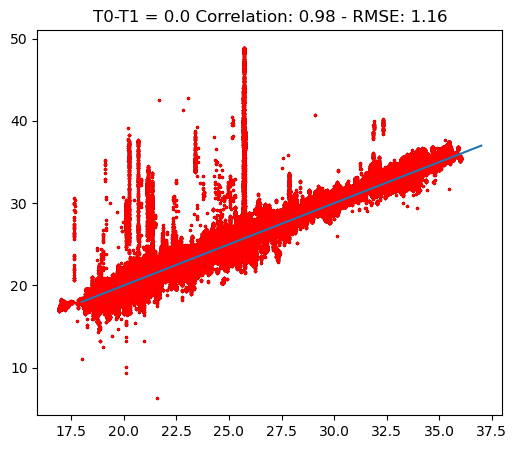

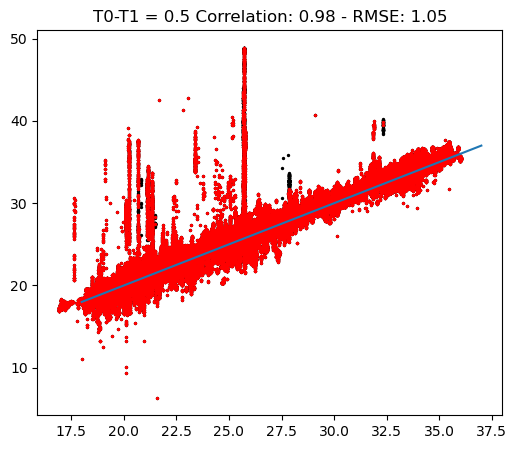

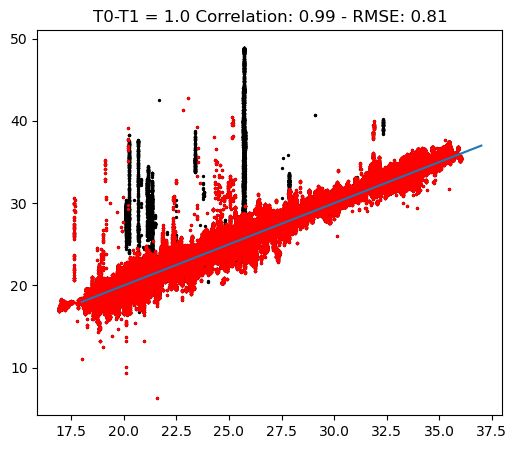

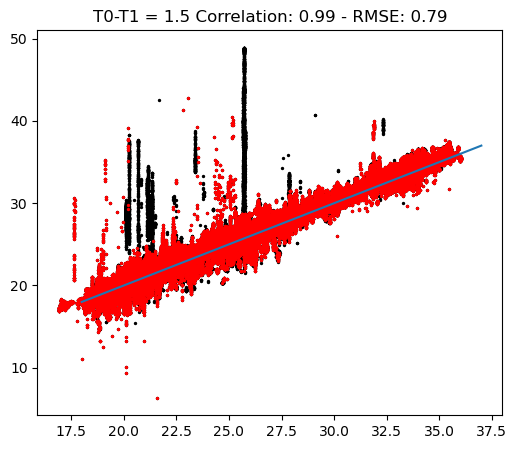

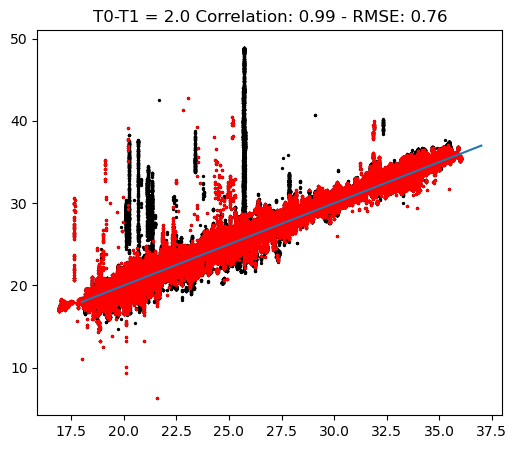

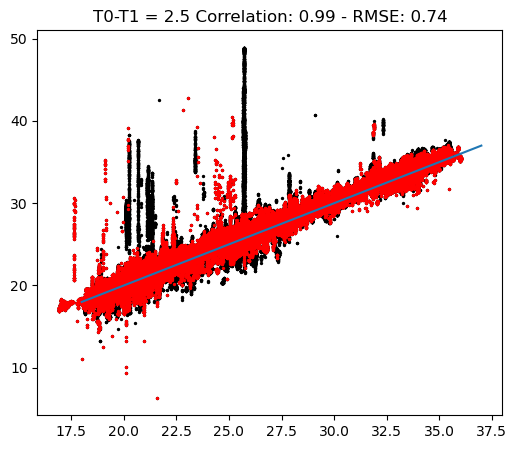

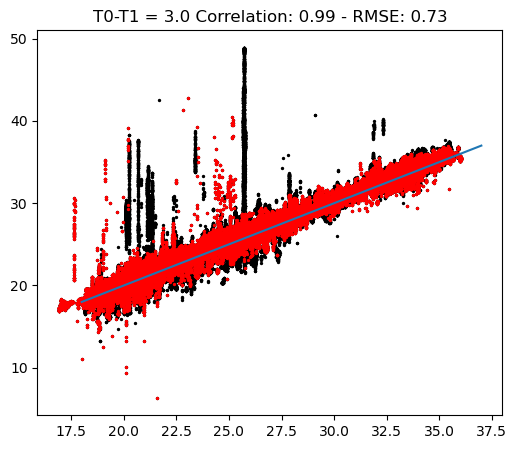

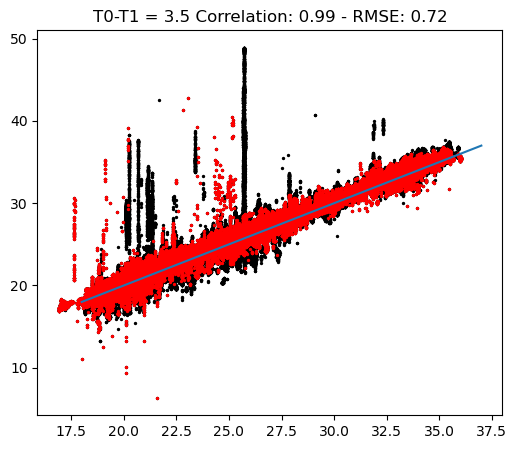

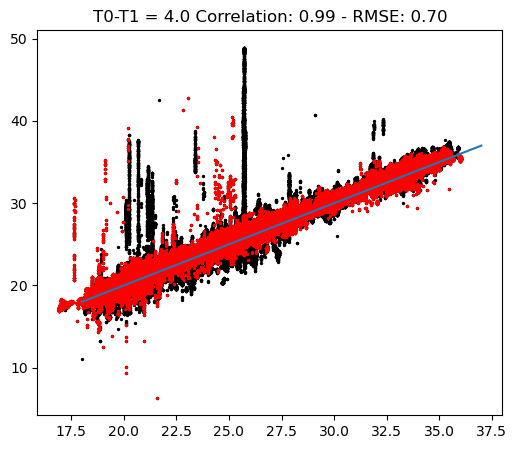

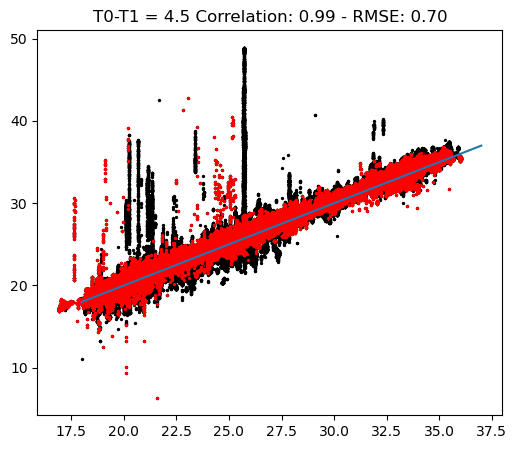

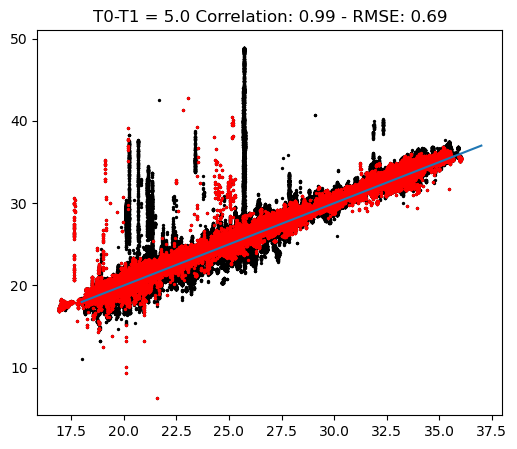

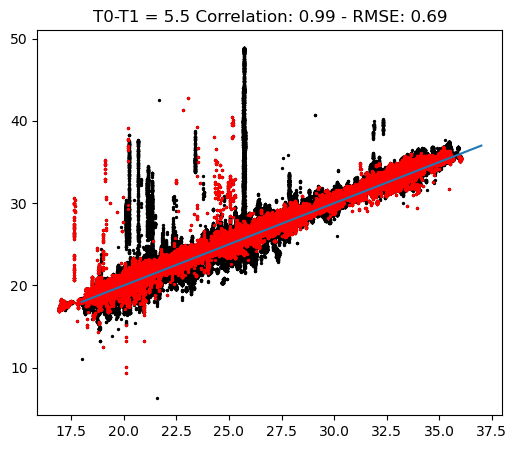

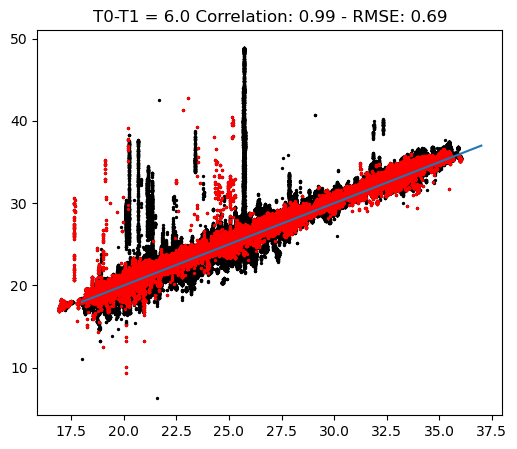

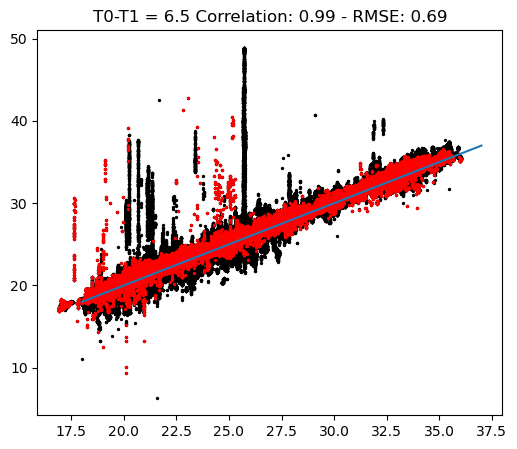

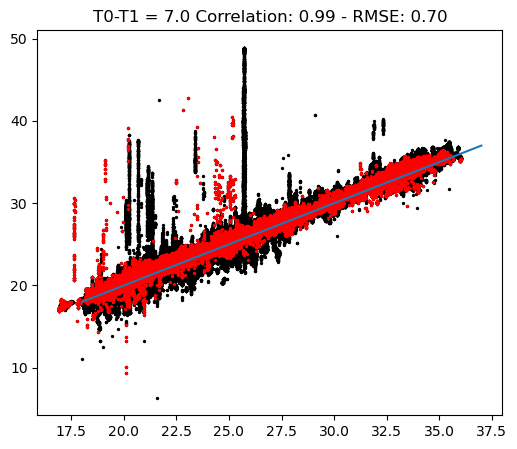

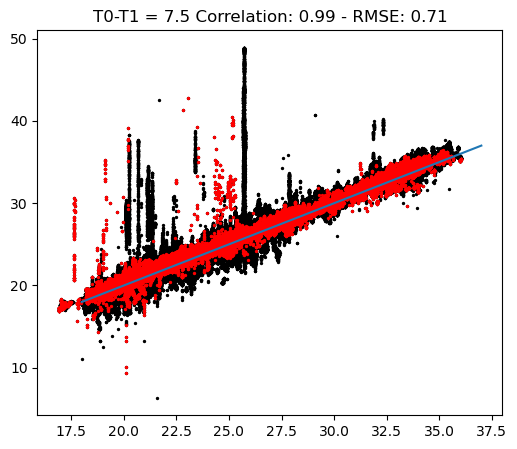

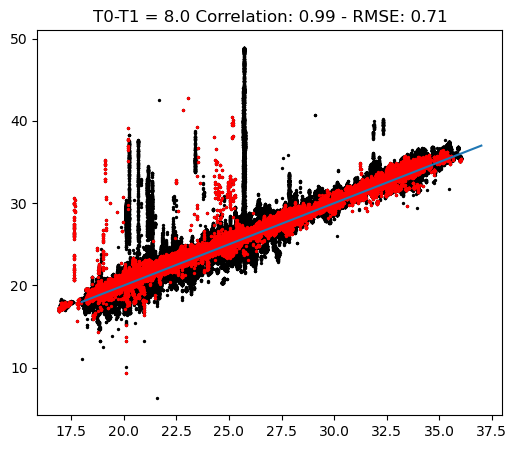

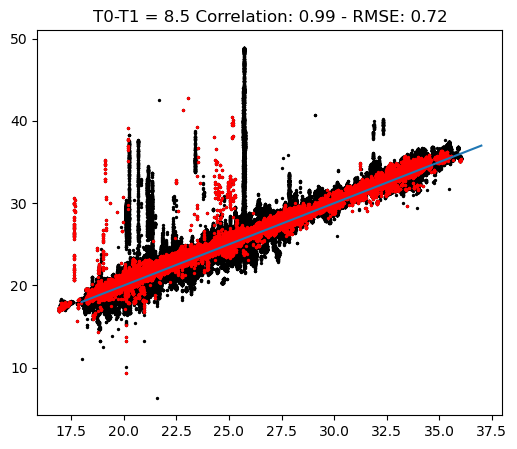

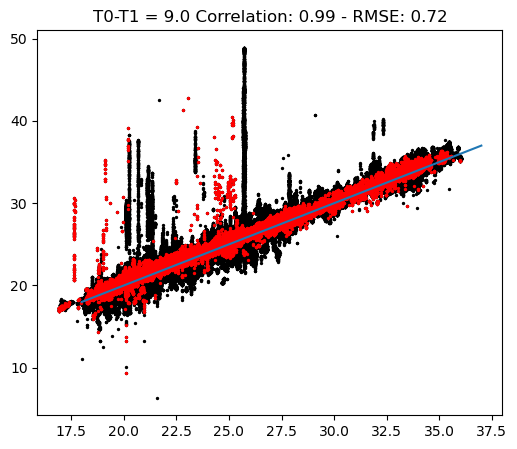

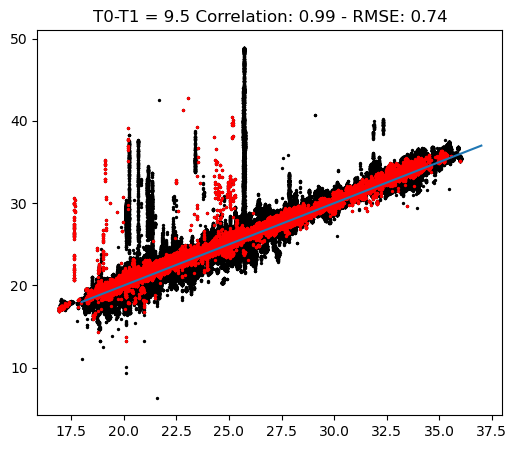

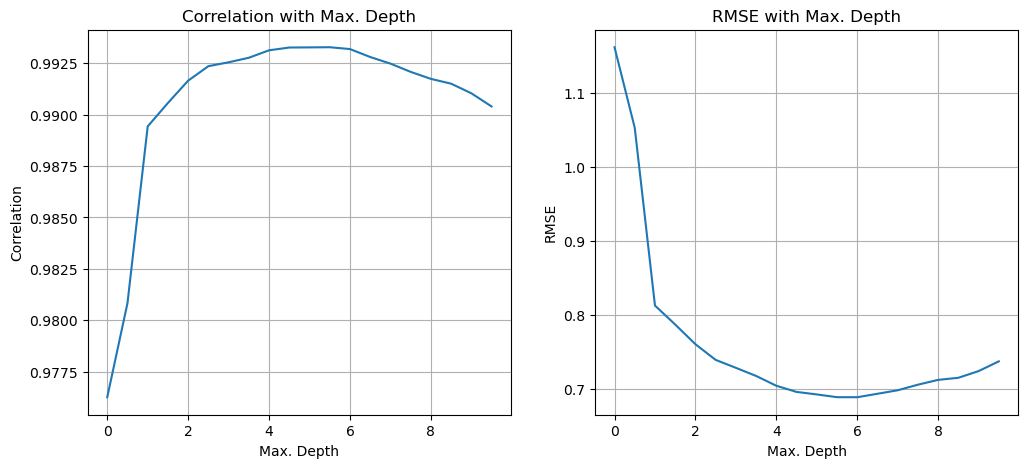

In [75]:
## calculate correlation
corr_with_maxdep=[]
rmse_with_maxdep=[]
for hcut in np.arange(0,10,0.5):

    fmm_combined_dn = fmm_combined.where((~np.isnan(ds_dive_filtered_combined.temp1))&(ds_dive_filtered_combined.depth_max>hcut),drop=True).values
    ds_dive_filtered_combined_dn = ds_dive_filtered_combined.where((~np.isnan(ds_dive_filtered_combined.temp1))&(ds_dive_filtered_combined.depth_max>hcut),drop=True).temp1.values

    fmm_combined_dn2 = fmm_combined_dn[~np.isnan(fmm_combined_dn)]
    ds_dive_filtered_combined_dn2 = ds_dive_filtered_combined_dn[~np.isnan(fmm_combined_dn)]
    print(hcut)
    print(np.corrcoef(fmm_combined_dn2,ds_dive_filtered_combined_dn2)[1,0])
    print(np.sqrt(np.mean((fmm_combined_dn2-ds_dive_filtered_combined_dn2)**2)))
    corr_with_maxdep.append(np.corrcoef(fmm_combined_dn2,ds_dive_filtered_combined_dn2)[1,0])
    rmse_with_maxdep.append(np.sqrt(np.mean((fmm_combined_dn2-ds_dive_filtered_combined_dn2)**2)))
    plt.figure(figsize=(6,5))
    plt.scatter(fmm_combined,ds_dive_filtered_combined.temp1,c='k',s=2)
    plt.scatter(fmm_combined_dn2,ds_dive_filtered_combined_dn2,c='r',s=2)
    plt.plot([18,37],[18,37])
    plt.title(f'T0-T1 = {hcut} Correlation: {np.corrcoef(fmm_combined_dn2,ds_dive_filtered_combined_dn2)[1,0]:.2f} - RMSE: {np.sqrt(np.mean((fmm_combined_dn2-ds_dive_filtered_combined_dn2)**2)):.2f}')

plt.subplots(1,2,figsize=(12,5))
plt.subplot(121)
plt.plot(np.arange(0,10,0.5),corr_with_maxdep)
plt.title('Correlation with Max. Depth')
plt.xlabel('Max. Depth')
plt.ylabel('Correlation')
plt.grid()
plt.subplot(122)
plt.plot(np.arange(0,10,0.5),rmse_with_maxdep)
plt.title('RMSE with Max. Depth')
plt.xlabel('Max. Depth')
plt.ylabel('RMSE')
plt.grid()

Text(0.1, 0.96, '(c)')

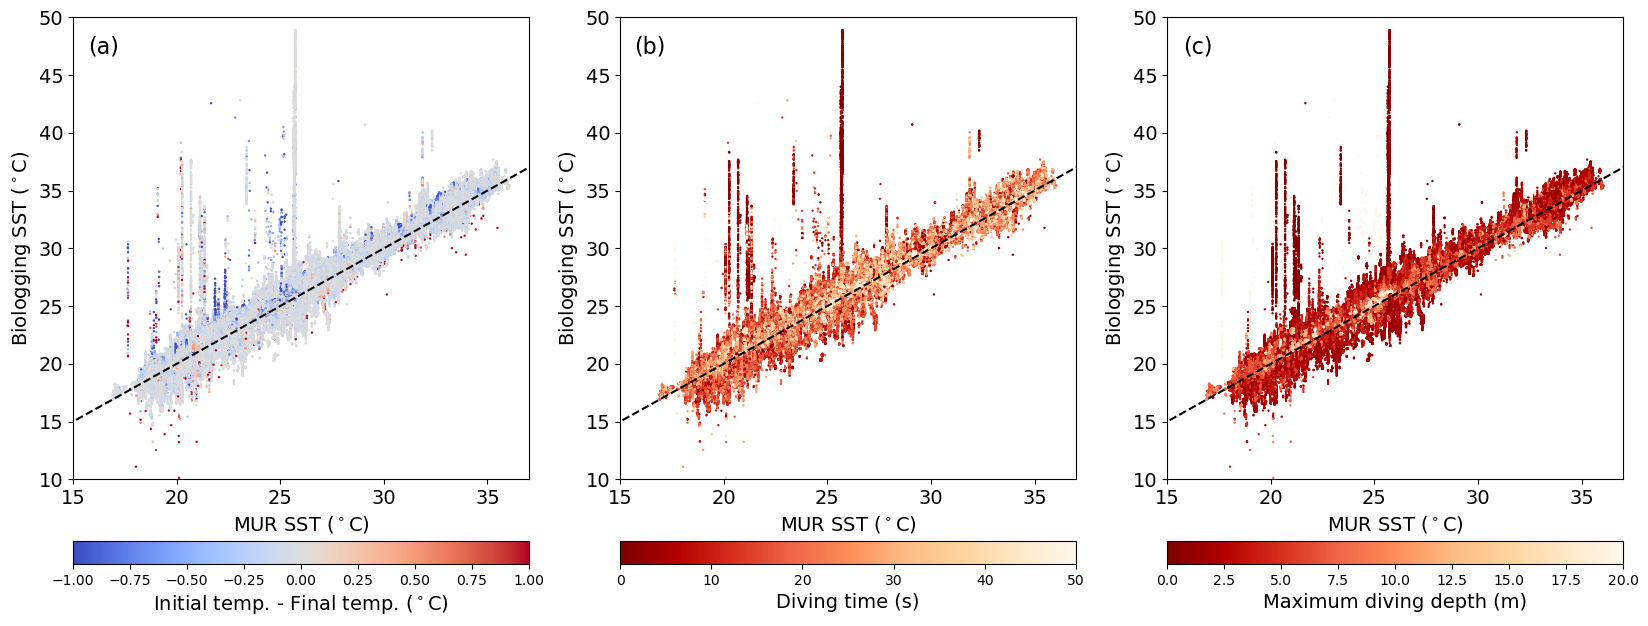

In [ ]:
fig, ax = plt.subplots(1,3,figsize=(20,8))


mc0 = ax[0].scatter(fmm_combined,ds_dive_filtered_combined.temp1,c=ds_dive_filtered_combined.temp0-ds_dive_filtered_combined.temp1,cmap='coolwarm',s=0.5,vmax=1,vmin=-1)
ax[0].plot([10,50],[10,50],'--k')
ax[0].set_xlim(15,37),ax[0].set_ylim(10,50)
ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[0].set_xlabel('MUR SST ($^\circ$C)',fontsize=14)
ax[0].set_ylabel('Biologging SST ($^\circ$C)',fontsize=14)
cbar = fig.colorbar(mc0, ax=ax[0], orientation='horizontal', pad=0.1)
cbar.ax.set_xlabel('Initial temp. - Final temp. ($^\circ$C)', fontsize=14)
ax[0].text(0.1, 0.96, '(a)', transform=ax[0].transAxes, fontsize=16, va='top', ha='right')

mc0 = ax[1].scatter(fmm_combined,ds_dive_filtered_combined.temp1,c=ds_dive_filtered_combined.rec_len,cmap='OrRd_r',s=0.5,vmax=50,vmin=0)
ax[1].plot([10,50],[10,50],'--k')
ax[1].set_xlim(15,37),ax[1].set_ylim(10,50)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[1].set_xlabel('MUR SST ($^\circ$C)',fontsize=14)
ax[1].set_ylabel('Biologging SST ($^\circ$C)',fontsize=14)
cbar = fig.colorbar(mc0, ax=ax[1], orientation='horizontal', pad=0.1)
cbar.ax.set_xlabel('Diving time (s)', fontsize=14)
ax[1].text(0.1, 0.96, '(b)', transform=ax[1].transAxes, fontsize=16, va='top', ha='right')

mc0 = ax[2].scatter(fmm_combined,ds_dive_filtered_combined.temp1,c=ds_dive_filtered_combined.depth_max,cmap='OrRd_r',s=0.5,vmax=20,vmin=0)
ax[2].plot([10,50],[10,50],'--k')
ax[2].set_xlim(15,37),ax[2].set_ylim(10,50)
ax[2].tick_params(axis='both', which='major', labelsize=14)
cbar = fig.colorbar(mc0, ax=ax[2], orientation='horizontal', pad=0.1)
cbar.ax.set_xlabel('Maximum diving depth (m)', fontsize=14)
ax[2].set_xlabel('MUR SST ($^\circ$C)',fontsize=14)
ax[2].set_ylabel('Biologging SST ($^\circ$C)',fontsize=14)
# fig.colorbar(mc0, ax=ax[2], label='Maximum diving depth (m)')
ax[2].text(0.1, 0.96, '(c)', transform=ax[2].transAxes, fontsize=16, va='top', ha='right')


Text(0.1, 0.96, '(f)')

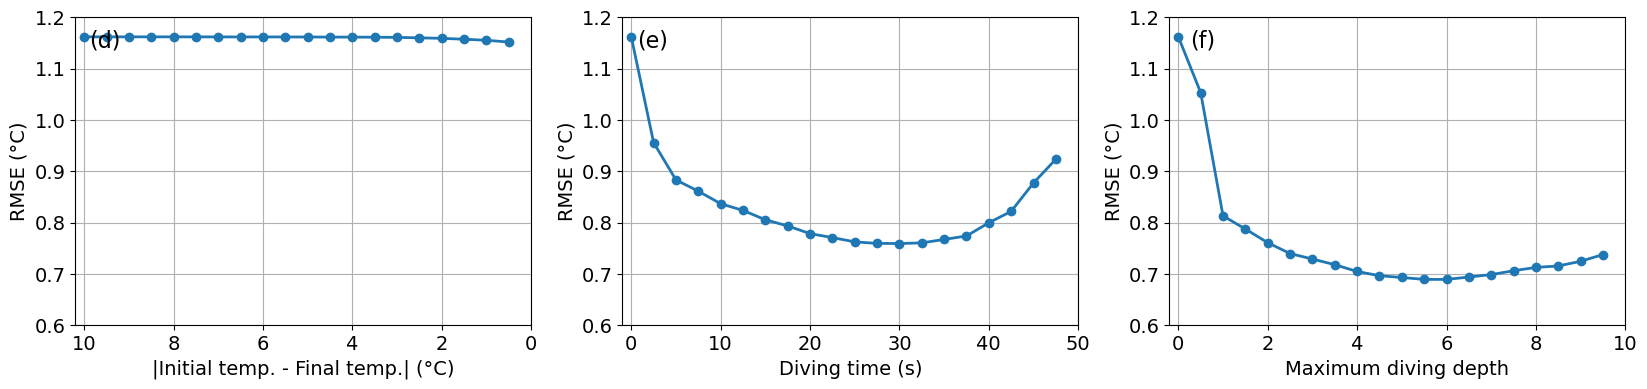

In [82]:
fig, ax = plt.subplots(1,3,figsize=(20,4))

ax[0].plot(np.arange(10,0,-0.5),rmse_with_t0,marker='o',linewidth=2)
ax[0].set_xlabel('|Initial temp. - Final temp.| (°C)',fontsize=14)
ax[0].set_ylabel('RMSE (°C)',fontsize=14)
ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[0].set_xlim(0,10.2)
ax[0].invert_xaxis()
ax[0].set_ylim(0.6,1.2)
ax[0].grid()

ax[1].plot(np.arange(0,50,2.5),rmse_with_reclen,marker='o',linewidth=2)
ax[1].set_xlabel('Diving time (s)',fontsize=14)
ax[1].set_ylabel('RMSE (°C)',fontsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[1].set_xlim(-1,50)
ax[1].set_ylim(0.6,1.2)
ax[1].grid()

ax[2].plot(np.arange(0,10,0.5),rmse_with_maxdep,marker='o',linewidth=2)
ax[2].set_xlabel('Maximum diving depth',fontsize=14)
ax[2].set_ylabel('RMSE (°C)',fontsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[2].set_xlim(-0.2,10)
ax[2].set_ylim(0.6,1.2)
ax[2].grid()

# ax[0].set_title('(a) RMSE with temp. difference',fontsize=16)
# ax[1].set_title('(b) RMSE with diving time',fontsize=16)
# ax[2].set_title('(c) RMSE with maximum diving depth',fontsize=16)

ax[0].text(0.1, 0.96, '(d)', transform=ax[0].transAxes, fontsize=16, va='top', ha='right')
ax[1].text(0.1, 0.96, '(e)', transform=ax[1].transAxes, fontsize=16, va='top', ha='right')
ax[2].text(0.1, 0.96, '(f)', transform=ax[2].transAxes, fontsize=16, va='top', ha='right')

## Filter by combining the three factors

In [84]:
depth_cut =5
time_cut = 25
temp_cut = 2

threshold = (~np.isnan(ds_dive_filtered_combined.temp1)) &(ds_dive_filtered_combined.depth_max>depth_cut) & (ds_dive_filtered_combined.rec_len>time_cut) & (np.abs(ds_dive_filtered_combined.temp0-ds_dive_filtered_combined.temp1)<temp_cut)
fmm_combined_dn_f3 = fmm_combined.where(threshold,drop=True)
ds_dive_filtered_combined_dn_f3 = ds_dive_filtered_combined.where(threshold,drop=True)

fmm_combined_dn2_f3 = fmm_combined_dn_f3.where(~np.isnan(fmm_combined_dn_f3),drop=True)
ds_dive_filtered_combined_dn2_f3 = ds_dive_filtered_combined_dn_f3.where(~np.isnan(fmm_combined_dn_f3),drop=True)

Text(0, 0.5, 'Bio-logging SST ($^\\circ$C)')

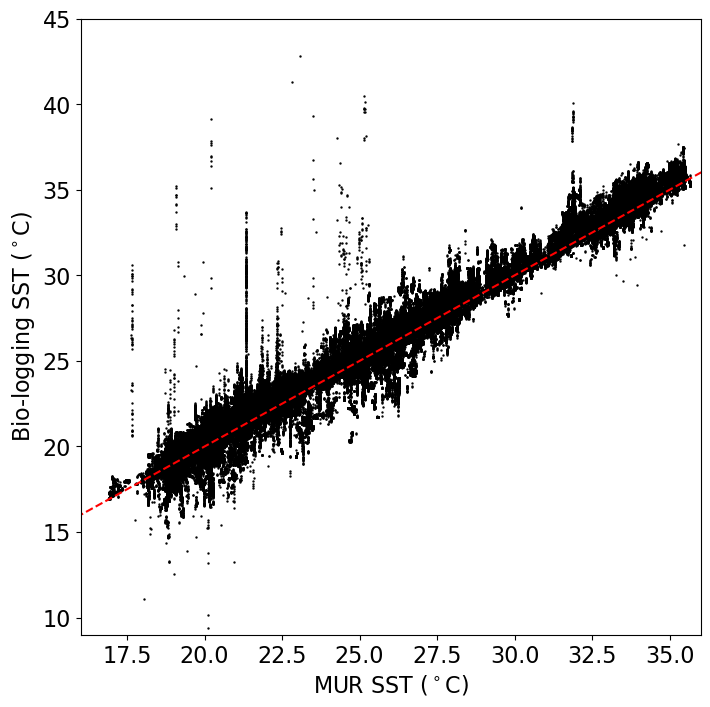

In [85]:
# unfiltered scatter
plt.figure(figsize=(8,8))
plt.scatter(fmm2,ds_dive_2_filtered.temp1,c='k',s=0.5)
plt.plot([10,50],[10,50],'--r')
plt.xlim([16, 36]),plt.ylim([9, 45])
plt.tick_params(axis='both', which='major', labelsize=16)
plt.xlabel('MUR SST ($^\circ$C)',fontsize=16)
plt.ylabel('Bio-logging SST ($^\circ$C)',fontsize=16)
# plt.grid()

/tmp/ipykernel_174340/1953740202.py:14: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  plt.scatter(fmm_combined_dn_f3,ds_dive_filtered_combined_dn_f3.where(ds_dive_filtered_combined_dn_f3.time<=pd.Timestamp('2024-1-1')).temp1,c='g',cmap='coolwarm',s=0.5,vmax=1,vmin=-1)


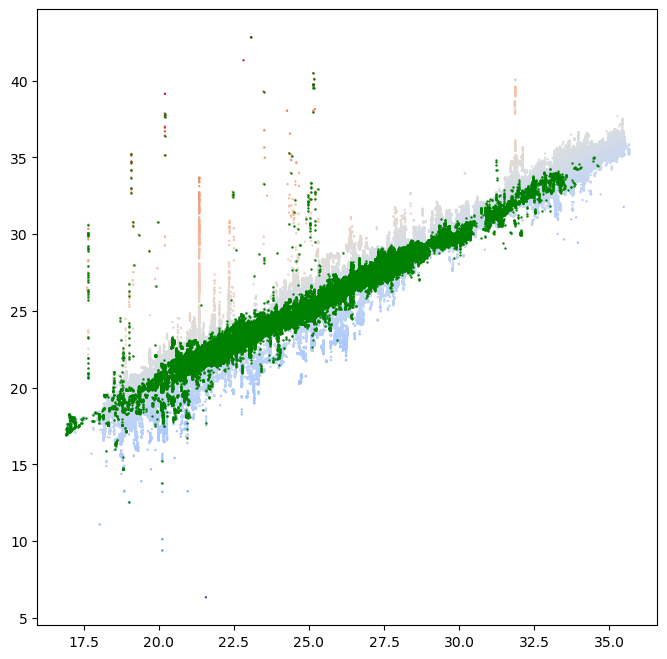

In [86]:
# fig, ax = plt.subplots(figsize=(8,8))
plt.figure(figsize=(8,8))
# ax.scatter(fmm1,ds_dive_1_filtered.temp1,c='r',cmap='coolwarm',s=0.5,vmax=1,vmin=-1)
plt.scatter(fmm2,ds_dive_2_filtered.temp1,c=ds_dive_2_filtered.temp1-fmm2,cmap='coolwarm',s=0.5)
# plt.scatter(fmm2,ds_dive_2_filtered.where(ds_dive_2_filtered.tag_id==215445).temp1,c='k',cmap='coolwarm',s=0.5)
# plt.scatter(fmm2,ds_dive_2_filtered.where(ds_dive_2_filtered.tag_id==215458).temp1,c='k',cmap='coolwarm',s=0.5)
# plt.scatter(fmm2,ds_dive_2_filtered.where(ds_dive_2_filtered.tag_id==215459).temp1,c='k',cmap='coolwarm',s=0.5)
# plt.scatter(fmm2,ds_dive_2_filtered.where(ds_dive_2_filtered.tag_id==215446).temp1,c='k',cmap='coolwarm',s=0.5)
# plt.scatter(fmm2,ds_dive_1_filtered.where(ds_dive_1_filtered.tag_id==210420).temp1,c='k',cmap='coolwarm',s=0.5)
# plt.colorbar()
# ax.scatter(fmm3,ds_dive_3_filtered.temp1,c='g',cmap='coolwarm',s=0.5,vmax=1,vmin=-1)
# ax.scatter(fmm4,ds_dive_4_filtered.temp1,c='y',cmap='coolwarm',s=0.5,vmax=1,vmin=-1)

plt.scatter(fmm_combined_dn_f3,ds_dive_filtered_combined_dn_f3.where(ds_dive_filtered_combined_dn_f3.time<=pd.Timestamp('2024-1-1')).temp1,c='g',cmap='coolwarm',s=0.5,vmax=1,vmin=-1)
# [215437., 225655., 225656., 237244., 237245., 237247., 237248.,
    #    237249., 237254., 237255., 237257., 237259., 237261.]

# ax[0].plot([10,50],[10,50],'--k')
# ax[0].set_xlim(15,37),ax[0].set_ylim(10,50)
# ax[0].tick_params(axis='both', which='major', labelsize=14)
# ax[0].set_xlabel('MUR SST ($^\circ$C)',fontsize=14)
# ax[0].set_ylabel('Biologging SST ($^\circ$C)',fontsize=14)
# cbar = fig.colorbar(mc0, ax=ax, orientation='horizontal', pad=0.1)
# cbar.ax.set_xlabel('Initial temp. - Final temp. ($^\circ$C)', fontsize=14)
# ax[0].text(0.1, 0.96, '(a)', transform=ax[0].transAxes, fontsize=16, va='top', ha='right')

## get dust concentration 

In [87]:
# Interpolate dust dataset to the coordinates and time of filtered dive datasets
dust_interp_1 = ds_dust.interp(lon=ds_dive_1_filtered.lon, lat=ds_dive_1_filtered.lat, time=ds_dive_1_filtered.time)
dust_interp_2 = ds_dust.interp(lon=ds_dive_2_filtered.lon, lat=ds_dive_2_filtered.lat, time=ds_dive_2_filtered.time)
dust_interp_3 = ds_dust.interp(lon=ds_dive_3_filtered.lon, lat=ds_dive_3_filtered.lat, time=ds_dive_3_filtered.time)
dust_interp_4 = ds_dust.interp(lon=ds_dive_4_filtered.lon, lat=ds_dive_4_filtered.lat, time=ds_dive_4_filtered.time)


In [88]:
# Combine dust interpolation datasets into a single dataset
dust_interp_combined = xr.concat([dust_interp_1, dust_interp_2, dust_interp_3, dust_interp_4], dim='dive_index')

In [89]:
dust_interp_combined_dn = dust_interp_combined.where(threshold, drop=True)
# Get indices where fmm_combined_dn_f3 is not NaN
# mask = xr.DataArray(~np.isnan(fmm_combined_dn_f3), dims=["dive_index"], coords={"dive_index": dust_interp_combined_dn.dive_index})
# Use .where instead of .loc for xarray datasets
dust_interp_combined_dn2 = dust_interp_combined_dn.where(~np.isnan(fmm_combined_dn_f3), drop=True)

In [90]:
ds_dive_filtered_combined_dn2_f3

<xarray.Dataset>
Dimensions:       (dive_index: 287267)
Coordinates:
    lon           (dive_index) float64 53.15 53.15 53.15 ... 52.73 52.73 52.75
    lat           (dive_index) float64 24.68 24.68 24.68 ... 24.55 24.55 24.37
    time          (dive_index) datetime64[ns] 2020-11-14T06:28:34 ... 2021-01...
  * dive_index    (dive_index) float64 0.0 1.0 2.0 ... 3.877e+03 3.878e+03
Data variables:
    tag_id        (dive_index) float64 2.014e+05 2.014e+05 ... 2.03e+05 2.03e+05
    temp1         (dive_index) float64 29.1 29.07 29.08 ... 21.79 21.79 21.79
    temp0         (dive_index) float64 29.02 29.15 29.06 ... 21.79 21.79 21.79
    temp_int1     (dive_index) float64 31.0 31.0 31.0 31.0 ... 25.0 24.0 23.0
    temp_int0     (dive_index) float64 30.0 31.0 31.0 31.0 ... 26.0 25.0 29.0
    rec_len       (dive_index) float64 39.0 52.0 36.0 39.0 ... 30.0 26.0 28.0
    first_record  (dive_index) float64 5.509e+04 5.514e+04 ... 1.291e+05
    last_record   (dive_index) float64 5.513e+04 5.519e+04 ... 1.291e+05
    depth_max     (dive_index) float64 13.68 13.69 13.73 ... 15.55 15.88 9.49

In [91]:
np.unique(ds_dive_filtered_combined_dn2_f3.where((dust_interp_combined_dn2.dust_dens>0.00275)&(ds_dive_filtered_combined_dn2_f3.time<pd.Timestamp('2024-4-30')),drop=True).tag_id)

array([237245., 237249.])

In [92]:
bins = np.arange(0, 0.002, 0.0001)  # Change the range as per your requirement, e.g. [0, 0.1, 0.2, 0.3]

# Bin the values of 'du' using numpy's digitize
bin_indices = np.digitize(dust_interp_combined_dn2.dust_dens, bins) - 1 
dust_interp_combined_dn2['du_bins'] = (dust_interp_combined_dn2['dust_dens'].dims, bin_indices)

# dtemp = fmm_sub2-ds_obs_rnan.temp_filter
dtemp = fmm_combined_dn2_f3-ds_dive_filtered_combined_dn2_f3.where((ds_dive_filtered_combined_dn2_f3.tag_id!=215458)&(ds_dive_filtered_combined_dn2_f3.time<pd.Timestamp('2024-3-1'))).temp1
# dtemp = fmm_combined_dn2_f3-ds_dive_filtered_combined_dn2_f3.where((ds_dive_filtered_combined_dn2_f3.tag_id!=215458)&(ds_dive_filtered_combined_dn2_f3.time<pd.Timestamp('2024-1-1'))).temp1

dtemp['du_bins'] = (dust_interp_combined_dn2['dust_dens'].dims, bin_indices)


# Group dtemp by du_bins and calculate the root mean square for each bin
rms_dtemp_by_bin = dtemp.groupby("du_bins").map(lambda x: np.sqrt(np.mean(x**2)))
# rms_dtemp_by_bin = dtemp.groupby("du_bins").std()
# Count the number of occurrences in each du_bins
count_by_bin = dtemp.groupby("du_bins").count()

# Print the count result
print(count_by_bin)

# Print the result
print(rms_dtemp_by_bin)

# dust_interp.groupby_bins('dust_dens',x_bins)

<xarray.DataArray (du_bins: 20)>
array([11772, 64096, 43265, 24038, 14068,  9560,  4338,  2361,  1493,
         842,   589,   257,   324,   282,    60,   116,   170,    13,
           0,     0])
Coordinates:
  * du_bins  (du_bins) int64 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19
<xarray.DataArray (du_bins: 20)>
array([0.56099288, 0.63394378, 0.68257682, 0.6857667 , 0.64391932,
       0.54456997, 0.62422801, 0.58148958, 0.64756034, 0.60546463,
       0.72833992, 0.53216713, 0.44359212, 0.57395184, 0.48144072,
       0.43724299, 0.28220841, 0.21999239,        nan,        nan])
Coordinates:
  * du_bins  (du_bins) int64 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19


In [93]:
np.sqrt(np.mean(dtemp**2))

<xarray.DataArray ()>
array(0.64371345)

Text(0, 0.5, 'STD of temperature ($\\circ$C)')

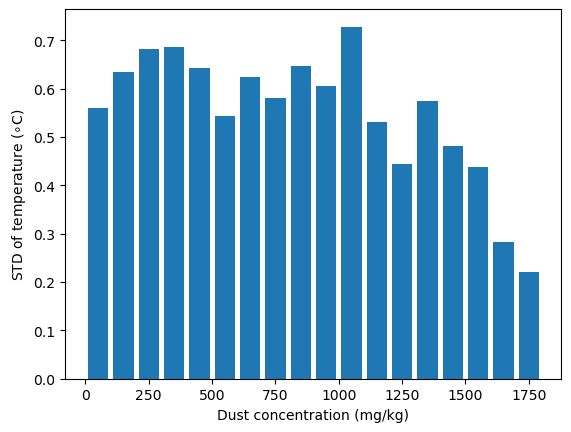

In [94]:
# plt.bar(1e6*(bins+0.5*(bins[1]-bins[0])),dtemp['rmse'].groupby('du_bins').std(), width=0.8e2)
plt.bar(1e6*(bins+0.5*(bins[1]-bins[0])),rms_dtemp_by_bin, width=0.8e2)

plt.xlabel('Dust concentration (mg/kg)')
plt.ylabel('STD of temperature ($\circ$C)')

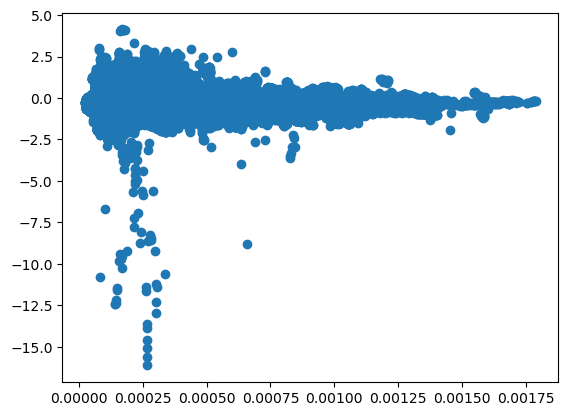

In [95]:
plt.plot(dust_interp_combined_dn2.dust_dens,dtemp,'o')

/tmp/ipykernel_174340/839969814.py:19: RuntimeWarning: divide by zero encountered in log10
  m.pcolormesh(xmap, ymap, np.log10(hist.T), cmap='jet', shading='auto', vmin=0, vmax=4)
/tmp/ipykernel_174340/839969814.py:20: RuntimeWarning: divide by zero encountered in log10
  cbar = m.colorbar(mappable=m.pcolormesh(xmap, ymap, np.log10(hist.T), cmap='jet', shading='auto', vmin=0, vmax=4), location='right', pad="5%")
/tmp/ipykernel_174340/839969814.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('YlOrRd', 18)


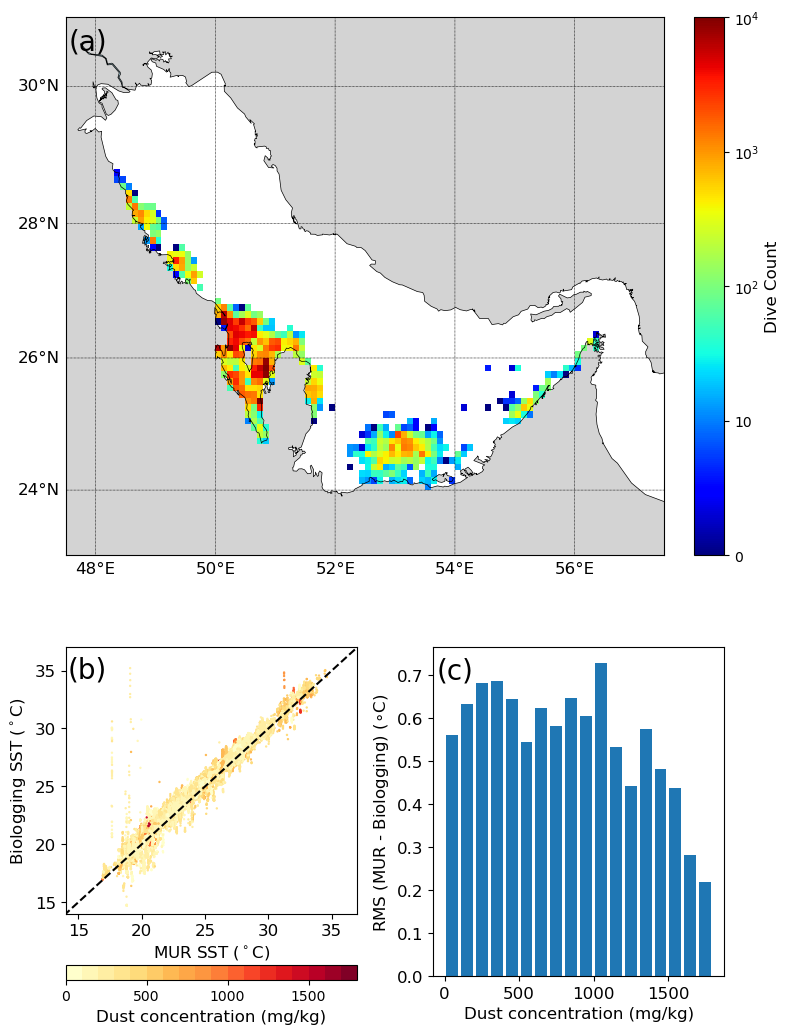

In [98]:

fig = plt.figure(figsize=(8, 11))
gs = gridspec.GridSpec(2, 2, height_ratios=[2, 1])

# First subplot (upper half)
ax1 = fig.add_subplot(gs[0, :])
m = Basemap(projection='merc', llcrnrlat=23, urcrnrlat=31,
            llcrnrlon=47.5, urcrnrlon=57.5, lat_ts=20, resolution='i', ax=ax1)
x, y = m(ds_dive_filtered_combined_dn2_f3.lon, ds_dive_filtered_combined_dn2_f3.lat)
hist, xedges, yedges = np.histogram2d(ds_dive_filtered_combined_dn2_f3.lon, ds_dive_filtered_combined_dn2_f3.lat, bins=[np.arange(47, 58, 0.1), np.arange(23, 32, 0.1)])
xcenters = (xedges[:-1] + xedges[1:]) / 2
ycenters = (yedges[:-1] + yedges[1:]) / 2
xgrid, ygrid = np.meshgrid(xcenters, ycenters)
xmap, ymap = m(xgrid, ygrid)

m.drawcoastlines(linewidth=0.5)
m.fillcontinents(color='lightgrey', lake_color='lightblue')
m.drawmeridians(np.arange(0, 360, 2), linewidth=0.5, labels=[False, True, False, True], fontsize=12)
m.drawparallels(np.arange(-90, 90, 2), linewidth=0.5, labels=[True, False, False, True], fontsize=12)
m.pcolormesh(xmap, ymap, np.log10(hist.T), cmap='jet', shading='auto', vmin=0, vmax=4)
cbar = m.colorbar(mappable=m.pcolormesh(xmap, ymap, np.log10(hist.T), cmap='jet', shading='auto', vmin=0, vmax=4), location='right', pad="5%")
cbar.set_ticks([0, 1, 2, 3, 4])
cbar.set_label(label='Dive Count', size=12)
cbar.set_ticklabels(['0', '10', '10$^2$', '10$^3$', '10$^4$'])
ax1.text(0.07, 0.98, '(a)', transform=ax1.transAxes, fontsize=20, va='top', ha='right')

# Second subplot (lower left)
ax2 = fig.add_subplot(gs[1, 0])
cmap = plt.cm.get_cmap('YlOrRd', 18)
mc0 = ax2.scatter(fmm_combined_dn2_f3, ds_dive_filtered_combined_dn2_f3.where((ds_dive_filtered_combined_dn2_f3.tag_id != 215458) & (ds_dive_filtered_combined_dn2_f3.time < pd.Timestamp('2024-3-1'))).temp1,
                  c=dust_interp_combined_dn2.dust_dens * 1e6, cmap=cmap, s=0.5, vmax=1800, vmin=0)
ax2.plot([10, 50], [10, 50], '--k')
ax2.set_xlim(14, 37)
ax2.set_ylim(14, 37)
ax2.tick_params(axis='both', which='major', labelsize=12)
cbar = fig.colorbar(mc0, ax=ax2, orientation='horizontal', pad=0.04, anchor=(0.5,-0.1))
cbar.ax.set_xlabel('Dust concentration (mg/kg)', fontsize=12)
ax2.set_xlabel('MUR SST ($^\circ$C)', fontsize=12)
ax2.set_ylabel('Biologging SST ($^\circ$C)', fontsize=12)
ax2.text(0.14, 0.97, '(b)', transform=ax2.transAxes, fontsize=20, va='top', ha='right')

# Third subplot (lower right)
ax3 = fig.add_subplot(gs[1, 1])
ax3.bar(1e6 * (bins + 0.5 * (bins[1] - bins[0])), rms_dtemp_by_bin, width=0.8e2)
ax3.tick_params(axis='both', which='major', labelsize=12)
ax3.set_xlabel('Dust concentration (mg/kg)', fontsize=12)
ax3.set_ylabel('RMS (MUR - Biologging) ($\circ$C)', fontsize=12)
ax3.text(0.14, 0.97, '(c)', transform=ax3.transAxes, fontsize=20, va='top', ha='right')

plt.tight_layout()
plt.show()

In [651]:
# Distance away from the FBEWMA that data should be removed.
DELTA = 1.5

# clip data above this value:
HIGH_CLIP = 41

# clip data below this value:
LOW_CLIP = 14

# random values above this trigger a spike:
RAND_HIGH = 0.98

# random values below this trigger a negative spike:
RAND_LOW = 0.02

# How many samples to run the FBEWMA over.
SPAN = 10

# spike amplitude
SPIKE = 1

def clip_data(unclipped, high_clip, low_clip):
    ''' Clip unclipped between high_clip and low_clip. 
    unclipped contains a single column of unclipped data.'''
    
    # convert to np.array to access the np.where method
    np_unclipped = np.array(unclipped)
    # clip data above HIGH_CLIP or below LOW_CLIP
    cond_high_clip = (np_unclipped > HIGH_CLIP) | (np_unclipped < LOW_CLIP)
    np_clipped = np.where(cond_high_clip, np.nan, np_unclipped)
    return np_clipped.tolist()


def create_sample_data(x,y):
    ''' Create sine wave, amplitude +/-2 with random spikes. '''
    # x = np.linspace(0, 2*np.pi, 1000)
    # y = 2 * np.sin(x)
    # x = t_filtered.groupby('t.dayofyear').mean(dim='t').dayofyear.values[0:-2]
    # y = t_filtered.groupby('t.dayofyear').mean(dim='t').values[0:-2]
    df = pd.DataFrame(list(zip(x,y)), columns=['x', 'y'])
    df['rand'] = np.random.random_sample(len(x),)
    # create random positive and negative spikes
    cond_spike_high = (df['rand'] > RAND_HIGH)
    df['spike_high'] = np.where(cond_spike_high, SPIKE, 0)
    cond_spike_low = (df['rand'] < RAND_LOW)
    df['spike_low'] = np.where(cond_spike_low, -SPIKE, 0)
    # df['y_spikey'] = df['y'] + df['spike_high'] + df['spike_low']
    df['y_spikey'] = df['y'] 
    return df


def ewma_fb(df_column, span):
    ''' Apply forwards, backwards exponential weighted moving average (EWMA) to df_column. '''
    # Forwards EWMA.
    fwd = pd.Series.ewm(df_column, span=span).mean()
    # Backwards EWMA.
    bwd = pd.Series.ewm(df_column[::-1],span=10).mean()
    # Add and take the mean of the forwards and backwards EWMA.
    stacked_ewma = np.vstack(( fwd, bwd[::-1] ))
    fb_ewma = np.mean(stacked_ewma, axis=0)
    return fb_ewma
    
    
def remove_outliers(spikey, fbewma, delta):
    ''' Remove data from df_spikey that is > delta from fbewma. '''
    np_spikey = np.array(spikey)
    np_fbewma = np.array(fbewma)
    cond_delta = (np.abs(np_spikey-np_fbewma) > delta)
    np_remove_outliers = np.where(cond_delta, np.nan, np_spikey)
    return np_remove_outliers

    
def spike_removing2(x0,y0):
    df = create_sample_data(x0,y0)

    df['y_clipped'] = clip_data(df['y_spikey'].tolist(), HIGH_CLIP, LOW_CLIP)
    df['y_ewma_fb'] = ewma_fb(df['y_clipped'], SPAN)
    df['y_remove_outliers'] = remove_outliers(df['y_clipped'].tolist(), df['y_ewma_fb'].tolist(), DELTA)
    df['y_interpolated'] = df['y_remove_outliers'].interpolate()
    
    # ax = df.plot(x='x', y='y_spikey', color='blue', alpha=0.5)
    # ax2 = df.plot(x='x', y='y_interpolated', color='black', ax=ax)
    # ax2 = df.plot(x='x', y='y_ewma_fb', color='black', ax=ax)
    return df
# main()

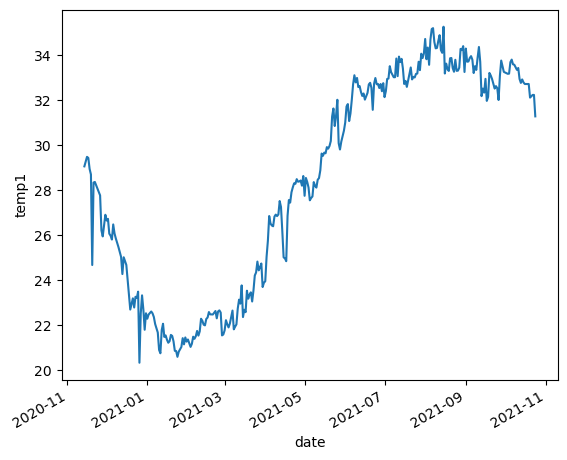

In [706]:
dive_tag1 = ds_dive_filtered_combined.where(ds_dive_filtered_combined.tag_id==203018,drop=True)

# # Sort by time first to ensure chronological order
# dive_tag1 = dive_tag1.sortby('time')

# # Create a pandas DatetimeIndex from the time values
# time_index = pd.DatetimeIndex(dive_tag1.time.values)

# # Assign the time values as coordinates
dive_tag1 = dive_tag1.assign_coords(time=('dive_index', dive_tag1.time.values))
dive_tag1

# # # Create a new dataset with time as the main coordinate instead of replacing dive_index
# # This preserves the data structure while giving us time-based access
dive_tag1_by_time = dive_tag1.swap_dims({'dive_index': 'time'})
dive_tag1_dailymean = dive_tag1_by_time.groupby('time.date').mean(dim='time')
dive_tag1_dailymean['date'] = pd.to_datetime(dive_tag1_dailymean.date)
dive_tag1_dailymean.temp1.plot()

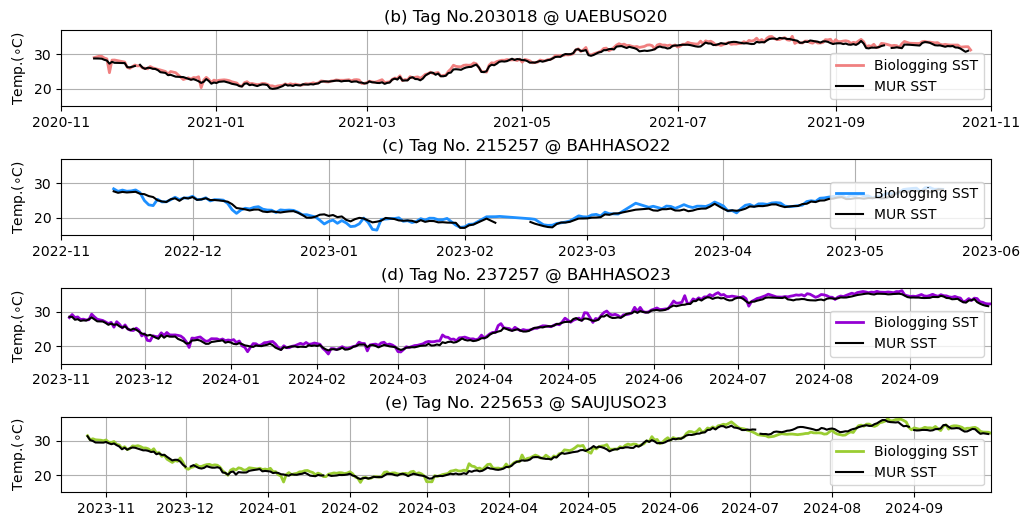

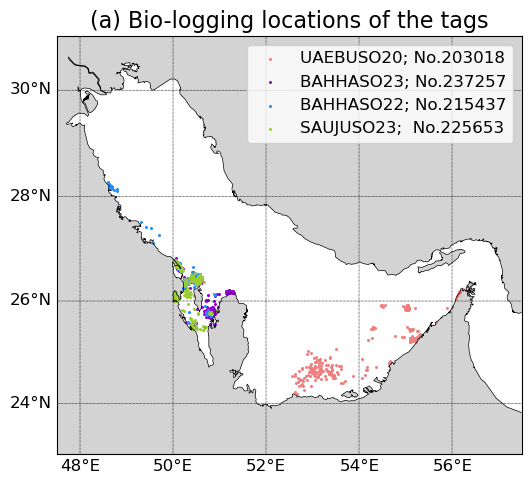

In [151]:
imax = 4

def get_daily_single_tag(tag_id0):
    dive_tag1 = ds_dive_filtered_combined.where(ds_dive_filtered_combined.tag_id==tag_id0,drop=True)
    dive_tag1 = dive_tag1.assign_coords(time=('dive_index', dive_tag1.time.values))
    dive_tag1 = dive_tag1.swap_dims({'dive_index': 'time'})
    dive_tag1_dailymean = dive_tag1.groupby('time.date').mean(dim='time')
    dive_tag1_dailymean['date'] = pd.to_datetime(dive_tag1_dailymean.date)

    fmm_tag1 = fmm_combined.where(ds_dive_filtered_combined.tag_id==tag_id0,drop=True).swap_dims({'dive_index': 'time'})
    fmm_tag1_dailymean = fmm_tag1.groupby('time.date').mean(dim='time')
    fmm_tag1_dailymean['date'] = pd.to_datetime(fmm_tag1_dailymean.date)

    y_data_array = dive_tag1_dailymean.temp1.values
    x_data_array = dive_tag1_dailymean.date.values
    lon_data_array = dive_tag1.lon.groupby('time.date').first().values
    lat_data_array = dive_tag1.lat.groupby('time.date').first().values

    return x_data_array, y_data_array, fmm_tag1_dailymean, lon_data_array, lat_data_array

xtag1,ytag1,ffmtag1,lon_tag1,lat_tag1 = get_daily_single_tag(203018)
xtag2,ytag2,ffmtag2,lon_tag2,lat_tag2 = get_daily_single_tag(237257)
xtag3,ytag3,ffmtag3,lon_tag3,lat_tag3 = get_daily_single_tag(215437)
xtag4,ytag4,ffmtag4,lon_tag4,lat_tag4 = get_daily_single_tag(225653)

fig = plt.figure(figsize=(12,6))

gs = gridspec.GridSpec(4, 1)

ax2 = fig.add_subplot(gs[0,0])
ax2.plot(xtag1,ytag1,label='Biologging SST',color='lightcoral',linewidth=2)
ax2.plot(xtag1,ffmtag1,label='MUR SST',color='k')

ax2.set_xlim(np.datetime64('2020-11-01'),np.datetime64('2021-11-01'))
ax2.grid()
# if i!=imax-1:
#     axs.set_xticklabels([])
ax2.legend(loc='lower right')
ax2.set_title('(b) Tag No.203018 @ UAEBUSO20')
ax2.set_ylabel('Temp.($\circ$C)')

ax3 = fig.add_subplot(gs[2,0])
ax3.plot(xtag2,ytag2,label='Biologging SST',color='darkviolet',linewidth=2)
ax3.plot(xtag2,ffmtag2,label='MUR SST',color='k')

ax3.set_xlim(np.datetime64('2023-11-01'),np.datetime64('2024-09-30'))
ax3.grid()
ax3.legend(loc='lower right')
ax3.set_title('(d) Tag No. 237257 @ BAHHASO23')
ax3.set_ylabel('Temp.($\circ$C)')

ax4 = fig.add_subplot(gs[1,0])
ax4.plot(xtag3,ytag3,label='Biologging SST',color='dodgerblue',linewidth=2)
ax4.plot(xtag3,ffmtag3,label='MUR SST',color='k')

ax4.set_xlim(np.datetime64('2022-11-01'),np.datetime64('2023-06-01'))
ax4.grid()
ax4.legend(loc='lower right')
ax4.set_title('(c) Tag No. 215257 @ BAHHASO22')
ax4.set_ylabel('Temp.($\circ$C)')

ax5 = fig.add_subplot(gs[3,0])
ax5.plot(xtag4,ytag4,label='Biologging SST',color='yellowgreen',linewidth=2)
ax5.plot(xtag4,ffmtag4,label='MUR SST',color='k')

ax5.set_xlim(np.datetime64('2023-10-15'),np.datetime64('2024-09-30'))
ax5.grid()
ax5.legend(loc='lower right')
ax5.set_title('(e) Tag No. 225653 @ SAUJUSO23', )
ax5.set_ylabel('Temp.($\circ$C)')


ax2.set_ylim(15,37)
ax3.set_ylim(15,37)
ax4.set_ylim(15,37)
ax5.set_ylim(15,37)

plt.subplots_adjust(hspace=0.7)

# Add a main title for the entire figure
# fig.suptitle('Sea Surface Temperature Comparison between Biologging and MUR', fontsize=16, y=0.98)

# Save the figure with high resolution
# plt.savefig('sst_comparison.png', dpi=300, bbox_inches='tight')


# First subplot (upper half)
fig,ax1 = plt.subplots(figsize=(6,6))

# ax1 = fig.add_subplot(gs[0:2,0])

sssymbol = 1.4

m = Basemap(projection='merc',llcrnrlat=23,urcrnrlat=31,\
            llcrnrlon=47.5,urcrnrlon=57.5,lat_ts=20,resolution='i',ax=ax1)

m.drawcoastlines(linewidth=0.5)
m.fillcontinents(color='lightgrey', lake_color='lightblue')
m.drawmeridians(np.arange(0, 360, 2), linewidth=0.5, labels=[False,True,False,True],fontsize=12)
m.drawparallels(np.arange(-90, 90, 2), linewidth=0.5, labels=[True,False,False,True],fontsize=12)
# cs = m.contourf(x, y, data, levels=15)
# lons, lats = np.meshgrid(londus.data,latdus.data)
# x,y = m(lons, lats)

# xa0 = ds_obs1_rnan.where(ds_obs1_rnan.id==203018).x.groupby('t.date').mean(dim='t')
# ya0 = ds_obs1_rnan.where(ds_obs1_rnan.id==203018).y.groupby('t.date').mean(dim='t')
x,y = m(lon_tag1, lat_tag1)
cs0 = m.scatter(x,y,color='lightcoral',s=sssymbol,label='UAEBUSO20; No.203018')

# xa1 = ds_obs2_rnan.where(ds_obs2_rnan.id==237257).x.groupby('t.date').mean(dim='t')
# ya1 = ds_obs2_rnan.where(ds_obs2_rnan.id==237257).y.groupby('t.date').mean(dim='t')
x,y = m(lon_tag2, lat_tag2)
cs1 = m.scatter(x,y,color='darkviolet',s=sssymbol,label='BAHHASO23; No.237257')

x,y = m(lon_tag3, lat_tag3)
cs2 = m.scatter(x,y,color='dodgerblue',s=sssymbol,label='BAHHASO22; No.215437')

x,y = m(lon_tag4, lat_tag4)
cs3 = m.scatter(x,y,color='yellowgreen',s=sssymbol,label='SAUJUSO23;  No.225653')
# if idplt==0:
ax1.set_title('(a) Bio-logging locations of the tags',fontsize=16)
    
ax1.legend(loc='upper right',fontsize=12)

# all tags